Cell 1  — Install Packages

In [ ]:
# Cell 1 — Install required packages
!pip install chromadb sentence-transformers pdfplumber python-docx \
            langchain-text-splitters google-generativeai openai -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.

In [ ]:
# Cell 2 — Upload files in multiple rounds to Colab
# You can upload files from different folders/subfolders in several rounds.

from google.colab import files
from pathlib import Path
import os

# ── Create local folders inside Colab session ────────────────────────────────
DATA_ROOT = Path("/content/data")

STRUCT_DIR        = DATA_ROOT / "02_Structured_Data"
NATIONAL_DOCS_DIR = DATA_ROOT / "04_National_Documents"
STATE_DOCS_DIR    = DATA_ROOT / "05_State_Specific_Documents"
CHROMA_DIR        = DATA_ROOT / "chromadb"

for folder in [STRUCT_DIR, NATIONAL_DOCS_DIR, STATE_DOCS_DIR, CHROMA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# ── Helper: safely save uploaded files ───────────────────────────────────────
def save_uploaded_files(uploaded_dict, target_dir):
    """
    Saves uploaded files into target_dir.
    If a file with the same name already exists, it creates a new version
    instead of overwriting it.
    """
    saved_paths = []

    for fname, data in uploaded_dict.items():
        original_path = target_dir / fname
        save_path = original_path

        # Avoid overwriting duplicate filenames
        counter = 2
        while save_path.exists():
            stem = original_path.stem
            suffix = original_path.suffix
            save_path = target_dir / f"{stem}_{counter}{suffix}"
            counter += 1

        with open(save_path, "wb") as f:
            f.write(data)

        saved_paths.append(save_path)
        print(f"  Saved: {save_path.name}")

    return saved_paths


# ── Helper: upload in unlimited batches ──────────────────────────────────────
def upload_in_batches(target_dir, label):
    """
    Opens Colab file picker multiple times.
    Type 'done' when all files for this category are uploaded.
    """
    all_saved = []
    round_num = 1

    print(f"\n{'='*80}")
    print(f"UPLOAD SECTION: {label}")
    print(f"Target folder: {target_dir}")
    print("You can upload files in multiple rounds.")
    print("Press ENTER to open file picker.")
    print("Type 'done' when you are finished with this section.")
    print(f"{'='*80}")

    while True:
        user_input = input(f"\nRound {round_num} for {label}: press ENTER to upload, or type 'done': ").strip().lower()

        if user_input == "done":
            print(f"Finished uploading for: {label}")
            break

        uploaded = files.upload()

        if not uploaded:
            print("No files selected in this round.")
        else:
            saved = save_uploaded_files(uploaded, target_dir)
            all_saved.extend(saved)
            print(f"Round {round_num} complete. Total uploaded so far for this section: {len(all_saved)}")

        round_num += 1

    return all_saved


# ── Upload structured CSV files in multiple rounds ───────────────────────────
structured_files = upload_in_batches(
    STRUCT_DIR,
    "Structured Data files: Form 71, Form 57, Incident Listings, Quiet Zones, summary CSVs"
)

# ── Upload national documents in multiple rounds ─────────────────────────────
national_files = upload_in_batches(
    NATIONAL_DOCS_DIR,
    "National/Federal Documents: 49 CFR, FRA Handbook, RCE NOFO, OIG, APS, GradeDec, MUTCD"
)

# ── Upload state-specific documents in multiple rounds ───────────────────────
state_files = upload_in_batches(
    STATE_DOCS_DIR,
    "State-Specific Documents: SAPs, state rail plans, state DOT manuals"
)


# ── Show upload summary ──────────────────────────────────────────────────────
print("\nUPLOAD SUMMARY")
print("-" * 80)
print(f"Structured files uploaded: {len(list(STRUCT_DIR.glob('*')))}")
print(f"National documents uploaded: {len(list(NATIONAL_DOCS_DIR.glob('*')))}")
print(f"State documents uploaded: {len(list(STATE_DOCS_DIR.glob('*')))}")


# ── Helper: find files flexibly by pattern ───────────────────────────────────
def find_one(directory, patterns):
    """
    Finds the first file matching one of the patterns.
    Returns a string path if found; otherwise returns None.
    """
    for pattern in patterns:
        matches = sorted(directory.rglob(pattern))
        if matches:
            return str(matches[0])
    return None


def find_many(directory, pattern):
    """
    Finds all files matching a pattern.
    Returns a sorted list of string paths.
    """
    return [str(p) for p in sorted(directory.rglob(pattern))]


# ── Structured data paths ────────────────────────────────────────────────────
# These use flexible pattern matching so the code still works
# even if filenames are slightly different.

FORM71_PATH = find_one(STRUCT_DIR, [
    "Crossing_Inventory_Source_Data__Form_71__-_Current_20260417.csv",
    "*Form_71*.csv",
    "*Form71*.csv",
    "*Crossing_Inventory*Current*.csv",
    "*Inventory*Form*71*.csv"
])

FORM57_PATH = find_one(STRUCT_DIR, [
    "Highway-Rail_Grade_Crossing_Incident_Data__Form_57__20260417.csv",
    "*Form_57*.csv",
    "*Form57*.csv",
    "*Grade_Crossing_Incident*.csv",
    "*Incident_Data*Form*57*.csv"
])

FORM55_PATH = find_one(STRUCT_DIR, [
    "Injury_Illness_Summary_-_Operational_Data__Form_55__20260417.csv",
    "*Form_55*.csv",
    "*Form55*.csv",
    "*Injury*Illness*.csv"
])

INCIDENT_PATHS = find_many(STRUCT_DIR, "Incident_Listing_*.csv")

QUIET_ZONE_PATH = find_one(STRUCT_DIR, [
    "Quiet_Zones_Sheet.csv",
    "*Quiet*Zone*.csv",
    "*Quiet_Zones*.csv"
])

STATE_SUMMARY_PATH = find_one(STRUCT_DIR, [
    "State-Highway-Rail_Grade_Crossing_Incident_Summary_2020-2025.csv",
    "*State*Incident*Summary*.csv"
])

STATE_PATH = find_one(STRUCT_DIR, [
    "State_2020-2025.csv",
    "*State_2020*.csv"
])

RAILROAD_PATH = find_one(STRUCT_DIR, [
    "Railroad_2020-2025.csv",
    "*Railroad_2020*.csv"
])

WARNING_DEVICE_PATH = find_one(STRUCT_DIR, [
    "Warning_Device_2020-2025.csv",
    "*Warning*Device*.csv"
])

ACCIDENT_STATE_RR_PATH = find_one(STRUCT_DIR, [
    "Accident_By_State_Railroad.csv",
    "*Accident*State*Railroad*.csv"
])

CITY_PATH = find_one(STRUCT_DIR, [
    "City_2020-2025.csv",
    "*City_2020*.csv"
])

CROSSING_REPORT_PATH = find_one(STRUCT_DIR, [
    "Crossing_Inventory_Report.csv",
    "*Crossing*Inventory*Report*.csv"
])

CROSSING_SUMMARY_PATH = find_one(STRUCT_DIR, [
    "Crossing_Inventory_High-Level_Summary.csv",
    "*Crossing*High*Level*Summary*.csv"
])

CROSSING_WARN_SUM_PATH = find_one(STRUCT_DIR, [
    "Crossing_Inventory_Warning_Device_Summary.csv",
    "*Crossing*Warning*Device*Summary*.csv"
])


# ── Print configured paths ───────────────────────────────────────────────────
print("\nCONFIGURED PATHS")
print("-" * 80)
print("FORM71_PATH:", FORM71_PATH)
print("FORM57_PATH:", FORM57_PATH)
print("FORM55_PATH:", FORM55_PATH)
print("INCIDENT_PATHS:", INCIDENT_PATHS)
print("QUIET_ZONE_PATH:", QUIET_ZONE_PATH)
print("STATE_SUMMARY_PATH:", STATE_SUMMARY_PATH)
print("STATE_PATH:", STATE_PATH)
print("RAILROAD_PATH:", RAILROAD_PATH)
print("WARNING_DEVICE_PATH:", WARNING_DEVICE_PATH)
print("ACCIDENT_STATE_RR_PATH:", ACCIDENT_STATE_RR_PATH)
print("CITY_PATH:", CITY_PATH)
print("CROSSING_REPORT_PATH:", CROSSING_REPORT_PATH)
print("CROSSING_SUMMARY_PATH:", CROSSING_SUMMARY_PATH)
print("CROSSING_WARN_SUM_PATH:", CROSSING_WARN_SUM_PATH)

print("\nAll upload folders and paths are configured.")


UPLOAD SECTION: Structured Data files: Form 71, Form 57, Incident Listings, Quiet Zones, summary CSVs
Target folder: /content/data/02_Structured_Data
You can upload files in multiple rounds.
Press ENTER to open file picker.
Type 'done' when you are finished with this section.

Round 1 for Structured Data files: Form 71, Form 57, Incident Listings, Quiet Zones, summary CSVs: press ENTER to upload, or type 'done': 


Saving Accident By State_Railroad.csv to Accident By State_Railroad.csv
Saving Accident Cause (including Highway-Rail Crossings) (3.10).csv to Accident Cause (including Highway-Rail Crossings) (3.10).csv
Saving Accident Type (including Highway-Rail Crossings) (3.08).csv to Accident Type (including Highway-Rail Crossings) (3.08).csv
Saving Accident Type.csv to Accident Type.csv
Saving City 2020-2025.csv to City 2020-2025.csv
Saving Crossing Inventory High-Level Summary (8.05).csv to Crossing Inventory High-Level Summary (8.05).csv
Saving Crossing Inventory Report.csv to Crossing Inventory Report.csv
Saving Crossing Inventory Warning Device Equipment Summary (8.10).csv to Crossing Inventory Warning Device Equipment Summary (8.10).csv
Saving Crossing_Inventory_Source_Data_(Form_71)_-_Current_20260417.csv to Crossing_Inventory_Source_Data_(Form_71)_-_Current_20260417.csv
Saving Form54_Data_Dictionary.xlsx to Form54_Data_Dictionary.xlsx
Saving Form55_Data_Dictionary.xlsx to Form55_Data_Dict

Saving Accident Prediction and Severity (APS).pdf to Accident Prediction and Severity (APS).pdf
Saving FRA GradeDec.Net Overview_June 2024_PDFa.pdf to FRA GradeDec.Net Overview_June 2024_PDFa.pdf
Saving GradeDec Reference Manual.pdf to GradeDec Reference Manual.pdf
Saving GX APS2-A.pdf to GX APS2-A.pdf
Saving User.pdf to User.pdf
  Saved: Accident Prediction and Severity (APS).pdf
  Saved: FRA GradeDec.Net Overview_June 2024_PDFa.pdf
  Saved: GradeDec Reference Manual.pdf
  Saved: GX APS2-A.pdf
  Saved: User.pdf
Round 1 complete. Total uploaded so far for this section: 5

Round 2 for National/Federal Documents: 49 CFR, FRA Handbook, RCE NOFO, OIG, APS, GradeDec, MUTCD: press ENTER to upload, or type 'done': 


Saving 2022-14344_PDFa.pdf to 2022-14344_PDFa.pdf
Saving 2024-06710.pdf to 2024-06710.pdf
Saving FRA Railroad Crossing Elimination Program NOFO 063022..pdf to FRA Railroad Crossing Elimination Program NOFO 063022..pdf
Saving FY 24-25 NOFO FSP 12.3.25.pdf to FY 24-25 NOFO FSP 12.3.25.pdf
Saving FY23-24 RCE Application Breakdown.pdf to FY23-24 RCE Application Breakdown.pdf
Saving FY23-24 RCE NOFO Webinar Presentation 7.25.24_PDFa.pdf to FY23-24 RCE NOFO Webinar Presentation 7.25.24_PDFa.pdf
Saving FY23-24 RCE Project Selections.pdf to FY23-24 RCE Project Selections.pdf
  Saved: 2022-14344_PDFa.pdf
  Saved: 2024-06710.pdf
  Saved: FRA Railroad Crossing Elimination Program NOFO 063022..pdf
  Saved: FY 24-25 NOFO FSP 12.3.25.pdf
  Saved: FY23-24 RCE Application Breakdown.pdf
  Saved: FY23-24 RCE NOFO Webinar Presentation 7.25.24_PDFa.pdf
  Saved: FY23-24 RCE Project Selections.pdf
Round 2 complete. Total uploaded so far for this section: 12

Round 3 for National/Federal Documents: 49 CFR, F

Saving FRA Grade Crossing Data Final Report^09-04-19.pdf to FRA Grade Crossing Data Final Report^09-04-19.pdf
  Saved: FRA Grade Crossing Data Final Report^09-04-19.pdf
Round 3 complete. Total uploaded so far for this section: 13

Round 4 for National/Federal Documents: 49 CFR, FRA Handbook, RCE NOFO, OIG, APS, GradeDec, MUTCD: press ENTER to upload, or type 'done': 


Saving 49 CFR Part 225 (up to date as of 4-15-2026).pdf to 49 CFR Part 225 (up to date as of 4-15-2026).pdf
Saving 49 CFR Part 234 (up to date as of 4-15-2026).pdf to 49 CFR Part 234 (up to date as of 4-15-2026).pdf
Saving 2010-15534.pdf to 2010-15534.pdf
Saving 2019-24197.pdf to 2019-24197.pdf
Saving 2020-26064.pdf to 2020-26064.pdf
  Saved: 49 CFR Part 225 (up to date as of 4-15-2026).pdf
  Saved: 49 CFR Part 234 (up to date as of 4-15-2026).pdf
  Saved: 2010-15534.pdf
  Saved: 2019-24197.pdf
  Saved: 2020-26064.pdf
Round 4 complete. Total uploaded so far for this section: 18

Round 5 for National/Federal Documents: 49 CFR, FRA Handbook, RCE NOFO, OIG, APS, GradeDec, MUTCD: press ENTER to upload, or type 'done': 


Saving 07010.pdf to 07010.pdf
Saving FRAGuideforPreparingAccIncReportspubMay2011.pdf to FRAGuideforPreparingAccIncReportspubMay2011.pdf
Saving GXHandbook2019FRAFHWA.pdf to GXHandbook2019FRAFHWA.pdf
Saving part8.pdf to part8.pdf
  Saved: 07010.pdf
  Saved: FRAGuideforPreparingAccIncReportspubMay2011.pdf
  Saved: GXHandbook2019FRAFHWA.pdf
  Saved: part8.pdf
Round 5 complete. Total uploaded so far for this section: 22

Round 6 for National/Federal Documents: 49 CFR, FRA Handbook, RCE NOFO, OIG, APS, GradeDec, MUTCD: press ENTER to upload, or type 'done': 


Saving AccidentReport.PDF to AccidentReport.PDF
Saving FRA F 6180.54 9_3_2025 6180.54 - Rail Equipment Accident Incident.pdf to FRA F 6180.54 9_3_2025 6180.54 - Rail Equipment Accident Incident.pdf
Saving FRA F 6180.55 6180.55 - Injury Illness Summary.pdf to FRA F 6180.55 6180.55 - Injury Illness Summary.pdf
Saving FRA F 6180.55 Injury-Illness Summary - Operational Data (Form 55).pdf to FRA F 6180.55 Injury-Illness Summary - Operational Data (Form 55).pdf
Saving FRA F 6180.55a Injury Illness Summary - Casualty Data (Form 55a).pdf to FRA F 6180.55a Injury Illness Summary - Casualty Data (Form 55a).pdf
Saving FRA F 6180.57 6180.57 - Hwy-Rail Accident-Incident.pdf to FRA F 6180.57 6180.57 - Hwy-Rail Accident-Incident.pdf
Saving FRA F 6180.57 Highway-Rail Grade Crossing Incident Data (Form 57).pdf to FRA F 6180.57 Highway-Rail Grade Crossing Incident Data (Form 57).pdf
Saving FRA F 6180.57.pdf to FRA F 6180.57.pdf
Saving FRA F 6180.71.pdf to FRA F 6180.71.pdf
Saving InventoryReport.PDF to 

Saving 1_Neidert_Delaware HSIP.pdf to 1_Neidert_Delaware HSIP.pdf
Saving 123crossingprogram.pdf to 123crossingprogram.pdf
Saving 2022 Kentucky Freight Plan.pdf to 2022 Kentucky Freight Plan.pdf
Saving 2025 Kentucky Statewide Rail Plan.pdf to 2025 Kentucky Statewide Rail Plan.pdf
Saving Alabama 2024 SAP.pdf to Alabama 2024 SAP.pdf
Saving Alabama.docx to Alabama.docx
Saving Alaska.pdf to Alaska.pdf
Saving ARIZONA SAP 2022.pdf to ARIZONA SAP 2022.pdf
Saving CDOT-Railroad-Manual COLORADO.pdf to CDOT-Railroad-Manual COLORADO.pdf
Saving Connecticut.pdf to Connecticut.pdf
Saving Florida’s State Action Plan.pdf to Florida’s State Action Plan.pdf
Saving FY 2026 Kentucky Rail Crossing Improvement Guidance Document.pdf to FY 2026 Kentucky Rail Crossing Improvement Guidance Document.pdf
Saving Handouts-AASHTO-CORT-DChappell-20210930_2021AnnualMeetingMilwaukee.pdf to Handouts-AASHTO-CORT-DChappell-20210930_2021AnnualMeetingMilwaukee.pdf
Saving Hawaii.pdf to Hawaii.pdf
Saving Hawaii2.pdf to Hawaii2.

Cell 3 — Structured Data Preprocessing

In [ ]:
# Cell 3 — Structured Data Preprocessing
# Based on Preprocessing Master Plan:
# Form 71 + Form 57 = structured lookup only, NOT embedding.

from pathlib import Path
import pandas as pd
import numpy as np
import json
import re

# ── Output folder ───────────────────────────────────────────────────────────
PROCESSED_DIR = Path("/content/data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ── Helper functions ────────────────────────────────────────────────────────

def clean_colnames(df):
    """Clean column names without changing their meaning."""
    df = df.copy()
    df.columns = [re.sub(r"\s+", " ", str(c)).strip() for c in df.columns]
    return df


def read_csv_flexible(path):
    """
    Read CSV files with flexible encoding and separator handling.
    Useful because some project CSVs are UTF-16 and tab-separated.
    """
    if path is None:
        return None

    path = Path(path)
    if not path.exists():
        print(f"WARNING: File not found: {path}")
        return None

    encodings = ["utf-8", "utf-8-sig", "utf-16", "latin1"]
    separators = [",", "\t", "|", None]

    last_error = None

    for enc in encodings:
        for sep in separators:
            try:
                if sep is None:
                    df = pd.read_csv(path, encoding=enc, sep=None, engine="python")
                else:
                    df = pd.read_csv(path, encoding=enc, sep=sep, low_memory=False)

                df = clean_colnames(df)

                # Accept only if it loaded as a real table
                if df.shape[1] > 1:
                    print(f"Loaded: {path.name} | shape={df.shape} | encoding={enc} | sep={repr(sep)}")
                    return df

            except Exception as e:
                last_error = e

    raise ValueError(f"Could not read file: {path}\nLast error: {last_error}")


def normalize_name(x):
    """Normalize column names for flexible matching."""
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())


def find_col(df, candidates):
    """
    Find a column using flexible matching.
    Returns the real column name or None.
    """
    if df is None:
        return None

    norm_map = {normalize_name(c): c for c in df.columns}

    # Exact normalized match
    for cand in candidates:
        key = normalize_name(cand)
        if key in norm_map:
            return norm_map[key]

    # Partial match
    for cand in candidates:
        key = normalize_name(cand)
        for existing_key, real_col in norm_map.items():
            if key in existing_key or existing_key in key:
                return real_col

    return None


def normalize_crossing_id(x):
    """
    Normalize crossing IDs so Form 71 and Form 57 can join correctly.
    Keeps values like 100001E clean and consistent.
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip().upper()
    s = s.replace(" ", "")
    s = re.sub(r"\.0$", "", s)

    # If ID is numeric + optional letter, zero-pad numeric part to 6 digits
    m = re.match(r"^(\d+)([A-Z]?)$", s)
    if m:
        num, letter = m.groups()
        if len(num) < 6:
            s = num.zfill(6) + letter

    return s


def to_numeric_clean(s):
    """Convert messy numeric columns to numeric."""
    if s is None:
        return pd.Series(dtype="float64")

    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace("$", "", regex=False)
         .str.strip(),
        errors="coerce"
    )


def to_iso_date(s):
    """Convert date column to ISO format."""
    if s is None:
        return pd.Series(dtype="object")

    dt = pd.to_datetime(s, errors="coerce")
    return dt.dt.strftime("%Y-%m-%d")


def safe_json_dump(obj, path):
    """Save JSON safely."""
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)


# ── Load structured data ────────────────────────────────────────────────────

form71_raw = read_csv_flexible(FORM71_PATH)
form57_raw = read_csv_flexible(FORM57_PATH)

# Incident Listings may be multiple files
incident_raw_list = []
for p in INCIDENT_PATHS:
    if p is not None and Path(p).exists():
        temp = read_csv_flexible(p)
        if temp is not None:
            temp["source_file"] = Path(p).name
            incident_raw_list.append(temp)

if incident_raw_list:
    incident_listings_raw = pd.concat(incident_raw_list, ignore_index=True)
    print(f"Combined Incident Listings shape: {incident_listings_raw.shape}")
else:
    incident_listings_raw = pd.DataFrame()
    print("No Incident Listing files loaded.")

quiet_zone_raw = read_csv_flexible(QUIET_ZONE_PATH) if QUIET_ZONE_PATH else None


# ── Standardize Form 71 ─────────────────────────────────────────────────────
# Form 71 = Crossing Inventory. Keep only screening-relevant fields.

def preprocess_form71(df):
    if df is None:
        return pd.DataFrame()

    crossing_col = find_col(df, [
        "CrossingID", "Crossing ID", "Crossing Number",
        "Grade Crossing ID", "Crossing Inventory Number"
    ])

    if crossing_col is None:
        raise ValueError("Could not find crossing ID column in Form 71. Check column names.")

    colmap = {
        "crossing_id": crossing_col,
        "state": find_col(df, ["State", "State Name", "State Code"]),
        "county": find_col(df, ["County", "County Name"]),
        "city": find_col(df, ["City", "Nearest City"]),
        "street": find_col(df, ["Street", "Street Name", "Roadway", "Road Name", "Highway Name"]),
        "railroad_operator": find_col(df, ["Railroad", "Railroad Name", "Operating Railroad", "Maintenance Railroad"]),
        "crossing_type": find_col(df, ["Crossing Type", "Type of Crossing", "Public Private"]),
        "warning_device": find_col(df, ["Warning Device", "Warning Device Type", "Warning Devices", "Signs Signals"]),
        "aadt": find_col(df, ["AADT", "Annual Average Daily Traffic", "Average Daily Traffic"]),
        "train_movements_daily": find_col(df, ["Daily Train Movements", "Train Movements", "Total Trains", "Number of Daily Trains"]),
        "max_train_speed": find_col(df, ["Maximum Timetable Speed", "Max Train Speed", "Train Speed"]),
        "num_tracks": find_col(df, ["Number of Tracks", "Tracks", "Main Tracks"]),
        "last_inspection_date": find_col(df, ["Last Inspection Date", "Inspection Date", "Last Updated", "Update Date"]),
        "latitude": find_col(df, ["Latitude", "Lat"]),
        "longitude": find_col(df, ["Longitude", "Lon", "Long"])
    }

    out = pd.DataFrame()

    for new_col, old_col in colmap.items():
        if old_col is not None:
            out[new_col] = df[old_col]
        else:
            out[new_col] = pd.NA

    out["crossing_id"] = out["crossing_id"].apply(normalize_crossing_id)

    # Clean numeric fields
    for c in ["aadt", "train_movements_daily", "max_train_speed", "num_tracks", "latitude", "longitude"]:
        out[c] = to_numeric_clean(out[c])

    # Clean date
    out["last_inspection_date"] = to_iso_date(out["last_inspection_date"])

    # Human-readable labels
    out["warning_device_label"] = out["warning_device"].astype(str).str.strip()
    out["crossing_type_label"] = out["crossing_type"].astype(str).str.strip()

    # Active signal flag — rough rule-based label
    active_words = r"gate|flashing|signal|bell|active"
    passive_words = r"crossbuck|stop|yield|passive"

    out["has_active_warning"] = np.where(
        out["warning_device_label"].str.lower().str.contains(active_words, regex=True, na=False),
        True,
        np.where(
            out["warning_device_label"].str.lower().str.contains(passive_words, regex=True, na=False),
            False,
            pd.NA
        )
    )

    # Missingness flags
    out["aadt_missing"] = out["aadt"].isna()
    out["train_movements_missing"] = out["train_movements_daily"].isna()
    out["warning_device_missing"] = out["warning_device_label"].isna() | (out["warning_device_label"].str.lower() == "nan")

    # Drop rows without crossing_id
    out = out.dropna(subset=["crossing_id"])

    # If duplicate crossing_id exists, keep the first but report it
    dup_count = out["crossing_id"].duplicated().sum()
    if dup_count > 0:
        print(f"WARNING: Form 71 has {dup_count} duplicated crossing_id values. Keeping first occurrence.")
        out = out.drop_duplicates(subset=["crossing_id"], keep="first")

    print(f"Form 71 clean shape: {out.shape}")
    return out


form71_clean = preprocess_form71(form71_raw)


# ── Standardize Form 57 ─────────────────────────────────────────────────────
# Form 57 = Incident Data. Aggregate by crossing_id for structured lookup.
# Narrative field, if available, will be saved separately for later embedding.

def preprocess_form57(df):
    if df is None:
        return pd.DataFrame(), pd.DataFrame()

    crossing_col = find_col(df, [
        "Grade Crossing ID", "CrossingID", "Crossing ID",
        "Crossing Number", "Highway-Rail Grade Crossing ID"
    ])

    if crossing_col is None:
        raise ValueError("Could not find crossing ID column in Form 57. Check column names.")

    colmap = {
        "crossing_id": crossing_col,
        "incident_date": find_col(df, ["Date", "Incident Date", "Accident Date", "Date of Incident"]),
        "state": find_col(df, ["State", "State Name", "State Code"]),
        "incident_type": find_col(df, ["Incident Type", "Accident Type", "Type"]),
        "injuries": find_col(df, ["Crossing Users Injured", "Total Injured", "Injured", "Persons Injured", "Injuries"]),
        "fatalities": find_col(df, ["Crossing Users Killed", "Total Killed", "Killed", "Fatalities"]),
        "train_speed": find_col(df, ["Train Speed", "Speed", "Train Speed at Incident"]),
        "visibility": find_col(df, ["Visibility", "Visibility Conditions", "Weather Visibility"]),
        "warning_device_functioning": find_col(df, ["Warning Device Functioning", "Device Functioning", "Warning System Functioning"]),
        "contributing_factor": find_col(df, ["Contributing Factor", "Cause", "Accident Cause", "Primary Cause"]),
        "narrative": find_col(df, ["Narrative", "Accident Narrative", "Description", "Incident Description"])
    }

    out = pd.DataFrame()

    for new_col, old_col in colmap.items():
        if old_col is not None:
            out[new_col] = df[old_col]
        else:
            out[new_col] = pd.NA

    out["crossing_id"] = out["crossing_id"].apply(normalize_crossing_id)
    out["incident_date_iso"] = to_iso_date(out["incident_date"])
    out["incident_year"] = pd.to_datetime(out["incident_date"], errors="coerce").dt.year

    for c in ["injuries", "fatalities", "train_speed"]:
        out[c] = to_numeric_clean(out[c]).fillna(0)

    out = out.dropna(subset=["crossing_id"])

    print(f"Form 57 clean shape: {out.shape}")

    # Narrative records for later vector embedding
    narrative_df = out[
        out["narrative"].notna() &
        (out["narrative"].astype(str).str.len() > 50)
    ][["crossing_id", "incident_date_iso", "state", "narrative"]].copy()

    narrative_df["doc_type"] = "incident_narrative"
    narrative_df["collection"] = "incident_narratives"

    print(f"Form 57 narrative records for later embedding: {narrative_df.shape}")

    return out, narrative_df


form57_clean, form57_narratives = preprocess_form57(form57_raw)


# ── Aggregate Form 57 by crossing_id ─────────────────────────────────────────

def aggregate_form57(form57_clean):
    if form57_clean.empty:
        return pd.DataFrame()

    valid_years = form57_clean["incident_year"].dropna()

    if len(valid_years) > 0:
        max_year = int(valid_years.max())
        cutoff_5yr = max_year - 4
        cutoff_10yr = max_year - 9
    else:
        max_year = None
        cutoff_5yr = None
        cutoff_10yr = None

    base_agg = form57_clean.groupby("crossing_id").agg(
        incident_count_total=("crossing_id", "size"),
        fatalities_total=("fatalities", "sum"),
        injuries_total=("injuries", "sum"),
        avg_train_speed_at_incident=("train_speed", "mean")
    ).reset_index()

    if max_year is not None:
        last5 = form57_clean[form57_clean["incident_year"] >= cutoff_5yr]
        last10 = form57_clean[form57_clean["incident_year"] >= cutoff_10yr]

        agg5 = last5.groupby("crossing_id").agg(
            incident_count_5yr=("crossing_id", "size"),
            fatalities_5yr=("fatalities", "sum"),
            injuries_5yr=("injuries", "sum")
        ).reset_index()

        agg10 = last10.groupby("crossing_id").agg(
            incident_count_10yr=("crossing_id", "size"),
            fatalities_10yr=("fatalities", "sum"),
            injuries_10yr=("injuries", "sum")
        ).reset_index()

        out = base_agg.merge(agg5, on="crossing_id", how="left")
        out = out.merge(agg10, on="crossing_id", how="left")

    else:
        out = base_agg.copy()
        out["incident_count_5yr"] = out["incident_count_total"]
        out["incident_count_10yr"] = out["incident_count_total"]
        out["fatalities_5yr"] = out["fatalities_total"]
        out["fatalities_10yr"] = out["fatalities_total"]
        out["injuries_5yr"] = out["injuries_total"]
        out["injuries_10yr"] = out["injuries_total"]

    numeric_cols = [
        "incident_count_5yr", "incident_count_10yr",
        "fatalities_5yr", "fatalities_10yr",
        "injuries_5yr", "injuries_10yr"
    ]

    for c in numeric_cols:
        out[c] = out[c].fillna(0).astype(int)

    out["data_source"] = "Form57"
    out["record_type"] = "structured_incident_summary"

    print(f"Form 57 aggregated summary shape: {out.shape}")
    return out


form57_summary = aggregate_form57(form57_clean)


# ── Preprocess Incident Listing files 2020–2025 ──────────────────────────────

def preprocess_incident_listings(df):
    if df is None or df.empty:
        return pd.DataFrame()

    crossing_col = find_col(df, [
        "Crossing ID", "CrossingID", "Grade Crossing ID", "Crossing Number"
    ])

    year_col = find_col(df, ["Yr", "Year", "Incident Year", "Accident Year"])
    state_col = find_col(df, ["State", "State Name", "State Code"])
    fatal_col = find_col(df, ["Killed", "Fatalities", "Total Killed", "Crossing Users Killed"])
    injury_col = find_col(df, ["Injured", "Injuries", "Total Injured", "Crossing Users Injured"])

    out = df.copy()

    if crossing_col:
        out["crossing_id"] = out[crossing_col].apply(normalize_crossing_id)
    else:
        out["crossing_id"] = pd.NA

    if year_col:
        out["year"] = to_numeric_clean(out[year_col])
    else:
        out["year"] = pd.NA

    if state_col:
        out["state"] = out[state_col]
    else:
        out["state"] = pd.NA

    if fatal_col:
        out["fatalities"] = to_numeric_clean(out[fatal_col]).fillna(0)
    else:
        out["fatalities"] = 0

    if injury_col:
        out["injuries"] = to_numeric_clean(out[injury_col]).fillna(0)
    else:
        out["injuries"] = 0

    print(f"Incident Listings clean shape: {out.shape}")
    return out


incident_listings_clean = preprocess_incident_listings(incident_listings_raw)


# ── Preprocess Quiet Zone data ───────────────────────────────────────────────

def preprocess_quiet_zones(df):
    if df is None or df.empty:
        return pd.DataFrame()

    crossing_col = find_col(df, [
        "CrossingID", "Crossing ID", "Grade Crossing ID", "Crossing Number"
    ])

    out = df.copy()

    if crossing_col:
        out["crossing_id"] = out[crossing_col].apply(normalize_crossing_id)
    else:
        out["crossing_id"] = pd.NA

    out = out.dropna(subset=["crossing_id"])
    out["in_quiet_zone"] = True

    print(f"Quiet Zone clean shape: {out.shape}")
    return out


quiet_zone_clean = preprocess_quiet_zones(quiet_zone_raw)


# ── Merge Form 71 + Form 57 summary + Quiet Zone flag ────────────────────────

structured_lookup = form71_clean.merge(
    form57_summary,
    on="crossing_id",
    how="left"
)

# Fill incident numeric columns with 0
incident_numeric_cols = [
    "incident_count_total", "fatalities_total", "injuries_total",
    "incident_count_5yr", "fatalities_5yr", "injuries_5yr",
    "incident_count_10yr", "fatalities_10yr", "injuries_10yr"
]

for c in incident_numeric_cols:
    if c in structured_lookup.columns:
        structured_lookup[c] = structured_lookup[c].fillna(0)

# Add quiet zone flag
if not quiet_zone_clean.empty:
    qz_ids = set(quiet_zone_clean["crossing_id"].dropna())
    structured_lookup["in_quiet_zone"] = structured_lookup["crossing_id"].isin(qz_ids)
else:
    structured_lookup["in_quiet_zone"] = False

# Exposure-normalized incident rate
# incidents / (AADT × 365 × years)
structured_lookup["incident_rate_5yr"] = np.where(
    (structured_lookup["aadt"].notna()) & (structured_lookup["aadt"] > 0),
    structured_lookup["incident_count_5yr"] / (structured_lookup["aadt"] * 365 * 5),
    np.nan
)

structured_lookup["data_source"] = "Form71_Form57_merged"
structured_lookup["record_type"] = "structured_lookup"

print(f"Structured lookup table shape: {structured_lookup.shape}")


# ── Quality Checks ──────────────────────────────────────────────────────────

print("\nQUALITY CHECKS")
print("-" * 80)

print("Form 71 unique crossing IDs:", form71_clean["crossing_id"].nunique())
print("Structured lookup unique crossing IDs:", structured_lookup["crossing_id"].nunique())

if not form57_summary.empty:
    joined_ids = form57_summary["crossing_id"].isin(form71_clean["crossing_id"]).sum()
    print("Form 57 crossing IDs that match Form 71:", joined_ids, "out of", len(form57_summary))

print("Missing AADT count:", structured_lookup["aadt"].isna().sum())
print("Missing warning device label count:", structured_lookup["warning_device_label"].isna().sum())

if "incident_count_5yr" in structured_lookup.columns:
    print("Crossings with at least 1 incident in last 5 years:", (structured_lookup["incident_count_5yr"] > 0).sum())

print("\nSample records:")
display(structured_lookup.head(10))


# ── Save processed outputs ──────────────────────────────────────────────────

form71_clean_path = PROCESSED_DIR / "form71_clean.csv"
form57_clean_path = PROCESSED_DIR / "form57_clean.csv"
form57_summary_path = PROCESSED_DIR / "form57_incident_summary_by_crossing.csv"
structured_lookup_path = PROCESSED_DIR / "structured_lookup_merged.csv"
incident_listings_path = PROCESSED_DIR / "incident_listings_2020_2025_clean.csv"
quiet_zone_path = PROCESSED_DIR / "quiet_zones_clean.csv"
narratives_path = PROCESSED_DIR / "form57_narratives_for_embedding.csv"

form71_clean.to_csv(form71_clean_path, index=False)
form57_clean.to_csv(form57_clean_path, index=False)
form57_summary.to_csv(form57_summary_path, index=False)
structured_lookup.to_csv(structured_lookup_path, index=False)
incident_listings_clean.to_csv(incident_listings_path, index=False)
quiet_zone_clean.to_csv(quiet_zone_path, index=False)
form57_narratives.to_csv(narratives_path, index=False)

# JSON lookup by crossing_id
structured_json_ready = structured_lookup.where(pd.notnull(structured_lookup), None)
lookup_dict = structured_json_ready.set_index("crossing_id").to_dict(orient="index")

safe_json_dump(lookup_dict, PROCESSED_DIR / "structured_lookup_by_crossing_id.json")

print("\nSAVED FILES")
print("-" * 80)
print(form71_clean_path)
print(form57_clean_path)
print(form57_summary_path)
print(structured_lookup_path)
print(incident_listings_path)
print(quiet_zone_path)
print(narratives_path)
print(PROCESSED_DIR / "structured_lookup_by_crossing_id.json")

print("\nStructured preprocessing complete.")

Loaded: Crossing_Inventory_Source_Data_(Form_71)_-_Current_20260417.csv | shape=(438547, 187) | encoding=utf-8 | sep=','
Loaded: Highway-Rail_Grade_Crossing_Incident_Data_(Form_57)_20260417.csv | shape=(250480, 154) | encoding=utf-8 | sep=','
No Incident Listing files loaded.
Loaded: Quiet Zones Sheet.csv | shape=(1160, 49) | encoding=utf-16 | sep='\t'


/tmp/ipykernel_1351/915188665.py:135: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(s, errors="coerce")


Form 71 clean shape: (438539, 21)
Form 57 clean shape: (244964, 13)
Form 57 narrative records for later embedding: (49535, 6)
Form 57 aggregated summary shape: (100755, 13)
Quiet Zone clean shape: (1160, 51)
Structured lookup table shape: (438539, 35)

QUALITY CHECKS
--------------------------------------------------------------------------------
Form 71 unique crossing IDs: 438539
Structured lookup unique crossing IDs: 438539
Form 57 crossing IDs that match Form 71: 95960 out of 100755
Missing AADT count: 174071
Missing warning device label count: 0
Crossings with at least 1 incident in last 5 years: 7494

Sample records:


,crossing_id,state,county,city,street,railroad_operator,crossing_type,warning_device,aadt,train_movements_daily,...,incident_count_5yr,fatalities_5yr,injuries_5yr,incident_count_10yr,fatalities_10yr,injuries_10yr,data_source,record_type,in_quiet_zone,incident_rate_5yr
0,053414X,MA,MIDDLESEX,250170060.0,MAIN ST,BM,<NA>,<NA>,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Form71_Form57_merged,structured_lookup,False,NaN
1,053400P,MA,MIDDLESEX,250170700.0,FLORIDA AVE,BM,<NA>,<NA>,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Form71_Form57_merged,structured_lookup,False,NaN
2,052985N,MA,MIDDLESEX,250170170.0,HURON AVE,BM,<NA>,<NA>,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Form71_Form57_merged,structured_lookup,False,NaN
3,052978D,MA,HAMPSHIRE,250150890.0,BATES ST,BM,<NA>,<NA>,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Form71_Form57_merged,structured_lookup,False,NaN
4,052634P,MA,HAMPDEN,250130500.0,APPLETON ST,BM,<NA>,<NA>,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Form71_Form57_merged,structured_lookup,False,NaN
5,052619M,MA,HAMPDEN,250130210.0,MASS PIKE,BM,<NA>,<NA>,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Form71_Form57_merged,structured_lookup,False,NaN
6,052618F,MA,HAMPDEN,250130210.0,DEPOT ST,BM,<NA>,<NA>,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Form71_Form57_merged,structured_lookup,False,NaN
7,052617Y,MA,HAMPDEN,250130210.0,EXCHANGE ST,BM,<NA>,<NA>,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Form71_Form57_merged,structured_lookup,False,NaN
8,052616S,MA,HAMPDEN,250130210.0,NaN,BM,<NA>,<NA>,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Form71_Form57_merged,structured_lookup,False,NaN
9,857912E,CA,ALAMEDA,60012480.0,BURMA ROAD,OTR,<NA>,<NA>,100.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,Form71_Form57_merged,structured_lookup,False,0.0



SAVED FILES
--------------------------------------------------------------------------------
/content/data/processed/form71_clean.csv
/content/data/processed/form57_clean.csv
/content/data/processed/form57_incident_summary_by_crossing.csv
/content/data/processed/structured_lookup_merged.csv
/content/data/processed/incident_listings_2020_2025_clean.csv
/content/data/processed/quiet_zones_clean.csv
/content/data/processed/form57_narratives_for_embedding.csv
/content/data/processed/structured_lookup_by_crossing_id.json

Structured preprocessing complete.


In [ ]:
# Cell 3A — Diagnose column mapping problems

def show_columns(df, name, max_cols=200):
    print(f"\n{name} shape:", df.shape)
    print(f"\n{name} columns:")
    for i, col in enumerate(df.columns[:max_cols]):
        non_null = df[col].notna().sum()
        sample_vals = df[col].dropna().astype(str).head(5).tolist()
        print(f"{i:03d} | {col} | non-null={non_null} | sample={sample_vals}")

show_columns(form71_raw, "FORM 71 RAW")
show_columns(form57_raw, "FORM 57 RAW")


FORM 71 RAW shape: (438547, 187)

FORM 71 RAW columns:
000 | CrossingID | non-null=438547 | sample=['053414X', '053400P', '052985N', '052978D', '052634P']
001 | ReportBaseId | non-null=438547 | sample=['62', '63', '64', '65', '75']
002 | ParentReportBaseId | non-null=438539 | sample=['62', '63', '64', '65', '75']
003 | CrossingClosed | non-null=438547 | sample=['2', '2', '2', '2', '2']
004 | ReportingAgencyTypeID | non-null=438547 | sample=['1', '1', '1', '1', '1']
005 | ReportingAgencyID | non-null=438547 | sample=['213', '213', '213', '213', '213']
006 | RevisionDate | non-null=438547 | sample=['1970 Jan 01 12:00:00 AM', '1970 Jan 01 12:00:00 AM', '1970 Jan 01 12:00:00 AM', '1970 Jan 01 12:00:00 AM', '1970 Jan 01 12:00:00 AM']
007 | ReasonID | non-null=438547 | sample=['15', '15', '15', '15', '15']
008 | CrossingIdSuffix | non-null=438547 | sample=['BM', 'BM', 'BM', 'BM', 'BM']
009 | ReportStatus | non-null=438547 | sample=['Published', 'Published', 'Published', 'Published', 'Publis

In [ ]:
# Cell 3B — Search likely relevant columns

def search_cols(df, keywords, name):
    print(f"\n{name} candidate columns")
    print("-" * 80)
    for kw in keywords:
        print(f"\nKeyword: {kw}")
        matches = [c for c in df.columns if kw.lower() in str(c).lower()]
        if not matches:
            print("  No matches")
        for c in matches:
            sample = df[c].dropna().astype(str).head(8).tolist()
            print(f"  {c} | sample={sample}")

form71_keywords = [
    "cross", "state", "county", "city", "street", "road",
    "railroad", "rr", "warning", "device", "signal", "gate",
    "traffic", "aadt", "train", "speed", "track", "inspection",
    "latitude", "longitude", "public", "private"
]

form57_keywords = [
    "cross", "date", "year", "state", "incident", "accident",
    "injur", "kill", "fatal", "speed", "visibility", "warning",
    "device", "cause", "narrative", "description"
]

search_cols(form71_raw, form71_keywords, "FORM 71")
search_cols(form57_raw, form57_keywords, "FORM 57")


FORM 71 candidate columns
--------------------------------------------------------------------------------

Keyword: cross
  CrossingID | sample=['053414X', '053400P', '052985N', '052978D', '052634P', '052619M', '052618F', '052617Y']
  CrossingClosed | sample=['2', '2', '2', '2', '2', '2', '2', '2']
  CrossingIdSuffix | sample=['BM', 'BM', 'BM', 'BM', 'BM', 'BM', 'BM', 'BM']

Keyword: state
  StateCD | sample=['25', '25', '25', '25', '25', '25', '25', '25']
  StateName | sample=['MA', 'MA', 'MA', 'MA', 'MA', 'MA', 'MA', 'MA']
  City_State_Location | sample=['POINT (-71.58647 42.55945)', 'POINT (-71.45197 42.43345)', 'POINT (-71.10601 42.36679)', 'POINT (-72.63184 42.31798)', 'POINT (-72.60739 42.20701)', 'POINT (-72.60697 42.14819)', 'POINT (-72.60697 42.14819)', 'POINT (-72.60697 42.14819)']

Keyword: county
  CountyName | sample=['MIDDLESEX', 'MIDDLESEX', 'MIDDLESEX', 'HAMPSHIRE', 'HAMPDEN', 'HAMPDEN', 'HAMPDEN', 'HAMPDEN']

Keyword: city
  CityCD | sample=['250170060.0', '250170700

In [ ]:
# Cell 3C — Corrected Structured Preprocessing Using Actual Column Names
# Run this AFTER Cell 3A diagnostics.
# This replaces the earlier incorrect mapping.

from pathlib import Path
import pandas as pd
import numpy as np
import re
import json

PROCESSED_DIR = Path("/content/data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ── Helper functions ────────────────────────────────────────────────────────

def normalize_crossing_id(x):
    """Normalize crossing IDs for matching Form 71 and Form 57."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper().replace(" ", "")
    s = re.sub(r"\.0$", "", s)

    # Most FRA crossing IDs are 6 digits + 1 letter, e.g., 053414X
    m = re.match(r"^(\d+)([A-Z]?)$", s)
    if m:
        num, letter = m.groups()
        s = num.zfill(6) + letter

    return s


def to_numeric_clean(series):
    """Convert messy numeric columns to numeric."""
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",", "", regex=False)
              .str.replace("$", "", regex=False)
              .str.strip(),
        errors="coerce"
    )


def to_iso_date(series):
    """Convert date-like fields to ISO date format."""
    dt = pd.to_datetime(series, errors="coerce")
    return dt.dt.strftime("%Y-%m-%d")


def get_col(df, colname, default=pd.NA):
    """Safely return a column if it exists; otherwise return missing values."""
    if colname in df.columns:
        return df[colname]
    return pd.Series([default] * len(df), index=df.index)


def safe_json_dump(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)


# ── Correct Form 71 preprocessing ───────────────────────────────────────────
# Based on the real Form 71 columns from the diagnostic output.

def build_warning_device_label(row):
    """
    Build readable warning-device label from Form 71 component columns.
    These fields are not a single clean text column in the raw file.
    """
    devices = []

    def val(col):
        if col not in row or pd.isna(row[col]):
            return 0
        try:
            return float(str(row[col]).replace(",", "").strip())
        except:
            return 0

    # Passive devices
    if val("XBuck") > 0:
        devices.append("Crossbucks")
    if val("StopStd") > 0:
        devices.append("Stop signs")
    if val("YieldStd") > 0:
        devices.append("Yield signs")

    # Active devices
    if val("Gates") > 0:
        devices.append("Gates")
    if (
        val("FlashOv") > 0 or
        val("FlashNov") > 0 or
        val("FlashPost") > 0 or
        val("FlashPai") > 0 or
        val("FlashOth") > 0
    ):
        devices.append("Flashing lights")
    if val("Bells") > 0:
        devices.append("Bells")
    if val("Wigwags") > 0:
        devices.append("Wigwags")

    # Some yes/no coded fields: often 1 = yes, 2 = no
    if val("HwyTrafSignl") == 1:
        devices.append("Highway traffic signal")

    if devices:
        return "; ".join(sorted(set(devices)))

    return "No clear warning-device information"


def has_active_warning(row):
    """Flag active warnings based on active device columns."""
    active_cols = ["Gates", "FlashOv", "FlashNov", "FlashPost", "FlashPai", "FlashOth", "Bells", "Wigwags"]

    for col in active_cols:
        if col in row and pd.notna(row[col]):
            try:
                if float(str(row[col]).replace(",", "").strip()) > 0:
                    return True
            except:
                pass

    if "HwyTrafSignl" in row and pd.notna(row["HwyTrafSignl"]):
        try:
            if float(row["HwyTrafSignl"]) == 1:
                return True
        except:
            pass

    return False


def preprocess_form71_corrected(df):
    out = pd.DataFrame()

    out["crossing_id"] = get_col(df, "CrossingID").apply(normalize_crossing_id)

    # Corrected mapping based on real column names
    out["state"] = get_col(df, "StateName")
    out["state_code"] = get_col(df, "StateCD")
    out["county"] = get_col(df, "CountyName")
    out["county_code"] = get_col(df, "CntyCD")

    # Important correction: CityName, not CityCD
    out["city"] = get_col(df, "CityName")
    out["city_code"] = get_col(df, "CityCD")

    out["street"] = get_col(df, "Street")
    out["highway"] = get_col(df, "Highway")

    # Railroad fields
    out["railroad_operator_code"] = get_col(df, "OperatingRailroadCode")
    out["railroad_operator_type"] = get_col(df, "OperatingRailroadType")
    out["railroad_division"] = get_col(df, "RrDiv")
    out["railroad_subdivision"] = get_col(df, "RrSubDiv")

    # Crossing / public-private / position fields
    out["crossing_type_code"] = get_col(df, "TypeXing")
    out["crossing_purpose_code"] = get_col(df, "XPurpose")
    out["position_code"] = get_col(df, "PosXing")
    out["open_public_code"] = get_col(df, "OpenPub")

    # Location
    out["latitude"] = to_numeric_clean(get_col(df, "Latitude"))
    out["longitude"] = to_numeric_clean(get_col(df, "Longitude"))
    out["location_wkt"] = get_col(df, "Location")

    # Train movement fields
    out["day_thru_trains"] = to_numeric_clean(get_col(df, "DayThru")).fillna(0)
    out["night_thru_trains"] = to_numeric_clean(get_col(df, "NghtThru")).fillna(0)
    out["total_switching_trains"] = to_numeric_clean(get_col(df, "TotalSwt")).fillna(0)
    out["total_ltr_trains"] = to_numeric_clean(get_col(df, "TotalLtr")).fillna(0)

    out["train_movements_daily"] = (
        out["day_thru_trains"] +
        out["night_thru_trains"] +
        out["total_switching_trains"] +
        out["total_ltr_trains"]
    )

    # Speed
    out["max_timetable_speed"] = to_numeric_clean(get_col(df, "MaxTtSpd"))
    out["max_train_speed"] = to_numeric_clean(get_col(df, "MaxSpd"))
    out["min_train_speed"] = to_numeric_clean(get_col(df, "MinSpd"))

    # Tracks
    track_cols = ["MainTrk", "SidingTrk", "YardTrk", "TransitTrk", "IndustryTrk", "OthrTrk"]
    for col in track_cols:
        out[col.lower()] = to_numeric_clean(get_col(df, col)).fillna(0)

    out["num_tracks_total"] = out[[c.lower() for c in track_cols]].sum(axis=1)

    # Warning device fields
    warning_cols = [
        "XBuck", "StopStd", "YieldStd", "AdvWarn",
        "Gates", "GatePed", "FlashOv", "FlashNov", "FlashPost",
        "FlashPai", "FlashOth", "Bells", "Wigwags", "HwyTrafSignl",
        "Sgnleqp", "WdCode"
    ]

    for col in warning_cols:
        if col in df.columns:
            out[col.lower()] = get_col(df, col)

    # Build readable warning-device label
    out["warning_device_label"] = df.apply(build_warning_device_label, axis=1)
    out["has_active_warning"] = df.apply(has_active_warning, axis=1)

    # Road / traffic
    out["aadt"] = to_numeric_clean(get_col(df, "Aadt"))
    out["aadt_year"] = to_numeric_clean(get_col(df, "AadtYear"))
    out["highway_speed"] = to_numeric_clean(get_col(df, "HwySpeed"))
    out["traffic_lanes"] = to_numeric_clean(get_col(df, "TraficLn"))
    out["highway_paved_code"] = get_col(df, "HwyPved")
    out["crossing_angle_code"] = get_col(df, "XAngle")

    # Dates
    out["last_updated"] = to_iso_date(get_col(df, "LastUpdated"))
    out["revision_date"] = to_iso_date(get_col(df, "RevisionDate"))

    # Flags
    out["aadt_missing"] = out["aadt"].isna()
    out["train_movements_missing"] = out["train_movements_daily"].isna()
    out["warning_device_missing"] = out["warning_device_label"].eq("No clear warning-device information")
    out["latlon_missing"] = out["latitude"].isna() | out["longitude"].isna()

    out["data_source_form71"] = "Form71"
    out["record_type_form71"] = "structured_crossing_inventory"

    # Remove missing IDs and duplicates
    out = out.dropna(subset=["crossing_id"])

    dup_count = out["crossing_id"].duplicated().sum()
    if dup_count > 0:
        print(f"WARNING: Form 71 has {dup_count} duplicated crossing_id values. Keeping first.")
        out = out.drop_duplicates(subset=["crossing_id"], keep="first")

    print("Corrected Form 71 shape:", out.shape)
    return out


form71_clean = preprocess_form71_corrected(form71_raw)


# ── Correct Form 57 preprocessing ───────────────────────────────────────────
# Based on real Form 57 column names.

def preprocess_form57_corrected(df):
    out = pd.DataFrame()

    out["crossing_id"] = get_col(df, "Grade Crossing ID").apply(normalize_crossing_id)
    out["incident_date"] = to_iso_date(get_col(df, "Date"))
    out["incident_year"] = pd.to_datetime(get_col(df, "Date"), errors="coerce").dt.year

    out["state"] = get_col(df, "State Name")
    out["county"] = get_col(df, "County Name")
    out["city"] = get_col(df, "City Name")
    out["highway_name"] = get_col(df, "Highway Name")

    out["public_private"] = get_col(df, "Public/Private")
    out["highway_user"] = get_col(df, "Highway User")
    out["highway_user_position"] = get_col(df, "Highway User Position")
    out["highway_user_action"] = get_col(df, "Highway User Action")

    out["equipment_involved"] = get_col(df, "Equipment Involved")
    out["equipment_struck"] = get_col(df, "Equipment Struck")
    out["track_type"] = get_col(df, "Track Type")
    out["train_speed"] = to_numeric_clean(get_col(df, "Train Speed"))

    out["visibility"] = get_col(df, "Visibility")
    out["weather_condition"] = get_col(df, "Weather Condition")
    out["roadway_condition"] = get_col(df, "Roadway Condition")
    out["view_obstruction"] = get_col(df, "View Obstruction")
    out["driver_condition"] = get_col(df, "Driver Condition")

    out["crossing_warning_1"] = get_col(df, "Crossing Warning Expanded 1")
    out["crossing_warning_2"] = get_col(df, "Crossing Warning Expanded 2")
    out["crossing_warning_3"] = get_col(df, "Crossing Warning Expanded 3")
    out["signaled_warning"] = get_col(df, "Signaled Crossing Warning")
    out["warning_explanation"] = get_col(df, "Crossing Warning Explanation")

    out["fatalities"] = to_numeric_clean(get_col(df, "Crossing Users Killed")).fillna(0)
    out["injuries"] = to_numeric_clean(get_col(df, "Crossing Users Injured")).fillna(0)

    out["total_killed_form57"] = to_numeric_clean(get_col(df, "Total Killed Form 57")).fillna(0)
    out["total_injured_form57"] = to_numeric_clean(get_col(df, "Total Injured Form 57")).fillna(0)

    out["narrative"] = get_col(df, "Narrative")
    out["url"] = get_col(df, "Url")

    out["railroad_code"] = get_col(df, "Railroad Code")
    out["railroad_name"] = get_col(df, "Railroad Name")

    out["data_source_form57"] = "Form57"
    out["record_type_form57"] = "structured_incident_record"

    out = out.dropna(subset=["crossing_id"])

    print("Corrected Form 57 shape:", out.shape)

    # Narrative records for later embedding
    narratives = out[
        out["narrative"].notna() &
        (out["narrative"].astype(str).str.len() > 50)
    ][[
        "crossing_id", "incident_date", "incident_year", "state",
        "fatalities", "injuries", "narrative", "url"
    ]].copy()

    narratives["doc_type"] = "incident_narrative"
    narratives["collection"] = "incident_narratives"

    print("Narrative records for embedding:", narratives.shape)

    return out, narratives


form57_clean, form57_narratives = preprocess_form57_corrected(form57_raw)


# ── Aggregate Form 57 by crossing_id ─────────────────────────────────────────

def aggregate_form57_corrected(df, reference_year=2025):
    if df.empty:
        return pd.DataFrame()

    df = df.copy()

    # Keep only records up to reference year for 5-year / 10-year windows
    df["incident_year"] = pd.to_numeric(df["incident_year"], errors="coerce")

    last5 = df[(df["incident_year"] >= reference_year - 4) & (df["incident_year"] <= reference_year)]
    last10 = df[(df["incident_year"] >= reference_year - 9) & (df["incident_year"] <= reference_year)]

    total = df.groupby("crossing_id").agg(
        incident_count_total=("crossing_id", "size"),
        fatalities_total=("fatalities", "sum"),
        injuries_total=("injuries", "sum"),
        avg_train_speed_at_incident=("train_speed", "mean")
    ).reset_index()

    agg5 = last5.groupby("crossing_id").agg(
        incident_count_5yr=("crossing_id", "size"),
        fatalities_5yr=("fatalities", "sum"),
        injuries_5yr=("injuries", "sum")
    ).reset_index()

    agg10 = last10.groupby("crossing_id").agg(
        incident_count_10yr=("crossing_id", "size"),
        fatalities_10yr=("fatalities", "sum"),
        injuries_10yr=("injuries", "sum")
    ).reset_index()

    out = total.merge(agg5, on="crossing_id", how="left")
    out = out.merge(agg10, on="crossing_id", how="left")

    fill_cols = [
        "incident_count_5yr", "fatalities_5yr", "injuries_5yr",
        "incident_count_10yr", "fatalities_10yr", "injuries_10yr"
    ]

    for c in fill_cols:
        out[c] = out[c].fillna(0).astype(int)

    out["data_source_form57_summary"] = "Form57"
    out["record_type_form57_summary"] = "structured_incident_summary"

    print("Corrected Form 57 summary shape:", out.shape)
    return out


form57_summary = aggregate_form57_corrected(form57_clean, reference_year=2025)


# ── Quiet Zone preprocessing, if available ───────────────────────────────────

def preprocess_quiet_zones_corrected(df):
    if df is None or df.empty:
        return pd.DataFrame(columns=["crossing_id", "in_quiet_zone"])

    possible_cols = ["CrossingID", "Crossing ID", "Grade Crossing ID", "Crossing Number"]
    crossing_col = None

    for c in possible_cols:
        if c in df.columns:
            crossing_col = c
            break

    if crossing_col is None:
        print("WARNING: Could not find crossing ID column in Quiet Zone data.")
        return pd.DataFrame(columns=["crossing_id", "in_quiet_zone"])

    out = pd.DataFrame()
    out["crossing_id"] = df[crossing_col].apply(normalize_crossing_id)
    out = out.dropna(subset=["crossing_id"]).drop_duplicates("crossing_id")
    out["in_quiet_zone"] = True

    print("Corrected Quiet Zone shape:", out.shape)
    return out


try:
    quiet_zone_clean = preprocess_quiet_zones_corrected(quiet_zone_raw)
except NameError:
    quiet_zone_clean = pd.DataFrame(columns=["crossing_id", "in_quiet_zone"])


# ── Merge Form 71 + Form 57 summary + Quiet Zone ─────────────────────────────

structured_lookup = form71_clean.merge(
    form57_summary,
    on="crossing_id",
    how="left"
)

# Fill incident summary columns
incident_cols = [
    "incident_count_total", "fatalities_total", "injuries_total",
    "incident_count_5yr", "fatalities_5yr", "injuries_5yr",
    "incident_count_10yr", "fatalities_10yr", "injuries_10yr"
]

for c in incident_cols:
    if c in structured_lookup.columns:
        structured_lookup[c] = structured_lookup[c].fillna(0)

# Add quiet zone flag
if not quiet_zone_clean.empty:
    qz_ids = set(quiet_zone_clean["crossing_id"].dropna())
    structured_lookup["in_quiet_zone"] = structured_lookup["crossing_id"].isin(qz_ids)
else:
    structured_lookup["in_quiet_zone"] = False

# Exposure-normalized incident rate:
# incidents / (AADT × 365 × years)
structured_lookup["incident_rate_5yr"] = np.where(
    (structured_lookup["aadt"].notna()) & (structured_lookup["aadt"] > 0),
    structured_lookup["incident_count_5yr"] / (structured_lookup["aadt"] * 365 * 5),
    np.nan
)

structured_lookup["data_source"] = "Form71_Form57_merged"
structured_lookup["record_type"] = "structured_lookup"


# ── Quality checks ───────────────────────────────────────────────────────────

print("\nQUALITY CHECKS")
print("-" * 80)

print("Form 71 clean rows:", len(form71_clean))
print("Form 71 unique crossing IDs:", form71_clean["crossing_id"].nunique())
print("Form 57 clean rows:", len(form57_clean))
print("Form 57 unique crossing IDs:", form57_clean["crossing_id"].nunique())
print("Form 57 summary rows:", len(form57_summary))

matched_incident_ids = form57_summary["crossing_id"].isin(form71_clean["crossing_id"]).sum()
print("Form 57 crossing IDs matching Form 71:", matched_incident_ids, "out of", len(form57_summary))

print("Structured lookup rows:", len(structured_lookup))
print("Missing city count:", structured_lookup["city"].isna().sum())
print("Missing AADT count:", structured_lookup["aadt"].isna().sum())
print("Missing warning-device label count:", structured_lookup["warning_device_missing"].sum())
print("Crossings with active warning:", structured_lookup["has_active_warning"].sum())
print("Crossings with at least 1 incident total:", (structured_lookup["incident_count_total"] > 0).sum())
print("Crossings with at least 1 incident in 2021–2025:", (structured_lookup["incident_count_5yr"] > 0).sum())

print("\nSample corrected records:")
display(
    structured_lookup[[
        "crossing_id", "state", "county", "city", "street",
        "railroad_operator_code", "railroad_division",
        "warning_device_label", "has_active_warning",
        "aadt", "train_movements_daily",
        "num_tracks_total", "max_train_speed",
        "incident_count_total", "fatalities_total", "injuries_total",
        "incident_count_5yr", "fatalities_5yr", "injuries_5yr",
        "in_quiet_zone", "incident_rate_5yr"
    ]].head(10)
)

print("\nSample records with incidents:")
display(
    structured_lookup[structured_lookup["incident_count_total"] > 0][[
        "crossing_id", "state", "county", "city", "street",
        "warning_device_label", "aadt",
        "incident_count_total", "fatalities_total", "injuries_total",
        "incident_count_5yr", "fatalities_5yr", "injuries_5yr",
        "incident_rate_5yr"
    ]].head(10)
)


# ── Save corrected outputs ───────────────────────────────────────────────────

form71_clean_path = PROCESSED_DIR / "form71_clean_corrected.csv"
form57_clean_path = PROCESSED_DIR / "form57_clean_corrected.csv"
form57_summary_path = PROCESSED_DIR / "form57_incident_summary_by_crossing_corrected.csv"
structured_lookup_path = PROCESSED_DIR / "structured_lookup_merged_corrected.csv"
narratives_path = PROCESSED_DIR / "form57_narratives_for_embedding_corrected.csv"

form71_clean.to_csv(form71_clean_path, index=False)
form57_clean.to_csv(form57_clean_path, index=False)
form57_summary.to_csv(form57_summary_path, index=False)
structured_lookup.to_csv(structured_lookup_path, index=False)
form57_narratives.to_csv(narratives_path, index=False)

# Save JSON lookup by crossing ID
json_ready = structured_lookup.where(pd.notnull(structured_lookup), None)
lookup_dict = json_ready.set_index("crossing_id").to_dict(orient="index")
safe_json_dump(lookup_dict, PROCESSED_DIR / "structured_lookup_by_crossing_id_corrected.json")

print("\nSAVED CORRECTED FILES")
print("-" * 80)
print(form71_clean_path)
print(form57_clean_path)
print(form57_summary_path)
print(structured_lookup_path)
print(narratives_path)
print(PROCESSED_DIR / "structured_lookup_by_crossing_id_corrected.json")

print("\nCorrected structured preprocessing complete.")

/tmp/ipykernel_1351/3838898621.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(series, errors="coerce")
/tmp/ipykernel_1351/3838898621.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(series, errors="coerce")


Corrected Form 71 shape: (438539, 67)
Corrected Form 57 shape: (244964, 35)
Narrative records for embedding: (49535, 10)
Corrected Form 57 summary shape: (100755, 13)
Corrected Quiet Zone shape: (792, 2)

QUALITY CHECKS
--------------------------------------------------------------------------------
Form 71 clean rows: 438539
Form 71 unique crossing IDs: 438539
Form 57 clean rows: 244964
Form 57 unique crossing IDs: 100755
Form 57 summary rows: 100755
Form 57 crossing IDs matching Form 71: 95960 out of 100755
Structured lookup rows: 438539
Missing city count: 516
Missing AADT count: 174071
Missing warning-device label count: 191607
Crossings with active warning: 91606
Crossings with at least 1 incident total: 95960
Crossings with at least 1 incident in 2021–2025: 8857

Sample corrected records:


,crossing_id,state,county,city,street,railroad_operator_code,railroad_division,warning_device_label,has_active_warning,aadt,...,num_tracks_total,max_train_speed,incident_count_total,fatalities_total,injuries_total,incident_count_5yr,fatalities_5yr,injuries_5yr,in_quiet_zone,incident_rate_5yr
0,053414X,MA,MIDDLESEX,AYER,MAIN ST,BM,MBTA,No clear warning-device information,False,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN
1,053400P,MA,MIDDLESEX,MAYNARD,FLORIDA AVE,BM,MBTA,No clear warning-device information,False,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN
2,052985N,MA,MIDDLESEX,CAMBRIDGE,HURON AVE,BM,BOSTON & MAINE,No clear warning-device information,False,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN
3,052978D,MA,HAMPSHIRE,NORTHAMPTON,BATES ST,BM,BOSTON & MAINE,No clear warning-device information,False,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN
4,052634P,MA,HAMPDEN,HOLYOKE,APPLETON ST,BM,BOSTON & MAINE,No clear warning-device information,False,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN
5,052619M,MA,HAMPDEN,CHICOPEE,MASS PIKE,BM,BOSTON & MAINE,No clear warning-device information,False,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN
6,052618F,MA,HAMPDEN,CHICOPEE,DEPOT ST,BM,BOSTON & MAINE,No clear warning-device information,False,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN
7,052617Y,MA,HAMPDEN,CHICOPEE,EXCHANGE ST,BM,BOSTON & MAINE,No clear warning-device information,False,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN
8,052616S,MA,HAMPDEN,CHICOPEE,NaN,BM,BOSTON & MAINE,No clear warning-device information,False,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN
9,857912E,CA,ALAMEDA,OAKLAND,BURMA ROAD,OTR,NaN,Bells; Crossbucks; Flashing lights,True,100.0,...,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0



Sample records with incidents:


,crossing_id,state,county,city,street,warning_device_label,aadt,incident_count_total,fatalities_total,injuries_total,incident_count_5yr,fatalities_5yr,injuries_5yr,incident_rate_5yr
14,498986E,CA,HUMBOLDT,ALTON,PRIVATE ROAD,No clear warning-device information,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN
20,498769E,CA,HUMBOLDT,FIELDS LANDING,PRIVATE ROAD,No clear warning-device information,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN
27,499001M,CA,HUMBOLDT,FORTUNA,PRIVATE ROAD,No clear warning-device information,NaN,1.0,0.0,1.0,0.0,0.0,0.0,NaN
63,098532B,WA,YAKIMA,BUENA,PRIVATE ROAD,No clear warning-device information,NaN,1.0,0.0,1.0,0.0,0.0,0.0,NaN
174,052407J,MA,WORCESTER,FITCHBURG,RIVER ST,No clear warning-device information,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN
242,052696M,MA,FRANKLIN,DEERFIELD,ROUTE 116,No clear warning-device information,NaN,2.0,0.0,0.0,0.0,0.0,0.0,NaN
294,247335A,MA,FRANKLIN,NORTHFIELD,PRIVATE ROAD,No clear warning-device information,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN
585,388278C,MI,ONTONAGON,ONTONAGON,PRIVATE ROAD,No clear warning-device information,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN
643,498752B,CA,HUMBOLDT,CARLOTTA,PRIVATE ROAD,No clear warning-device information,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN
666,498837D,CA,MENDOCINO,WILLITS,PRIVATE ROAD,No clear warning-device information,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN



SAVED CORRECTED FILES
--------------------------------------------------------------------------------
/content/data/processed/form71_clean_corrected.csv
/content/data/processed/form57_clean_corrected.csv
/content/data/processed/form57_incident_summary_by_crossing_corrected.csv
/content/data/processed/structured_lookup_merged_corrected.csv
/content/data/processed/form57_narratives_for_embedding_corrected.csv
/content/data/processed/structured_lookup_by_crossing_id_corrected.json

Corrected structured preprocessing complete.


In [ ]:
# Cell 3D — Quality Check + Demo-Ready Structured Subset

import pandas as pd
import numpy as np

print("STRUCTURED LOOKUP BASIC CHECKS")
print("-" * 80)
print("Total rows:", len(structured_lookup))
print("Unique crossing IDs:", structured_lookup["crossing_id"].nunique())
print("Rows with any incident:", (structured_lookup["incident_count_total"] > 0).sum())
print("Rows with incident in last 5 years:", (structured_lookup["incident_count_5yr"] > 0).sum())
print("Rows with AADT available:", structured_lookup["aadt"].notna().sum())
print("Rows with warning-device information:",
      (~structured_lookup["warning_device_label"].eq("No clear warning-device information")).sum())
print("Rows with active warning:", structured_lookup["has_active_warning"].sum())

print("\nWARNING DEVICE LABEL DISTRIBUTION")
print("-" * 80)
display(structured_lookup["warning_device_label"].value_counts(dropna=False).head(20))

print("\nINCIDENT YEAR DISTRIBUTION FROM FORM 57")
print("-" * 80)
display(form57_clean["incident_year"].value_counts().sort_index().tail(15))

# Demo-ready records:
# We want records that have usable structured facts.
demo_ready = structured_lookup[
    (structured_lookup["incident_count_total"] > 0) &
    (structured_lookup["aadt"].notna()) &
    (~structured_lookup["warning_device_label"].eq("No clear warning-device information"))
].copy()

demo_ready = demo_ready.sort_values(
    ["incident_count_total", "fatalities_total", "injuries_total"],
    ascending=False
)

print("\nDEMO-READY CROSSINGS")
print("-" * 80)
print("Demo-ready rows:", len(demo_ready))

display(
    demo_ready[[
        "crossing_id", "state", "county", "city", "street",
        "warning_device_label", "has_active_warning",
        "aadt", "train_movements_daily", "max_train_speed",
        "incident_count_total", "fatalities_total", "injuries_total",
        "incident_count_5yr", "fatalities_5yr", "injuries_5yr",
        "incident_rate_5yr"
    ]].head(20)
)

# Save demo-ready subset
demo_ready_path = PROCESSED_DIR / "demo_ready_crossings.csv"
demo_ready.to_csv(demo_ready_path, index=False)

print("\nSaved demo-ready subset to:")
print(demo_ready_path)

STRUCTURED LOOKUP BASIC CHECKS
--------------------------------------------------------------------------------
Total rows: 438539
Unique crossing IDs: 438539
Rows with any incident: 95960
Rows with incident in last 5 years: 8857
Rows with AADT available: 264468
Rows with warning-device information: 246932
Rows with active warning: 91606

WARNING DEVICE LABEL DISTRIBUTION
--------------------------------------------------------------------------------


,count
warning_device_label,
No clear warning-device information,191607
Crossbucks,85876
Bells; Flashing lights; Gates,36153
Crossbucks; Yield signs,23465
Stop signs,22620
Crossbucks; Stop signs,21657
Bells; Crossbucks; Flashing lights; Gates,19527
Bells; Flashing lights,10322
Bells; Crossbucks; Flashing lights,7805



INCIDENT YEAR DISTRIBUTION FROM FORM 57
--------------------------------------------------------------------------------


,count
incident_year,
2012.0,1988
2013.0,2104
2014.0,2296
2015.0,2080
2016.0,2050
2017.0,2124
2018.0,2238
2019.0,2241
2020.0,1905



DEMO-READY CROSSINGS
--------------------------------------------------------------------------------
Demo-ready rows: 81849


,crossing_id,state,county,city,street,warning_device_label,has_active_warning,aadt,train_movements_daily,max_train_speed,incident_count_total,fatalities_total,injuries_total,incident_count_5yr,fatalities_5yr,injuries_5yr,incident_rate_5yr
400750,335610K,LA,JEFFERSON,KENNER,CLEARVIEW,Bells; Flashing lights; Gates; Highway traffic...,True,41280.0,9.0,20.0,98.0,0.0,17.0,0.0,0.0,0.0,0.000000e+00
336842,025425K,AZ,MARICOPA,PHOENIX,35TH AVE,Bells; Crossbucks; Flashing lights,True,26015.0,12.0,40.0,89.0,0.0,35.0,3.0,0.0,2.0,6.318799e-08
336902,025617C,AZ,MARICOPA,PHOENIX,THOMAS RD,Bells; Crossbucks; Flashing lights; Gates,True,47797.0,12.0,40.0,76.0,2.0,14.0,16.0,2.0,4.0,1.834241e-07
336844,025430G,AZ,MARICOPA,PHOENIX,27TH AVE,Bells; Flashing lights; Gates,True,23301.0,12.0,40.0,74.0,1.0,12.0,11.0,1.0,3.0,2.586755e-07
336840,025422P,AZ,MARICOPA,GLENDALE,CAMELBACK RD,Bells; Flashing lights; Gates; Yield signs,True,75557.0,12.0,40.0,68.0,2.0,9.0,21.0,0.0,1.0,1.522936e-07
258177,539242N,IN,MARION,INDIANAPOLIS,RURAL STREET,Bells; Crossbucks; Flashing lights; Gates; Hig...,True,5786.0,15.0,40.0,48.0,7.0,11.0,2.0,0.0,0.0,1.894038e-07
336850,025436X,AZ,MARICOPA,PHOENIX,MCDOWELL RD,Bells; Flashing lights,True,19815.0,12.0,40.0,48.0,0.0,14.0,4.0,0.0,1.0,1.106122e-07
399220,303227G,LA,EAST BATON ROUGE,BATON ROUGE,N FOSTER DRIVE,Bells; Flashing lights,True,13518.0,7.0,20.0,48.0,0.0,9.0,0.0,0.0,0.0,0.000000e+00
401867,303236F,LA,EAST BATON ROUGE,BATON ROUGE,AIRLINE HWY,Bells; Flashing lights,True,50100.0,7.0,20.0,48.0,0.0,7.0,9.0,0.0,0.0,9.843327e-08
399398,341072U,LA,ORLEANS,NEW ORLEANS,LOUISA STREET,Bells; Flashing lights; Gates; Highway traffic...,True,12305.0,0.0,40.0,48.0,0.0,6.0,1.0,0.0,0.0,4.453029e-08



Saved demo-ready subset to:
/content/data/processed/demo_ready_crossings.csv


In [ ]:
# Cell 3E — Select strongest demo crossings for Update 3

recent_demo = demo_ready[
    (demo_ready["incident_count_5yr"] > 0)
].copy()

recent_demo = recent_demo.sort_values(
    ["fatalities_5yr", "injuries_5yr", "incident_count_5yr", "incident_rate_5yr"],
    ascending=False
)

display(
    recent_demo[[
        "crossing_id", "state", "county", "city", "street",
        "warning_device_label", "has_active_warning",
        "aadt", "train_movements_daily", "max_train_speed",
        "incident_count_total", "fatalities_total", "injuries_total",
        "incident_count_5yr", "fatalities_5yr", "injuries_5yr",
        "incident_rate_5yr"
    ]].head(25)
)

recent_demo_path = PROCESSED_DIR / "recent_demo_crossings_for_update3.csv"
recent_demo.to_csv(recent_demo_path, index=False)

print("Saved recent demo crossings to:")
print(recent_demo_path)

,crossing_id,state,county,city,street,warning_device_label,has_active_warning,aadt,train_movements_daily,max_train_speed,incident_count_total,fatalities_total,injuries_total,incident_count_5yr,fatalities_5yr,injuries_5yr,incident_rate_5yr
187782,870880G,IN,LAKE,GARY,7TH AVE,Bells; Crossbucks; Flashing lights; Gates,True,250.0,44.0,60.0,23.0,9.0,9.0,5.0,6.0,1.0,1.095890e-05
253164,163639F,IN,LAKE,EAST CHICAGO,EUCLID AVENUE,Bells; Flashing lights; Gates,True,4360.0,33.0,40.0,17.0,6.0,13.0,2.0,4.0,3.0,2.513510e-07
280275,631980D,SC,CHARLESTON,NORTH CHARLESTON,REMOUNT ROAD,Bells; Flashing lights; Gates,True,4123.0,19.0,79.0,18.0,5.0,5.0,2.0,4.0,2.0,2.657993e-07
284594,029645U,CA,CONTRA COSTA,KNIGHTSEN,PRIVATE,Stop signs,False,50.0,13.0,60.0,7.0,5.0,3.0,1.0,4.0,2.0,1.095890e-05
284883,058721N,ID,BONNER,PONDERAY,W SELLE RD,Crossbucks; Yield signs,False,420.0,24.0,79.0,4.0,4.0,1.0,2.0,4.0,1.0,2.609263e-06
387473,633298N,SC,FLORENCE,FLORENCE,NORTH DARGAN STREET,Bells; Flashing lights; Gates,True,2699.0,0.0,10.0,3.0,4.0,1.0,1.0,4.0,1.0,2.030179e-07
235133,755010S,CA,SANTA CLARA,PALO ALTO,east MEADOW DRive,Bells; Flashing lights; Gates,True,6762.0,108.0,79.0,13.0,7.0,1.0,4.0,4.0,0.0,3.241320e-07
341607,283177X,IL,COOK,HARVEY,HALSTED ST,Flashing lights; Gates,True,12400.0,11.0,40.0,8.0,4.0,2.0,2.0,4.0,0.0,8.837826e-08
363309,819393C,ID,CANYON,NOTUS,PRIVATE,Stop signs,False,1.0,21.0,70.0,1.0,4.0,0.0,1.0,4.0,0.0,5.479452e-04
331732,289166F,IL,SHELBY,NEOGA,400 N,Bells; Flashing lights; Gates,True,325.0,20.0,79.0,1.0,4.0,0.0,1.0,4.0,0.0,1.685985e-06


Saved recent demo crossings to:
/content/data/processed/recent_demo_crossings_for_update3.csv


In [ ]:
# Cell 4 — Unstructured Data Preprocessing
# Goal: extract, clean, chunk, and metadata-tag PDF/DOCX documents.
# This cell does NOT create embeddings yet.

!pip install pdfplumber python-docx langchain-text-splitters -q

from pathlib import Path
import re
import json
import pandas as pd
import pdfplumber
from docx import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# -------------------------------------------------------------------
# 1. Folder setup
# -------------------------------------------------------------------

NATIONAL_DOCS_DIR = Path(NATIONAL_DOCS_DIR)
STATE_DOCS_DIR = Path(STATE_DOCS_DIR)

try:
    PROCESSED_DIR = Path(PROCESSED_DIR)
except NameError:
    PROCESSED_DIR = Path("/content/data/processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

UNSTRUCTURED_JSONL = PROCESSED_DIR / "unstructured_chunks_for_embedding.jsonl"
UNSTRUCTURED_PREVIEW = PROCESSED_DIR / "unstructured_chunks_preview.csv"
UNSTRUCTURED_SUMMARY = PROCESSED_DIR / "unstructured_document_summary.csv"

print("National docs folder:", NATIONAL_DOCS_DIR)
print("State docs folder:", STATE_DOCS_DIR)
print("Processed output folder:", PROCESSED_DIR)

National docs folder: /content/data/04_National_Documents
State docs folder: /content/data/05_State_Specific_Documents
Processed output folder: /content/data/processed


In [ ]:
# -------------------------------------------------------------------
# 2. Text extraction functions
# -------------------------------------------------------------------

def clean_text(text):
    """Clean extraction noise while preserving legal/regulatory meaning."""
    if not text:
        return ""

    text = text.replace("\ufb01", "fi").replace("\ufb02", "fl")
    text = text.replace("\u00ad", "")  # soft hyphen
    text = text.replace("\xa0", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"(?m)^\s*\d+\s*$", "", text)  # remove page-number-only lines
    return text.strip()


def extract_pdf_text(path):
    """Extract text from PDF using pdfplumber."""
    pages = []

    try:
        with pdfplumber.open(path) as pdf:
            for i, page in enumerate(pdf.pages):
                txt = page.extract_text()
                if txt and len(txt.strip()) > 30:
                    pages.append(f"\n\n[PAGE {i+1}]\n{txt}")
    except Exception as e:
        print(f"PDF extraction failed for {path.name}: {e}")
        return ""

    return clean_text("\n".join(pages))


def extract_docx_text(path):
    """Extract text from DOCX paragraphs and tables."""
    try:
        doc = Document(path)
    except Exception as e:
        print(f"DOCX extraction failed for {path.name}: {e}")
        return ""

    parts = []

    for p in doc.paragraphs:
        if p.text.strip():
            parts.append(p.text.strip())

    # Convert DOCX tables to readable prose
    for table in doc.tables:
        rows = []
        for row in table.rows:
            cells = [cell.text.strip() for cell in row.cells]
            if any(cells):
                rows.append(" | ".join(cells))
        if rows:
            parts.append("\n".join(rows))

    return clean_text("\n".join(parts))


def extract_text(path):
    """Extract text based on file extension."""
    ext = path.suffix.lower()

    if ext == ".pdf":
        return extract_pdf_text(path)

    if ext == ".docx":
        return extract_docx_text(path)

    if ext in [".txt", ".md"]:
        return clean_text(path.read_text(encoding="utf-8", errors="ignore"))

    return ""

In [ ]:
# -------------------------------------------------------------------
# 3. Metadata inference
# -------------------------------------------------------------------

US_STATES = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado",
    "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho",
    "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana",
    "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota",
    "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada",
    "New Hampshire", "New Jersey", "New Mexico", "New York",
    "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon",
    "Pennsylvania", "Texas", "Washington", "Wisconsin"
]

def infer_state(filename):
    low = filename.lower().replace("_", " ").replace("-", " ")
    for state in US_STATES:
        if state.lower() in low:
            return state
    return "unknown"


def infer_metadata(path, folder_type):
    """
    Assign collection and document type based on filename.
    This supports query routing later.
    """
    fname = path.name
    low = fname.lower()

    meta = {
        "source_file": fname,
        "file_ext": path.suffix.lower(),
        "state": "federal" if folder_type == "national" else infer_state(fname),
        "collection": None,
        "doc_type": None,
        "source_type": None,
        "agent_role": None,
        "chunk_index": None,
        "systemic_scope": False,
        "informal_guidance": False
    }

    # State-specific documents
    if folder_type == "state":
        meta["collection"] = "state_corpus"
        meta["source_type"] = "state_document"
        meta["agent_role"] = "risk,compliance,funding"

        if "sap" in low or "action plan" in low:
            meta["doc_type"] = "state_action_plan"
        elif "rail plan" in low or "freight" in low:
            meta["doc_type"] = "state_rail_plan"
        elif "manual" in low or "guidance" in low:
            meta["doc_type"] = "state_manual"
        else:
            meta["doc_type"] = "state_reference"

        return meta

    # National / federal documents
    if "part 234" in low or "49 cfr part 234" in low:
        meta.update({
            "collection": "federal_corpus",
            "doc_type": "federal_rule",
            "source_type": "regulation",
            "agent_role": "compliance"
        })

    elif "part 225" in low or "49 cfr part 225" in low:
        meta.update({
            "collection": "federal_corpus",
            "doc_type": "federal_rule",
            "source_type": "regulation",
            "agent_role": "compliance"
        })

    elif "mutcd" in low or "part8" in low or "part 8" in low:
        meta.update({
            "collection": "federal_corpus",
            "doc_type": "MUTCD",
            "source_type": "standard",
            "agent_role": "compliance"
        })

    elif "nofo" in low or "rce" in low or "railroad crossing elimination" in low:
        meta.update({
            "collection": "funding_corpus",
            "doc_type": "NOFO" if "nofo" in low else "award_example",
            "source_type": "funding_rule" if "nofo" in low else "award_example",
            "agent_role": "funding"
        })

        if "webinar" in low or "presentation" in low:
            meta["informal_guidance"] = True
            meta["source_type"] = "informal_guidance"

    elif "oig" in low or "st2019063" in low or "audit" in low:
        meta.update({
            "collection": "federal_corpus",
            "doc_type": "audit",
            "source_type": "audit",
            "agent_role": "risk",
            "systemic_scope": True
        })

    elif "handbook" in low or "gxhandbook" in low or "highway-rail" in low:
        meta.update({
            "collection": "federal_corpus",
            "doc_type": "handbook",
            "source_type": "technical_guidance",
            "agent_role": "risk,summary"
        })

    elif "aps" in low or "accident prediction" in low or "gradedec" in low:
        meta.update({
            "collection": "federal_corpus",
            "doc_type": "methodology_reference",
            "source_type": "risk_methodology",
            "agent_role": "risk"
        })

    else:
        meta.update({
            "collection": "federal_corpus",
            "doc_type": "general_reference",
            "source_type": "reference",
            "agent_role": "retrieval"
        })

    return meta

In [ ]:
# -------------------------------------------------------------------
# 4. Chunking strategies
# -------------------------------------------------------------------

semantic_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1800,      # roughly 400–500 words
    chunk_overlap=270,    # around 15%
    separators=["\n\n", "\n", ". ", "; ", " "]
)

short_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", "; ", " "]
)


def make_chunk(text, metadata, chunk_index, extra=None):
    m = dict(metadata)
    m["chunk_index"] = chunk_index
    if extra:
        m.update(extra)

    return {
        "text": clean_text(text),
        "metadata": m
    }


def section_aware_chunking(text, metadata):
    """
    Use for CFR, NOFO, and MUTCD-like documents.
    Falls back to semantic chunking if section markers are weak.
    """
    source = metadata["source_file"].lower()
    doc_type = metadata["doc_type"]

    if "234" in source:
        pattern = r"(?=(§\s*234\.\d+|234\.\d+))"
    elif "225" in source:
        pattern = r"(?=(§\s*225\.\d+|225\.\d+))"
    elif doc_type == "MUTCD":
        pattern = r"(?=(Section\s+8[A-Z]?\.\d+|8[A-Z]?\.\d+))"
    elif doc_type == "NOFO":
        pattern = r"(?=(Section\s+[IVXLC]+|SECTION\s+[IVXLC]+|[IVXLC]+\.\s+[A-Z]))"
    else:
        return semantic_chunking(text, metadata)

    matches = list(re.finditer(pattern, text, flags=re.I))

    if len(matches) < 2:
        return semantic_chunking(text, metadata)

    chunks = []

    for i, match in enumerate(matches):
        start = match.start()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        section_text = clean_text(text[start:end])

        if len(section_text) < 100:
            continue

        section_id = match.group(1)

        extra = {
            "chunking_method": "section_aware",
            "section_id": section_id,
            "has_exception": bool(re.search(r"\bexcept\b|\bunless\b|\bexception\b", section_text, re.I)),
            "is_definition": bool(re.search(r"\bdefinition\b|\bdefinitions\b", section_text, re.I))
        }

        # If a section is too long, split within the section but preserve section_id
        if len(section_text.split()) > 700:
            pieces = short_splitter.split_text(section_text)
            for j, p in enumerate(pieces):
                e = dict(extra)
                e["subchunk_index"] = j
                chunks.append(make_chunk(p, metadata, len(chunks), e))
        else:
            chunks.append(make_chunk(section_text, metadata, len(chunks), extra))

    return chunks


def semantic_chunking(text, metadata):
    """General semantic chunking for handbooks, SAPs, and technical guidance."""
    pieces = semantic_splitter.split_text(text)
    chunks = []

    for i, p in enumerate(pieces):
        p = clean_text(p)
        if len(p) >= 100:
            chunks.append(make_chunk(
                p,
                metadata,
                i,
                {"chunking_method": "semantic_400_500_words"}
            ))

    return chunks


def oig_chunking(text, metadata):
    """
    OIG chunks must be systemic_scope=true.
    Try finding findings/recommendations; otherwise semantic fallback.
    """
    metadata = dict(metadata)
    metadata["systemic_scope"] = True

    pattern = r"(?=(Finding\s+\d+|Recommendation\s+\d+|Recommendations\s+\d+))"
    matches = list(re.finditer(pattern, text, flags=re.I))

    if len(matches) < 2:
        chunks = semantic_chunking(text, metadata)
        for c in chunks:
            c["metadata"]["systemic_scope"] = True
            c["metadata"]["chunking_method"] = "audit_semantic_fallback"
        return chunks

    chunks = []

    for i, match in enumerate(matches):
        start = match.start()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        chunk_text = clean_text(text[start:end])

        if len(chunk_text) < 120:
            continue

        label = match.group(1)

        chunks.append(make_chunk(
            chunk_text,
            metadata,
            len(chunks),
            {
                "chunking_method": "finding_level",
                "finding_id": label,
                "systemic_scope": True,
                "is_recommendation": "recommendation" in label.lower()
            }
        ))

    return chunks


def chunk_document(text, metadata):
    """Choose chunking strategy based on document type."""
    doc_type = metadata["doc_type"]

    if doc_type in ["federal_rule", "NOFO", "MUTCD"]:
        return section_aware_chunking(text, metadata)

    if doc_type == "audit":
        return oig_chunking(text, metadata)

    return semantic_chunking(text, metadata)

In [ ]:
# -------------------------------------------------------------------
# 5. Process all unstructured documents
# -------------------------------------------------------------------

supported_exts = [".pdf", ".docx", ".txt", ".md"]

national_files = [
    p for p in NATIONAL_DOCS_DIR.rglob("*")
    if p.suffix.lower() in supported_exts
]

state_files = [
    p for p in STATE_DOCS_DIR.rglob("*")
    if p.suffix.lower() in supported_exts
]

all_files = [(p, "national") for p in national_files] + [(p, "state") for p in state_files]

print("Files found for unstructured preprocessing:", len(all_files))
print("National files:", len(national_files))
print("State files:", len(state_files))

all_chunks = []
summary_rows = []

# Set this to a number like 10 if you want to test only a small batch first.
PROCESS_LIMIT = None

files_to_process = all_files if PROCESS_LIMIT is None else all_files[:PROCESS_LIMIT]

for i, (path, folder_type) in enumerate(files_to_process, start=1):
    print(f"\n[{i}/{len(files_to_process)}] Processing: {path.name}")

    metadata = infer_metadata(path, folder_type)
    text = extract_text(path)

    if not text or len(text) < 100:
        print("  Skipped: no extractable text or too short.")
        summary_rows.append({
            "source_file": path.name,
            "status": "skipped_no_text",
            "collection": metadata["collection"],
            "doc_type": metadata["doc_type"],
            "chunks": 0
        })
        continue

    chunks = chunk_document(text, metadata)
    all_chunks.extend(chunks)

    summary_rows.append({
        "source_file": path.name,
        "status": "processed",
        "folder_type": folder_type,
        "collection": metadata["collection"],
        "doc_type": metadata["doc_type"],
        "source_type": metadata["source_type"],
        "state": metadata["state"],
        "agent_role": metadata["agent_role"],
        "text_chars": len(text),
        "chunks": len(chunks)
    })

    print(f"  Collection: {metadata['collection']}")
    print(f"  Doc type: {metadata['doc_type']}")
    print(f"  Chunks created: {len(chunks)}")

print("\nTotal chunks created:", len(all_chunks))

Files found for unstructured preprocessing: 135
National files: 33
State files: 102

[1/135] Processing: GXHandbook2019FRAFHWA.pdf
  Collection: federal_corpus
  Doc type: handbook
  Chunks created: 458

[2/135] Processing: AccidentReport.PDF
  Collection: federal_corpus
  Doc type: general_reference
  Chunks created: 21

[3/135] Processing: 2019-24197.pdf
  Collection: federal_corpus
  Doc type: general_reference
  Chunks created: 44

[4/135] Processing: 49 CFR Part 225 (up to date as of 4-15-2026).pdf
  Collection: federal_corpus
  Doc type: federal_rule
  Chunks created: 115

[5/135] Processing: FRA Railroad Crossing Elimination Program NOFO 063022..pdf
  Collection: funding_corpus
  Doc type: NOFO
  Chunks created: 87

[6/135] Processing: part8.pdf
  Collection: federal_corpus
  Doc type: MUTCD
  Chunks created: 166

[7/135] Processing: FY23-24 RCE NOFO Webinar Presentation 7.25.24_PDFa.pdf
  Collection: funding_corpus
  Doc type: NOFO
  Chunks created: 31

[8/135] Processing: 2010

In [ ]:
# -------------------------------------------------------------------
# 6. Save chunks + preview files
# -------------------------------------------------------------------

with open(UNSTRUCTURED_JSONL, "w", encoding="utf-8") as f:
    for c in all_chunks:
        f.write(json.dumps(c, ensure_ascii=False) + "\n")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(UNSTRUCTURED_SUMMARY, index=False)

preview_rows = []

for c in all_chunks:
    meta = c["metadata"]
    preview_rows.append({
        "source_file": meta.get("source_file"),
        "collection": meta.get("collection"),
        "doc_type": meta.get("doc_type"),
        "source_type": meta.get("source_type"),
        "state": meta.get("state"),
        "agent_role": meta.get("agent_role"),
        "chunking_method": meta.get("chunking_method"),
        "section_id": meta.get("section_id"),
        "systemic_scope": meta.get("systemic_scope"),
        "informal_guidance": meta.get("informal_guidance"),
        "chunk_index": meta.get("chunk_index"),
        "text_preview": c["text"][:300]
    })

preview_df = pd.DataFrame(preview_rows)
preview_df.to_csv(UNSTRUCTURED_PREVIEW, index=False)

print("\nUNSTRUCTURED PREPROCESSING COMPLETE")
print("-" * 80)
print("Saved JSONL chunks:", UNSTRUCTURED_JSONL)
print("Saved preview CSV:", UNSTRUCTURED_PREVIEW)
print("Saved document summary:", UNSTRUCTURED_SUMMARY)

print("\nChunk counts by collection:")
display(preview_df["collection"].value_counts(dropna=False).to_frame("num_chunks"))

print("\nChunk counts by doc_type:")
display(preview_df["doc_type"].value_counts(dropna=False).to_frame("num_chunks"))

print("\nDocument summary:")
display(summary_df.sort_values("chunks", ascending=False).head(20))

print("\nSample chunks preview:")
display(preview_df.sample(min(10, len(preview_df)), random_state=42) if len(preview_df) > 0 else preview_df)


UNSTRUCTURED PREPROCESSING COMPLETE
--------------------------------------------------------------------------------
Saved JSONL chunks: /content/data/processed/unstructured_chunks_for_embedding.jsonl
Saved preview CSV: /content/data/processed/unstructured_chunks_preview.csv
Saved document summary: /content/data/processed/unstructured_document_summary.csv

Chunk counts by collection:


,num_chunks
collection,
state_corpus,11172
federal_corpus,3171
funding_corpus,334



Chunk counts by doc_type:


,num_chunks
doc_type,
state_reference,8941
general_reference,1937
state_action_plan,958
state_rail_plan,937
handbook,464
federal_rule,337
state_manual,336
methodology_reference,267
NOFO,233



Document summary:


,source_file,status,folder_type,collection,doc_type,source_type,state,agent_role,text_chars,chunks
30,07010.pdf,processed,national,federal_corpus,general_reference,reference,federal,retrieval,1129310.0,862
126,Oklahoma.pdf,processed,state,state_corpus,state_reference,state_document,Oklahoma,"risk,compliance,funding",936269.0,737
15,FRAGuideforPreparingAccIncReportspubMay2011.pdf,processed,national,federal_corpus,general_reference,reference,federal,retrieval,740628.0,573
37,North Dakota2.pdf,processed,state,state_corpus,state_reference,state_document,North Dakota,"risk,compliance,funding",676326.0,543
0,GXHandbook2019FRAFHWA.pdf,processed,national,federal_corpus,handbook,technical_guidance,federal,"risk,summary",588424.0,458
35,Hawaii.pdf,processed,state,state_corpus,state_reference,state_document,Hawaii,"risk,compliance,funding",467779.0,388
86,state-freight-and-passenger-rail-plan_final_5-...,processed,state,state_corpus,state_rail_plan,state_document,Colorado,"risk,compliance,funding",501772.0,384
83,NEW HAMPSHIRE3.pdf,processed,state,state_corpus,state_reference,state_document,New Hampshire,"risk,compliance,funding",473115.0,377
67,ARIZONA SAP 2022.pdf,processed,state,state_corpus,state_action_plan,state_document,Arizona,"risk,compliance,funding",450582.0,376
42,state-highway-rail-grade-crossing-final-report...,processed,state,state_corpus,state_reference,state_document,Arizona,"risk,compliance,funding",450582.0,376



Sample chunks preview:


,source_file,collection,doc_type,source_type,state,agent_role,chunking_method,section_id,systemic_scope,informal_guidance,chunk_index,text_preview
5385,MaineStateRailPlan.pdf,state_corpus,state_reference,state_document,Maine,"risk,compliance,funding",semantic_400_500_words,None,False,False,24,[PAGE 18]\nThe Role of Rail In Statewide Trans...
1453,FRAGuideforPreparingAccIncReportspubMay2011.pdf,federal_corpus,general_reference,reference,federal,retrieval,semantic_400_500_words,None,False,False,23,is a summarized listing of FRA’s major recordk...
12827,Missouri.pdf,state_corpus,state_reference,state_document,Missouri,"risk,compliance,funding",semantic_400_500_words,None,False,False,34,"practices, a reconfiguration is recommended ei..."
6740,Maryland3.pdf,state_corpus,state_reference,state_document,Maryland,"risk,compliance,funding",semantic_400_500_words,None,False,False,267,[PAGE 197]\nMAR Y LA N D S T ATE R AI L PLAN\n...
3495,FY23-24 RCE Application Breakdown.pdf,funding_corpus,award_example,award_example,federal,funding,semantic_400_500_words,None,False,False,7,[PAGE 8]\nSelected (123)1\nState Applicant App...
169,GXHandbook2019FRAFHWA.pdf,federal_corpus,handbook,technical_guidance,federal,"risk,summary",semantic_400_500_words,None,False,False,170,[PAGE 99]\n• Crossing Gate Spillback—Even if t...
10846,Idaho.pdf,state_corpus,state_reference,state_document,Idaho,"risk,compliance,funding",semantic_400_500_words,None,False,False,179,• Describe the potential increased speed for f...
9243,NEW HAMPSHIRE3.pdf,state_corpus,state_reference,state_document,New Hampshire,"risk,compliance,funding",semantic_400_500_words,None,False,False,342,[PAGE 168]\nPassenger Rail Funding\nThe nature...
5294,Massachusetts3.docx,state_corpus,state_reference,state_document,Massachusetts,"risk,compliance,funding",semantic_400_500_words,None,False,False,3,"“As we begin the new year, we are leaving off ..."
9284,SAP - Georgia.pdf,state_corpus,state_action_plan,state_document,Georgia,"risk,compliance,funding",semantic_400_500_words,None,False,False,0,[PAGE 1]\nState Highway-Rail\nGrade Crossing A...


In [ ]:
# Cell 4B — Clean and Deduplicate Unstructured Chunks Before Embedding

from pathlib import Path
import json
import pandas as pd
import re
import hashlib

PROCESSED_DIR = Path("/content/data/processed")

UNSTRUCTURED_JSONL = PROCESSED_DIR / "unstructured_chunks_for_embedding.jsonl"
DEDUP_JSONL = PROCESSED_DIR / "unstructured_chunks_for_embedding_deduped.jsonl"
DEDUP_PREVIEW = PROCESSED_DIR / "unstructured_chunks_deduped_preview.csv"

def normalize_text_for_hash(text):
    """Normalize chunk text for duplicate detection."""
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

def text_hash(text):
    """Create stable hash for chunk text."""
    normalized = normalize_text_for_hash(text)
    return hashlib.md5(normalized.encode("utf-8")).hexdigest()

# Load chunks
chunks = []
with open(UNSTRUCTURED_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            chunks.append(json.loads(line))

print("Original chunks:", len(chunks))

# Deduplicate exact / near-identical text chunks
seen = set()
deduped_chunks = []

for c in chunks:
    txt = c.get("text", "")
    if len(txt.strip()) < 80:
        continue

    h = text_hash(txt[:2000])  # enough to catch duplicate extracted chunks

    if h in seen:
        continue

    seen.add(h)
    deduped_chunks.append(c)

print("Deduped chunks:", len(deduped_chunks))
print("Removed chunks:", len(chunks) - len(deduped_chunks))

# Save deduped JSONL
with open(DEDUP_JSONL, "w", encoding="utf-8") as f:
    for c in deduped_chunks:
        f.write(json.dumps(c, ensure_ascii=False) + "\n")

# Create preview
preview_rows = []

for c in deduped_chunks:
    meta = c["metadata"]
    preview_rows.append({
        "source_file": meta.get("source_file"),
        "collection": meta.get("collection"),
        "doc_type": meta.get("doc_type"),
        "source_type": meta.get("source_type"),
        "state": meta.get("state"),
        "agent_role": meta.get("agent_role"),
        "chunking_method": meta.get("chunking_method"),
        "section_id": meta.get("section_id"),
        "systemic_scope": meta.get("systemic_scope"),
        "informal_guidance": meta.get("informal_guidance"),
        "chunk_index": meta.get("chunk_index"),
        "text_preview": c["text"][:300]
    })

preview_df = pd.DataFrame(preview_rows)
preview_df.to_csv(DEDUP_PREVIEW, index=False)

print("\nSaved deduped chunks to:")
print(DEDUP_JSONL)
print("\nSaved deduped preview to:")
print(DEDUP_PREVIEW)

print("\nDeduped chunk counts by collection:")
display(preview_df["collection"].value_counts(dropna=False).to_frame("num_chunks"))

print("\nDeduped chunk counts by doc_type:")
display(preview_df["doc_type"].value_counts(dropna=False).to_frame("num_chunks"))

print("\nTop source files after deduplication:")
display(preview_df["source_file"].value_counts().head(20).to_frame("num_chunks"))

Original chunks: 14677
Deduped chunks: 13958
Removed chunks: 719

Saved deduped chunks to:
/content/data/processed/unstructured_chunks_for_embedding_deduped.jsonl

Saved deduped preview to:
/content/data/processed/unstructured_chunks_deduped_preview.csv

Deduped chunk counts by collection:


,num_chunks
collection,
state_corpus,10569
federal_corpus,3064
funding_corpus,325



Deduped chunk counts by doc_type:


,num_chunks
doc_type,
state_reference,8733
general_reference,1922
state_rail_plan,918
state_action_plan,582
handbook,458
federal_rule,337
state_manual,336
NOFO,224
methodology_reference,182



Top source files after deduplication:


,num_chunks
source_file,
07010.pdf,861
Oklahoma.pdf,737
FRAGuideforPreparingAccIncReportspubMay2011.pdf,572
North Dakota2.pdf,543
GXHandbook2019FRAFHWA.pdf,458
Hawaii.pdf,388
state-freight-and-passenger-rail-plan_final_5-1-2024 COLORADO.pdf,384
NEW HAMPSHIRE3.pdf,377
state-highway-rail-grade-crossing-final-report ARIZONA.pdf,374


In [ ]:
!pip install chromadb==0.5.23 sentence-transformers -q

import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Cell 5.0 — Load deduped chunks

!pip install chromadb sentence-transformers -q

from pathlib import Path
import json
import pandas as pd
import re
import shutil
import hashlib
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

PROCESSED_DIR = Path("/content/data/processed")
CHROMA_DIR = Path("/content/data/chromadb")

DEDUP_JSONL = PROCESSED_DIR / "unstructured_chunks_for_embedding_deduped.jsonl"
DEDUP_PREVIEW = PROCESSED_DIR / "unstructured_chunks_deduped_preview.csv"

chunks = []

with open(DEDUP_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            chunks.append(json.loads(line))

preview_df = pd.read_csv(DEDUP_PREVIEW)

print("Loaded deduped chunks:", len(chunks))
print("Loaded preview rows:", len(preview_df))

Loaded deduped chunks: 13958
Loaded preview rows: 13958


In [ ]:
# Cell 5.1 — Select state files based on crossing-safety relevance

state_df = preview_df[preview_df["collection"] == "state_corpus"].copy()

state_df["search_text"] = (
    state_df["source_file"].fillna("").astype(str) + " " +
    state_df["doc_type"].fillna("").astype(str) + " " +
    state_df["text_preview"].fillna("").astype(str)
).str.lower()

crossing_keywords = (
    r"grade crossing|highway-rail|railroad crossing|rail crossing|"
    r"crossing safety|crossing action plan|state action plan|"
    r"warning device|crossbuck|flashing light|gate|"
    r"section 130|prioritization|priority|risk score|"
    r"crash|collision|incident|fatality|fatalities|"
    r"crossing improvement|crossing elimination"
)

state_df["crossing_relevant"] = state_df["search_text"].str.contains(
    crossing_keywords, regex=True, na=False
)

state_df["title_relevant"] = state_df["source_file"].fillna("").str.lower().str.contains(
    r"sap|action plan|grade crossing|highway-rail|railroad crossing|"
    r"crossing improvement|crossing elimination|railroad manual|section 130",
    regex=True,
    na=False
)

state_df["is_action_plan"] = (
    (state_df["doc_type"] == "state_action_plan") |
    state_df["source_file"].fillna("").str.lower().str.contains("sap|action plan", regex=True)
)

file_quality = (
    state_df
    .groupby(["state", "source_file"])
    .agg(
        total_chunks=("text_preview", "count"),
        doc_type=("doc_type", lambda x: ", ".join(sorted(set(x.dropna().astype(str))))),
        crossing_relevant_chunks=("crossing_relevant", "sum"),
        title_relevant=("title_relevant", "max"),
        action_plan_chunks=("is_action_plan", "sum")
    )
    .reset_index()
)

file_quality["usefulness_score"] = (
    file_quality["crossing_relevant_chunks"] * 5
    + file_quality["action_plan_chunks"] * 8
    + file_quality["title_relevant"].astype(int) * 500
    + file_quality["total_chunks"].clip(upper=150) * 0.5
)

file_quality_filtered = file_quality[
    (file_quality["crossing_relevant_chunks"] >= 10) |
    (file_quality["title_relevant"] == True) |
    (file_quality["action_plan_chunks"] > 0)
].copy()

file_quality_filtered = file_quality_filtered.sort_values(
    "usefulness_score",
    ascending=False
)

print("Best state documents based on crossing-safety usefulness:")
display(file_quality_filtered.head(20))

TOP_STATE_FILES = 8

selected_state_files = file_quality_filtered.head(TOP_STATE_FILES)["source_file"].tolist()

print("\nSelected state files for Update 3 MVP:")
for f in selected_state_files:
    print("-", f)

Best state documents based on crossing-safety usefulness:


,state,source_file,total_chunks,doc_type,crossing_relevant_chunks,title_relevant,action_plan_chunks,usefulness_score
2,Arizona,state-highway-rail-grade-crossing-final-report...,374,state_reference,374,True,0,2445.0
10,Florida,Florida’s State Action Plan.pdf,108,state_action_plan,108,True,108,1958.0
12,Georgia,SAP - Georgia.pdf,113,state_action_plan,90,True,113,1910.5
3,California,SAP-California.pdf,94,state_action_plan,40,True,94,1499.0
89,Washington,Washington HighwayRail Grade Crossing.pdf,174,state_reference,174,True,0,1445.0
88,Texas,Texas.pdf,286,state_reference,265,False,0,1400.0
23,Illinois,SAP - Illinois_0.pdf,72,state_action_plan,55,True,72,1387.0
90,Wisconsin,Wisconsin Highway-Railway.pdf,147,state_reference,147,True,0,1308.5
27,Iowa,SAP-Iowa.pdf,61,state_action_plan,30,True,61,1168.5
11,Florida,SAP-Florida.pdf,59,state_action_plan,31,True,59,1156.5



Selected state files for Update 3 MVP:
- state-highway-rail-grade-crossing-final-report ARIZONA.pdf
- Florida’s State Action Plan.pdf
- SAP - Georgia.pdf
- SAP-California.pdf
- Washington HighwayRail Grade Crossing.pdf
- Texas.pdf
- SAP - Illinois_0.pdf
- Wisconsin Highway-Railway.pdf


In [ ]:
# Cell 5.2 — Build MVP corpus for Update 3

mvp_chunks = []

selected_state_files_set = set(selected_state_files)

for c in chunks:
    meta = c["metadata"]
    collection = meta.get("collection")
    source_file = meta.get("source_file")

    keep = False

    # Always keep federal and funding documents
    if collection in ["federal_corpus", "funding_corpus"]:
        keep = True

    # Keep only selected state files
    elif collection == "state_corpus" and source_file in selected_state_files_set:
        keep = True

    if keep:
        mvp_chunks.append(c)

print("Original deduped chunks:", len(chunks))
print("MVP chunks selected for Update 3:", len(mvp_chunks))

mvp_preview = pd.DataFrame([
    {
        "source_file": c["metadata"].get("source_file"),
        "collection": c["metadata"].get("collection"),
        "doc_type": c["metadata"].get("doc_type"),
        "state": c["metadata"].get("state"),
        "text_preview": c["text"][:150]
    }
    for c in mvp_chunks
])

print("\nMVP chunk counts by collection:")
display(mvp_preview["collection"].value_counts().to_frame("num_chunks"))

print("\nMVP chunk counts by state:")
display(mvp_preview["state"].value_counts(dropna=False).to_frame("num_chunks"))

print("\nMVP chunk counts by doc_type:")
display(mvp_preview["doc_type"].value_counts(dropna=False).to_frame("num_chunks"))

print("\nSelected state files actually included:")
display(
    mvp_preview[mvp_preview["collection"] == "state_corpus"]
    .groupby(["state", "source_file", "doc_type"])
    .size()
    .reset_index(name="num_chunks")
    .sort_values("num_chunks", ascending=False)
)

# Save MVP chunks for reproducibility
MVP_JSONL = PROCESSED_DIR / "mvp_chunks_for_update3.jsonl"

with open(MVP_JSONL, "w", encoding="utf-8") as f:
    for c in mvp_chunks:
        f.write(json.dumps(c, ensure_ascii=False) + "\n")

print("\nSaved MVP chunks to:")
print(MVP_JSONL)

Original deduped chunks: 13958
MVP chunks selected for Update 3: 4757

MVP chunk counts by collection:


,num_chunks
collection,
federal_corpus,3064
state_corpus,1368
funding_corpus,325



MVP chunk counts by state:


,num_chunks
state,
federal,3389
Arizona,374
Texas,286
Washington,174
Wisconsin,147
Georgia,113
Florida,108
California,94
Illinois,72



MVP chunk counts by doc_type:


,num_chunks
doc_type,
general_reference,1922
state_reference,981
handbook,458
state_action_plan,387
federal_rule,337
NOFO,224
methodology_reference,182
MUTCD,165
award_example,101



Selected state files actually included:


,state,source_file,doc_type,num_chunks
0,Arizona,state-highway-rail-grade-crossing-final-report...,state_reference,374
5,Texas,Texas.pdf,state_reference,286
6,Washington,Washington HighwayRail Grade Crossing.pdf,state_reference,174
7,Wisconsin,Wisconsin Highway-Railway.pdf,state_reference,147
3,Georgia,SAP - Georgia.pdf,state_action_plan,113
2,Florida,Florida’s State Action Plan.pdf,state_action_plan,108
1,California,SAP-California.pdf,state_action_plan,94
4,Illinois,SAP - Illinois_0.pdf,state_action_plan,72



Saved MVP chunks to:
/content/data/processed/mvp_chunks_for_update3.jsonl


In [ ]:
# Fix CHROMA_DIR to a fixed path before running Cell 5.3
from pathlib import Path
import time

# Override the timestamp-based path with a fixed one
CHROMA_DIR = Path("/content/data/chromadb")
CHROMA_DIR.mkdir(parents=True, exist_ok=True)
print(f"CHROMA_DIR fixed to: {CHROMA_DIR}")

CHROMA_DIR fixed to: /content/data/chromadb


In [ ]:
# Cell 5.3 — Robust Reset and Build ChromaDB
# Fixes: "attempt to write a readonly database"

!pip install chromadb sentence-transformers -q

from pathlib import Path
import shutil
import os
import gc
import time
import hashlib
import math
import numpy as np
import pandas as pd
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

# -------------------------------------------------------------------
# 1. Close old client if it exists
# -------------------------------------------------------------------

try:
    del client
except NameError:
    pass

gc.collect()

# -------------------------------------------------------------------
# 2. Use a fresh ChromaDB folder
# -------------------------------------------------------------------

CHROMA_DIR = Path(f"/content/chromadb_update3_{int(time.time())}")
CHROMA_DIR.mkdir(parents=True, exist_ok=True)

# Make sure folder is writable
os.chmod(CHROMA_DIR, 0o777)

print("Using fresh ChromaDB folder:")
print(CHROMA_DIR)

# -------------------------------------------------------------------
# 3. Create embedding function and Chroma client
# -------------------------------------------------------------------

embedding_fn = SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

client = chromadb.PersistentClient(path=str(CHROMA_DIR))

# -------------------------------------------------------------------
# 4. Metadata cleaning
# -------------------------------------------------------------------

def clean_metadata(meta):
    """
    ChromaDB only accepts simple metadata types:
    str, int, float, bool.
    This function also removes None and NaN values.
    """
    cleaned = {}

    for k, v in meta.items():

        # Remove None
        if v is None:
            continue

        # Remove NaN
        try:
            if pd.isna(v):
                continue
        except Exception:
            pass

        # Convert numpy types to normal Python types
        if isinstance(v, np.integer):
            v = int(v)
        elif isinstance(v, np.floating):
            if math.isnan(float(v)):
                continue
            v = float(v)
        elif isinstance(v, np.bool_):
            v = bool(v)

        # Keep simple metadata types only
        if isinstance(v, (str, int, float, bool)):
            cleaned[k] = v
        else:
            cleaned[k] = str(v)

    return cleaned


def stable_id(collection_name, text, idx):
    """
    Create stable unique ID for ChromaDB.
    """
    h = hashlib.md5(text.encode("utf-8")).hexdigest()[:12]
    return f"{collection_name}_{idx}_{h}"


# -------------------------------------------------------------------
# 5. Index chunks into ChromaDB
# -------------------------------------------------------------------

def index_chunks_to_chroma(chunks, batch_size=50):
    """
    Index chunks into ChromaDB collections based on metadata['collection'].
    Smaller batch_size helps avoid Colab/SQLite issues.
    """
    grouped = {}

    for c in chunks:
        collection_name = c["metadata"].get("collection", "misc_corpus")
        grouped.setdefault(collection_name, []).append(c)

    for collection_name, group_chunks in grouped.items():
        print(f"\nIndexing collection: {collection_name}")
        print(f"Chunks: {len(group_chunks)}")

        col = client.get_or_create_collection(
            name=collection_name,
            embedding_function=embedding_fn
        )

        for start in range(0, len(group_chunks), batch_size):
            batch = group_chunks[start:start + batch_size]

            documents = [x["text"] for x in batch]
            metadatas = [clean_metadata(x["metadata"]) for x in batch]

            ids = [
                stable_id(collection_name, x["text"], start + i)
                for i, x in enumerate(batch)
            ]

            col.add(
                documents=documents,
                metadatas=metadatas,
                ids=ids
            )

            print(f"  Added batch {start} to {start + len(batch)}")

        print(f"Finished indexing: {collection_name}")


index_chunks_to_chroma(mvp_chunks, batch_size=50)

print("\nAvailable ChromaDB collections:")
print([c.name for c in client.list_collections()])

Using fresh ChromaDB folder:
/content/chromadb_update3_1777830977


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given



Indexing collection: federal_corpus
Chunks: 3064


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


  Added batch 0 to 50
  Added batch 50 to 100
  Added batch 100 to 150
  Added batch 150 to 200
  Added batch 200 to 250
  Added batch 250 to 300
  Added batch 300 to 350
  Added batch 350 to 400
  Added batch 400 to 450
  Added batch 450 to 500
  Added batch 500 to 550
  Added batch 550 to 600
  Added batch 600 to 650
  Added batch 650 to 700
  Added batch 700 to 750
  Added batch 750 to 800
  Added batch 800 to 850
  Added batch 850 to 900
  Added batch 900 to 950
  Added batch 950 to 1000
  Added batch 1000 to 1050
  Added batch 1050 to 1100
  Added batch 1100 to 1150
  Added batch 1150 to 1200
  Added batch 1200 to 1250
  Added batch 1250 to 1300
  Added batch 1300 to 1350
  Added batch 1350 to 1400
  Added batch 1400 to 1450
  Added batch 1450 to 1500
  Added batch 1500 to 1550
  Added batch 1550 to 1600
  Added batch 1600 to 1650
  Added batch 1650 to 1700
  Added batch 1700 to 1750
  Added batch 1750 to 1800
  Added batch 1800 to 1850
  Added batch 1850 to 1900
  Added batch 190

...

  Added batch 0 to 50
  Added batch 50 to 100
  Added batch 100 to 150
  Added batch 150 to 200
  Added batch 200 to 250
  Added batch 250 to 300


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


  Added batch 300 to 325
Finished indexing: funding_corpus

Indexing collection: state_corpus
Chunks: 1368


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


  Added batch 0 to 50
  Added batch 50 to 100
  Added batch 100 to 150
  Added batch 150 to 200
  Added batch 200 to 250
  Added batch 250 to 300
  Added batch 300 to 350
  Added batch 350 to 400
  Added batch 400 to 450
  Added batch 450 to 500
  Added batch 500 to 550
  Added batch 550 to 600
  Added batch 600 to 650
  Added batch 650 to 700
  Added batch 700 to 750
  Added batch 750 to 800
  Added batch 800 to 850
  Added batch 850 to 900
  Added batch 900 to 950
  Added batch 950 to 1000
  Added batch 1000 to 1050
  Added batch 1050 to 1100
  Added batch 1100 to 1150
  Added batch 1150 to 1200
  Added batch 1200 to 1250
  Added batch 1250 to 1300
  Added batch 1300 to 1350
  Added batch 1350 to 1368
Finished indexing: state_corpus

Available ChromaDB collections:
['state_corpus', 'funding_corpus', 'federal_corpus']


In [ ]:
# Check ChromaDB and re-index with fine-tuned model
from pathlib import Path
import chromadb, shutil
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

FINETUNED_PATH = Path("/content/data/models/fra-MiniLM-L6-v2")
CHROMA_FT_DIR  = Path("/content/data/chromadb_finetuned")

# Find the ChromaDB folder that Cell 5.3 created
import glob
chroma_folders = glob.glob("/content/chromadb_update3_*")
print("ChromaDB folders found:", chroma_folders)

if not chroma_folders:
    print("ERROR: Run Cell 5.3 first.")
else:
    # Use the most recent folder
    CHROMA_DIR = Path(sorted(chroma_folders)[-1])
    print(f"Using: {CHROMA_DIR}")

    client_orig  = chromadb.PersistentClient(str(CHROMA_DIR))
    collections  = [c.name for c in client_orig.list_collections()]
    print(f"Collections found: {collections}")
    print(f"Fine-tuned model exists: {FINETUNED_PATH.exists()}")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


ChromaDB folders found: ['/content/chromadb_update3_1777829126', '/content/chromadb_update3_1777823900', '/content/chromadb_update3_1777828957', '/content/chromadb_update3_1777830977']
Using: /content/chromadb_update3_1777830977
Collections found: ['state_corpus', 'funding_corpus', 'federal_corpus']
Fine-tuned model exists: True


In [ ]:
import os, shutil, chromadb
from pathlib import Path
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

FINETUNED_PATH = Path("/content/data/models/fra-MiniLM-L6-v2")

# Use /tmp which is always writable
CHROMA_FT_DIR = Path("/tmp/chromadb_finetuned")

if CHROMA_FT_DIR.exists():
    shutil.rmtree(CHROMA_FT_DIR)
CHROMA_FT_DIR.mkdir(parents=True, exist_ok=True)
os.chmod(CHROMA_FT_DIR, 0o777)

embedding_fn_ft = SentenceTransformerEmbeddingFunction(
    model_name=str(FINETUNED_PATH)
)

client_ft = chromadb.PersistentClient(str(CHROMA_FT_DIR))

total = 0
for col_name in collections:
    print(f"\n  Re-indexing: {col_name} ...")
    orig_col = client_orig.get_collection(col_name, embedding_function=embedding_fn_ft)
    new_col  = client_ft.get_or_create_collection(col_name, embedding_function=embedding_fn_ft)
    data = orig_col.get(include=["documents", "metadatas"])
    for i in range(0, len(data["documents"]), 50):
        new_col.add(
            documents = data["documents"][i:i+50],
            metadatas = data["metadatas"][i:i+50],
            ids       = data["ids"][i:i+50]
        )
    total += len(data["documents"])
    print(f"    {len(data['documents'])} chunks indexed.")

client       = client_ft
embedding_fn = embedding_fn_ft
print(f"\nDone! {total} chunks re-indexed.")
print("Now run Cell 6 → Cell 9 → Cell 10")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given



  Re-indexing: state_corpus ...


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


    1368 chunks indexed.

  Re-indexing: funding_corpus ...


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


    325 chunks indexed.

  Re-indexing: federal_corpus ...


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


    3064 chunks indexed.

Done! 4757 chunks re-indexed.
Now run Cell 6 → Cell 9 → Cell 10


In [ ]:
# Cell 5.4 — Test semantic retrieval from ChromaDB

def retrieve_from_collection(query, collection_name, k=5):
    col = client.get_collection(
        name=collection_name,
        embedding_function=embedding_fn
    )

    results = col.query(
        query_texts=[query],
        n_results=k
    )

    rows = []

    for doc, meta, dist in zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    ):
        rows.append({
            "collection": collection_name,
            "source_file": meta.get("source_file"),
            "doc_type": meta.get("doc_type"),
            "state": meta.get("state"),
            "section_id": meta.get("section_id"),
            "distance": dist,
            "text_preview": doc[:500]
        })

    return pd.DataFrame(rows)

In [ ]:
# Test 1 — Compliance retrieval
q1 = "Under 49 CFR Part 234, what are a railroad's obligations after a warning system activation failure is reported?"

print("TEST 1 — Compliance")
display(retrieve_from_collection(q1, "federal_corpus", k=5))


# Test 2 — Funding retrieval
q2 = "Does a public crossing with crossbucks only and recent fatalities qualify for RCE grant funding?"

print("TEST 2 — Funding")
display(retrieve_from_collection(q2, "funding_corpus", k=5))


# Test 3 — State benchmark retrieval
q3 = "How does Arizona prioritize highway-rail grade crossings for safety improvements?"

print("TEST 3 — State Benchmark")
display(retrieve_from_collection(q3, "state_corpus", k=5))

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


TEST 1 — Compliance


,collection,source_file,doc_type,state,section_id,distance,text_preview
0,federal_corpus,49 CFR Part 234 (up to date as of 4-15-2026).pdf,federal_rule,federal,234.207,0.476359,234.207.\n(b) Until repair or correction of th...
1,federal_corpus,49 CFR Part 234 (up to date as of 4-15-2026).pdf,federal_rule,federal,234.303,0.477690,234.303(c)(1)and the railroad has maintenance ...
2,federal_corpus,49 CFR Part 234 (up to date as of 4-15-2026).pdf,federal_rule,federal,234.303,0.515817,234.303(d)(1)and the railroad has maintenance ...
3,federal_corpus,49 CFR Part 234 (up to date as of 4-15-2026).pdf,federal_rule,federal,234.106,0.531284,234.106 Partial activation.\nUpon receipt of a...
4,federal_corpus,49 CFR Part 234 (up to date as of 4-15-2026).pdf,federal_rule,federal,234.107,0.562963,234.107 of\nthis part.\n(c) Nothing in this su...


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


TEST 2 — Funding


,collection,source_file,doc_type,state,section_id,distance,text_preview
0,funding_corpus,FRA Railroad Crossing Elimination Program NOFO...,NOFO,federal,C. E,0.816122,C. Eligibility Information\nD. Application and...
1,funding_corpus,FRA Railroad Crossing Elimination Program NOFO...,NOFO,federal,c. A,0.850463,[PAGE 14]\nconsistent with 49 U.S.C. § 22909(g...
2,funding_corpus,FRA Railroad Crossing Elimination Program NOFO...,NOFO,federal,C. E,0.876889,"[PAGE 4]\nsustainability, consistent with the ..."
3,funding_corpus,FY23-24 RCE NOFO Webinar Presentation 7.25.24_...,NOFO,federal,I. H,0.921654,I. Highway-Rail Grade Crossing Safety Informat...
4,funding_corpus,FY23-24 RCE NOFO Webinar Presentation 7.25.24_...,NOFO,federal,I. H,0.973112,I. Highway-Rail Grade Crossing Safety Informat...


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


TEST 3 — State Benchmark


,collection,source_file,doc_type,state,section_id,distance,text_preview
0,state_corpus,state-highway-rail-grade-crossing-final-report...,state_reference,Arizona,None,0.339407,[PAGE 16]\nSTATE HIGHWAY-RAIL GRADE CROSSING A...
1,state_corpus,state-highway-rail-grade-crossing-final-report...,state_reference,Arizona,None,0.346031,[PAGE 8]\nSTATE HIGHWAY-RAIL GRADE CROSSING AC...
2,state_corpus,state-highway-rail-grade-crossing-final-report...,state_reference,Arizona,None,0.364862,not include any highway-rail grade crossings o...
3,state_corpus,state-highway-rail-grade-crossing-final-report...,state_reference,Arizona,None,0.388701,stakeholders. Ongoing dialogue should focus on...
4,state_corpus,state-highway-rail-grade-crossing-final-report...,state_reference,Arizona,None,0.408854,[PAGE 11]\nSTATE HIGHWAY-RAIL GRADE CROSSING A...


In [ ]:
# Cell 6 — Query Router + Structured Lookup + Prompt Assembly
# This connects structured lookup + semantic retrieval + prompt assembly.
# It does NOT call the LLM yet.

import re
import math
import numpy as np
import pandas as pd


# -------------------------------------------------------------------
# 1. Helper: clean values for display / prompt
# -------------------------------------------------------------------

def clean_value(v):
    """Convert numpy/pandas values into clean Python values."""
    if v is None:
        return None

    try:
        if pd.isna(v):
            return None
    except Exception:
        pass

    if isinstance(v, np.integer):
        return int(v)

    if isinstance(v, np.floating):
        return float(v)

    if isinstance(v, np.bool_):
        return bool(v)

    return v


# -------------------------------------------------------------------
# 2. Extract crossing ID from user query
# -------------------------------------------------------------------

def extract_crossing_id(query):
    """
    FRA crossing IDs usually look like 6 digits + 1 letter.
    Example: 870880G, 058721N, 025617C
    """
    match = re.search(r"\b\d{6}[A-Z]\b", query.upper())
    if match:
        return match.group(0)
    return None


# -------------------------------------------------------------------
# 3. Query routing
# -------------------------------------------------------------------

def route_query(query):
    """
    Decide which retrieval path should be activated.
    Possible structured modes:
    - None
    - crossing_id_lookup
    - scenario_filter
    """
    q = query.lower()
    crossing_id = extract_crossing_id(query)

    route = {
        "query_type": [],
        "structured_mode": None,
        "collections": []
    }

    # Crossing-specific query
    if crossing_id:
        route["query_type"].append("crossing_specific")
        route["structured_mode"] = "crossing_id_lookup"

    # Compliance query
    if any(word in q for word in [
        "49 cfr", "part 234", "part 225", "regulation",
        "requirement", "obligation", "must", "shall",
        "activation failure", "warning system", "report",
        "compliance"
    ]):
        route["query_type"].append("compliance")
        route["collections"].append("federal_corpus")

    # Funding query
    if any(word in q for word in [
        "funding", "rce", "grant", "eligible", "eligibility",
        "cost share", "non-federal", "nofo", "qualify",
        "candidate", "funding fit"
    ]):
        route["query_type"].append("funding")
        route["collections"].append("funding_corpus")

    # Risk query
    if any(word in q for word in [
        "risk", "incident", "accident", "fatality", "fatalities",
        "injury", "injuries", "treatment", "crossbucks",
        "passive warning", "warning device", "safety",
        "crash", "collision"
    ]):
        route["query_type"].append("risk")
        route["collections"].append("federal_corpus")

        # If no crossing ID but the query describes a scenario,
        # use structured filtering instead of exact crossing lookup.
        if not crossing_id and route["structured_mode"] is None:
            route["structured_mode"] = "scenario_filter"

    # State benchmark query
    if any(word in q for word in [
        "state action plan", "sap", "arizona", "florida",
        "illinois", "california", "iowa", "washington",
        "wisconsin", "prioritize", "benchmark",
        "state plan", "state-level"
    ]):
        route["query_type"].append("state_benchmark")
        route["collections"].append("state_corpus")

    # Default fallback
    if not route["collections"]:
        route["collections"] = ["federal_corpus"]

    # Remove duplicates while preserving order
    route["query_type"] = list(dict.fromkeys(route["query_type"]))
    route["collections"] = list(dict.fromkeys(route["collections"]))

    return route


# -------------------------------------------------------------------
# 4. Structured lookup by crossing ID
# -------------------------------------------------------------------

def structured_lookup_by_crossing_id(crossing_id):
    """
    Exact pandas lookup for a specific crossing ID.
    This is deterministic structured lookup, not semantic retrieval.
    """
    if crossing_id is None:
        return {}

    row = structured_lookup[structured_lookup["crossing_id"] == crossing_id]

    if row.empty:
        return {
            "crossing_id": crossing_id,
            "lookup_status": "No matching crossing found in structured data."
        }

    r = row.iloc[0]

    facts = {
        "crossing_id": r.get("crossing_id"),
        "state": r.get("state"),
        "county": r.get("county"),
        "city": r.get("city"),
        "street": r.get("street"),
        "warning_device_label": r.get("warning_device_label"),
        "has_active_warning": r.get("has_active_warning"),
        "aadt": r.get("aadt"),
        "train_movements_daily": r.get("train_movements_daily"),
        "max_train_speed": r.get("max_train_speed"),
        "incident_count_total": r.get("incident_count_total"),
        "fatalities_total": r.get("fatalities_total"),
        "injuries_total": r.get("injuries_total"),
        "incident_count_5yr": r.get("incident_count_5yr"),
        "fatalities_5yr": r.get("fatalities_5yr"),
        "injuries_5yr": r.get("injuries_5yr"),
        "incident_rate_5yr": r.get("incident_rate_5yr"),
        "in_quiet_zone": r.get("in_quiet_zone")
    }

    return {k: clean_value(v) for k, v in facts.items()}


# -------------------------------------------------------------------
# 5. Scenario-based structured filter
# -------------------------------------------------------------------

def structured_filter_by_scenario(query, top_n=5):
    """
    If the query has no crossing ID but describes a scenario,
    return matching candidate crossings from structured data.
    Example: crossbucks only + recent fatalities.
    """
    q = query.lower()
    df = structured_lookup.copy()

    # Keep records with usable AADT for cleaner demo output
    df = df[df["aadt"].notna()]

    # Crossbucks / passive warning
    if "crossbuck" in q or "crossbucks" in q:
        df = df[
            df["warning_device_label"]
            .astype(str)
            .str.lower()
            .str.contains("crossbuck", na=False)
        ]

    if "crossbucks only" in q or "passive" in q:
        df = df[df["has_active_warning"] == False]

    # Fatalities
    if "fatality" in q or "fatalities" in q or "fatal" in q:
        df = df[df["fatalities_5yr"].fillna(0) > 0]

    # Recent incidents
    if "recent" in q or "last 5 years" in q or "5-year" in q:
        df = df[df["incident_count_5yr"].fillna(0) > 0]

    # Sort by severity and recent risk
    df = df.sort_values(
        ["fatalities_5yr", "injuries_5yr", "incident_count_5yr", "incident_rate_5yr"],
        ascending=False
    )

    keep_cols = [
        "crossing_id", "state", "county", "city", "street",
        "warning_device_label", "has_active_warning",
        "aadt", "train_movements_daily", "max_train_speed",
        "incident_count_total", "fatalities_total", "injuries_total",
        "incident_count_5yr", "fatalities_5yr", "injuries_5yr",
        "incident_rate_5yr"
    ]

    existing_cols = [c for c in keep_cols if c in df.columns]

    records = df[existing_cols].head(top_n).to_dict(orient="records")

    clean_records = []
    for rec in records:
        clean_records.append({k: clean_value(v) for k, v in rec.items()})

    return clean_records


# -------------------------------------------------------------------
# 6. Semantic retrieval from ChromaDB
# -------------------------------------------------------------------

def semantic_retrieve(query, collections, k=3):
    """
    Retrieve top-k chunks from the selected ChromaDB collections.
    """
    retrieved = []

    for collection_name in collections:
        try:
            col = client.get_collection(
                name=collection_name,
                embedding_function=embedding_fn
            )

            results = col.query(
                query_texts=[query],
                n_results=k
            )

            for doc, meta, dist in zip(
                results["documents"][0],
                results["metadatas"][0],
                results["distances"][0]
            ):
                retrieved.append({
                    "collection": collection_name,
                    "source_file": meta.get("source_file"),
                    "doc_type": meta.get("doc_type"),
                    "state": meta.get("state"),
                    "section_id": meta.get("section_id"),
                    "distance": float(dist),
                    "text": doc
                })

        except Exception as e:
            print(f"Could not retrieve from {collection_name}: {e}")

    return retrieved


# -------------------------------------------------------------------
# 7. Prompt assembly using six key components
# -------------------------------------------------------------------

def build_prompt(query, structured_facts, retrieved_chunks):
    """
    Merge structured facts and retrieved document chunks into one prompt.
    This prompt follows six key components:
    Persona, Instruction, Context, Format, Audience, and Tone/Voice.
    """

    # Build structured facts block
    if structured_facts:
        structured_block = ""
        for k, v in structured_facts.items():
            structured_block += f"{k}: {v}\n"
    else:
        structured_block = "No structured crossing facts were retrieved.\n"

    # Build retrieved semantic context block
    semantic_blocks = []

    for i, chunk in enumerate(retrieved_chunks, start=1):
        source = chunk.get("source_file", "Unknown source")
        section = chunk.get("section_id", "N/A")
        collection = chunk.get("collection", "unknown collection")
        text = chunk.get("text", "")

        semantic_blocks.append(
            f"[CHUNK {i} | Collection: {collection} | Source: {source} | Section: {section}]\n{text[:1200]}"
        )

    semantic_block = "\n\n---\n\n".join(semantic_blocks)

    prompt = f"""
[PERSONA — Identity & Expertise]
You are a transportation safety analyst and railroad grade crossing screening advisor.
You specialize in early-stage safety screening, FRA grade crossing data, compliance logic, and funding-fit analysis.
You are not making a final engineering, legal, or grant award decision.

[INSTRUCTION — Core Mission]
Answer the user's question by producing a structured screening memo based ONLY on:
1. the structured crossing facts provided below, and
2. the retrieved document context provided below.

Do NOT use outside knowledge.
Do NOT invent facts.
Do NOT make unsupported claims.
Do NOT overstate funding eligibility.
Do NOT say a crossing "qualifies" for RCE funding unless the retrieved NOFO text explicitly confirms all required eligibility conditions.
If the evidence is incomplete, say so clearly.

[CONTEXT — Constraints & Grounding]
This system supports early screening of railroad grade crossing safety upgrade projects.
The structured facts may include crossing ID, location, warning devices, AADT, train movements, incident counts, fatalities, injuries, and quiet-zone status.
The retrieved context may include FRA regulations, RCE funding guidance, FRA handbooks, MUTCD guidance, state action plans, or risk-methodology documents.

Important evidence rules:
- Treat structured facts as factual data fields, not as final conclusions.
- Do NOT treat "not in a quiet zone" as a safety risk by itself.
- Only mention quiet-zone status as a checked data field unless retrieved context explicitly links quiet-zone status to risk.
- Do NOT recommend a specific engineering treatment unless the retrieved context supports it.
- If the retrieved context only supports further review, recommend diagnostic review rather than a definitive treatment.

USER QUESTION:
{query}

[STRUCTURED FACTS]
{structured_block}

[RETRIEVED DOCUMENT CONTEXT]
{semantic_block}

[FORMAT — Structure & Output]
Write a concise structured screening memo using exactly these sections:

1. Key Structured Facts
   - Use only facts from the structured data.
   - If no structured facts are available, write: "No structured crossing facts were retrieved."

2. Safety Risk Flags
   - Identify only risks supported by structured facts or retrieved context.
   - Mention uncertainty or missing data when relevant.
   - Do NOT treat "not in a quiet zone" as a safety risk by itself.
   - You may report quiet-zone status only as a checked data field, not as a causal risk factor, unless the retrieved context explicitly supports that link.

3. Compliance Considerations
   - Include only compliance points supported by retrieved regulatory or guidance text.
   - If the retrieved context does not support a compliance claim, write: "Not enough information in the retrieved context."

4. Funding Fit
   - Use cautious language.
   - Prefer: "appears to be a candidate for further review" or "may align with funding priorities."
   - Do NOT write "qualifies" unless all eligibility requirements are explicitly confirmed in the retrieved NOFO context.

5. Possible Treatment / Improvement Recommendation
   - Recommend only treatments supported by retrieved guidance or by the structured risk profile.
   - If treatment evidence is weak, recommend further diagnostic review instead of a definitive treatment.
   - If the crossing already has active warning devices, do NOT automatically recommend installing active warning devices again unless the retrieved context supports a specific upgrade.

6. Sources Used
   - List the source documents used.
   - Include section numbers when available.

[AUDIENCE — End User]
The audience is a transportation agency analyst, grant manager, or compliance staff member who needs a quick but defensible first-pass screening memo.
The memo should help them decide whether the crossing or scenario deserves deeper review.

[TONE/VOICE — Stylistic Nuance]
Use a professional, cautious, decision-support tone.
Be concise, direct, and evidence-based.
Avoid sounding overly confident.
Avoid long essays.
Clearly separate supported findings from limitations or missing information.

[FINAL CHECK BEFORE ANSWERING]
Before writing the final memo, internally check:
- Is every factual claim supported by structured facts or retrieved context?
- Did I avoid saying "qualifies" for funding unless fully supported?
- Did I avoid treating missing information as evidence?
- Did I avoid treating quiet-zone status as a risk factor without evidence?
- Did I clearly state limitations?
"""

    return prompt.strip()


# -------------------------------------------------------------------
# 8. End-to-end retrieval pipeline
# -------------------------------------------------------------------

def run_retrieval_pipeline(query, k=3):
    """
    Run the hybrid retrieval pipeline and prepare the final prompt.
    This does not call the LLM yet.
    """
    crossing_id = extract_crossing_id(query)
    route = route_query(query)

    structured_facts = {}

    if route["structured_mode"] == "crossing_id_lookup":
        structured_facts = structured_lookup_by_crossing_id(crossing_id)

    elif route["structured_mode"] == "scenario_filter":
        structured_facts = {
            "scenario_filter_results": structured_filter_by_scenario(query, top_n=5)
        }

    retrieved_chunks = semantic_retrieve(
        query=query,
        collections=route["collections"],
        k=k
    )

    prompt = build_prompt(
        query=query,
        structured_facts=structured_facts,
        retrieved_chunks=retrieved_chunks
    )

    return {
        "query": query,
        "crossing_id": crossing_id,
        "route": route,
        "structured_facts": structured_facts,
        "retrieved_chunks": retrieved_chunks,
        "prompt": prompt
    }

In [ ]:
# Quick dependency check — run this before Cell 6A

required = {
    'structured_lookup': 'Cell 3C',
    'client':            'Cell 5.3',
    'embedding_fn':      'Cell 5.3',
    'route_query':       'Cell 6',
    'semantic_retrieve': 'Cell 6',
    'build_prompt':      'Cell 6'
}

print("DEPENDENCY CHECK")
print("-" * 50)

all_ok = True
for name, source in required.items():
    exists = name in dir()
    status = "OK" if exists else f"MISSING  ← run {source} first"
    if not exists:
        all_ok = False
    print(f"{name:25s}: {status}")

print("-" * 50)
if all_ok:
    print("All dependencies found. Safe to run Cell 6A.")
else:
    print("Fix missing dependencies above before running Cell 6A.")

DEPENDENCY CHECK
--------------------------------------------------
structured_lookup        : OK
client                   : OK
embedding_fn             : OK
route_query              : OK
semantic_retrieve        : OK
build_prompt             : OK
--------------------------------------------------
All dependencies found. Safe to run Cell 6A.


In [ ]:
# Rebuild structured_lookup from saved CSV (no need to re-upload files)

import pandas as pd
import numpy as np
from pathlib import Path

PROCESSED_DIR = Path("/content/data/processed")

# Load from already-saved processed files
form71_clean = pd.read_csv(PROCESSED_DIR / "form71_clean_corrected.csv")
form57_summary = pd.read_csv(PROCESSED_DIR / "form57_incident_summary_by_crossing_corrected.csv")

# Rebuild structured_lookup
structured_lookup = form71_clean.merge(form57_summary, on="crossing_id", how="left")

incident_cols = [
    "incident_count_total", "fatalities_total", "injuries_total",
    "incident_count_5yr", "fatalities_5yr", "injuries_5yr",
    "incident_count_10yr", "fatalities_10yr", "injuries_10yr"
]
for c in incident_cols:
    if c in structured_lookup.columns:
        structured_lookup[c] = structured_lookup[c].fillna(0)

structured_lookup["incident_rate_5yr"] = np.where(
    (structured_lookup["aadt"].notna()) & (structured_lookup["aadt"] > 0),
    structured_lookup["incident_count_5yr"] / (structured_lookup["aadt"] * 365 * 5),
    np.nan
)

print("structured_lookup rebuilt:", structured_lookup.shape)
print("Rows with incidents:", (structured_lookup["incident_count_total"] > 0).sum())

/tmp/ipykernel_33833/4270466158.py:10: DtypeWarning: Columns (4,38) have mixed types. Specify dtype option on import or set low_memory=False.
  form71_clean = pd.read_csv(PROCESSED_DIR / "form71_clean_corrected.csv")


structured_lookup rebuilt: (438539, 80)
Rows with incidents: 95960


In [ ]:
# Cell 6A — Test hybrid retrieval pipeline

test_queries = [
    "Under 49 CFR Part 234, what are a railroad's obligations after a warning system activation failure is reported?",
    "Does a public crossing with crossbucks only and recent fatalities qualify for RCE grant funding?",
    "Crossing 870880G had multiple recent incidents. What are the key risk factors and what treatment does FRA guidance recommend?"
]

for q in test_queries:
    print("\n" + "="*100)
    print("QUERY:", q)

    result = run_retrieval_pipeline(q, k=3)

    print("\nROUTE:")
    print(result["route"])

    print("\nCROSSING ID:")
    print(result["crossing_id"])

    print("\nSTRUCTURED FACTS:")
    print(result["structured_facts"])

    print("\nRETRIEVED CHUNKS:")
    for i, chunk in enumerate(result["retrieved_chunks"], start=1):
        print(f"\nChunk {i}")
        print("Collection:", chunk["collection"])
        print("Source:", chunk["source_file"])
        print("Doc type:", chunk["doc_type"])
        print("Section:", chunk["section_id"])
        print("Distance:", chunk["distance"])
        print("Preview:", chunk["text"][:300])

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



QUERY: Under 49 CFR Part 234, what are a railroad's obligations after a warning system activation failure is reported?

ROUTE:
{'query_type': ['compliance'], 'structured_mode': None, 'collections': ['federal_corpus']}

CROSSING ID:
None

STRUCTURED FACTS:
{}

RETRIEVED CHUNKS:

Chunk 1
Collection: federal_corpus
Source: 49 CFR Part 234 (up to date as of 4-15-2026).pdf
Doc type: federal_rule
Section: 234.106
Distance: 0.22029061615467072
Preview: 234.106 Partial activation.
Upon receipt of a credible report of a partial activation, a railroad having maintenance responsibility for the warning
system shall promptly initiate efforts to warn highway users and railroad employees at the subject crossing in the
same manner as required for false act

Chunk 2
Collection: federal_corpus
Source: 49 CFR Part 234 (up to date as of 4-15-2026).pdf
Doc type: federal_rule
Section: 234.303
Distance: 0.23209454119205475
Preview: 234.303(c)(1)and the railroad has maintenance responsibility for the warning

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



ROUTE:
{'query_type': ['funding', 'risk'], 'structured_mode': 'scenario_filter', 'collections': ['funding_corpus', 'federal_corpus']}

CROSSING ID:
None

STRUCTURED FACTS:
{'scenario_filter_results': [{'crossing_id': '058721N', 'state': 'ID', 'county': 'BONNER', 'city': 'PONDERAY', 'street': 'W SELLE RD', 'warning_device_label': 'Crossbucks; Yield signs', 'has_active_warning': False, 'aadt': 420.0, 'train_movements_daily': 24.0, 'max_train_speed': 79.0, 'incident_count_total': 4.0, 'fatalities_total': 4.0, 'injuries_total': 1.0, 'incident_count_5yr': 2.0, 'fatalities_5yr': 4.0, 'injuries_5yr': 1.0, 'incident_rate_5yr': 2.609262883235486e-06}, {'crossing_id': '350404K', 'state': 'TN', 'county': 'MARSHALL', 'city': 'CHAPEL HILL', 'street': 'Overpass Rd', 'warning_device_label': 'Crossbucks; Stop signs', 'has_active_warning': False, 'aadt': 101.0, 'train_movements_daily': 19.0, 'max_train_speed': 60.0, 'incident_count_total': 5.0, 'fatalities_total': 3.0, 'injuries_total': 4.0, 'incident

In [ ]:
# Cell 7 — LLM Generation with OpenAI

!pip install openai -q

from openai import OpenAI
from google.colab import userdata
from pathlib import Path
import json

# Load OpenAI API key from Colab Secrets
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

if OPENAI_API_KEY is None or len(OPENAI_API_KEY.strip()) < 20:
    raise ValueError(
        "OPENAI_API_KEY is missing or too short. Add it in Colab Secrets as OPENAI_API_KEY."
    )

client_openai = OpenAI(api_key=OPENAI_API_KEY)

def generate_screening_memo(prompt):
    """
    Sends the assembled hybrid RAG prompt to OpenAI
    and returns the generated screening memo.
    """
    response = client_openai.responses.create(
        model="gpt-4o-mini",
        input=prompt,
        temperature=0.2,
        max_output_tokens=1200
    )
    return response.output_text

print("OpenAI setup complete.")

OpenAI setup complete.


In [ ]:
test_prompt = "Write one sentence saying the OpenAI API is working."
print(generate_screening_memo(test_prompt))

The OpenAI API is functioning properly and ready for use.


In [ ]:
# Cell 7A — Full pipeline: retrieve + generate final memo

def run_full_pipeline(query, k=3):
    """
    Runs the full hybrid RAG pipeline:
    1. routes the query
    2. retrieves structured facts if needed
    3. retrieves semantic chunks from ChromaDB
    4. builds the prompt
    5. sends prompt to OpenAI
    6. returns final memo and trace
    """
    retrieval_result = run_retrieval_pipeline(query, k=k)

    memo = generate_screening_memo(retrieval_result["prompt"])

    return {
        "query": query,
        "crossing_id": retrieval_result["crossing_id"],
        "route": retrieval_result["route"],
        "structured_facts": retrieval_result["structured_facts"],
        "retrieved_chunks": retrieval_result["retrieved_chunks"],
        "prompt": retrieval_result["prompt"],
        "llm_response": memo
    }

In [ ]:
# Cell 7B — Test final LLM responses

final_test_queries = [
    "Under 49 CFR Part 234, what are a railroad's obligations after a warning system activation failure is reported?",
    "Does a public crossing with crossbucks only and recent fatalities qualify for RCE grant funding?",
    "Crossing 870880G had multiple recent incidents. What are the key risk factors and what treatment does FRA guidance recommend?"
]

final_results = []

for q in final_test_queries:
    print("\n" + "="*100)
    print("QUERY:", q)

    result = run_full_pipeline(q, k=3)
    final_results.append(result)

    print("\nROUTE:")
    print(result["route"])

    print("\nSTRUCTURED FACTS:")
    print(result["structured_facts"])

    print("\nLLM SCREENING MEMO:")
    print(result["llm_response"])


QUERY: Under 49 CFR Part 234, what are a railroad's obligations after a warning system activation failure is reported?

ROUTE:
{'query_type': ['compliance'], 'structured_mode': None, 'collections': ['federal_corpus']}

STRUCTURED FACTS:
{}

LLM SCREENING MEMO:
### Screening Memo

1. **Key Structured Facts**
   - No structured crossing facts were retrieved.

2. **Safety Risk Flags**
   - Not enough information in the retrieved context to identify specific safety risks.

3. **Compliance Considerations**
   - Upon receipt of a credible report of a warning system malfunction, the railroad must promptly initiate efforts to warn highway users and railroad employees at the crossing (49 CFR Part 234.106).
   - The railroad is required to take appropriate action upon receiving a credible report of a warning system malfunction (49 CFR Part 234.303).
   - Until the repair or correction of the warning system is completed, alternative means of warning must be provided (49 CFR Part 234.207).

4. **

In [ ]:
test_prompt_check = run_retrieval_pipeline(
    "Does a public crossing with crossbucks only and recent fatalities qualify for RCE grant funding?",
    k=3
)["prompt"]

print(test_prompt_check[:1500])

[PERSONA — Identity & Expertise]
You are a transportation safety analyst and railroad grade crossing screening advisor.
You specialize in early-stage safety screening, FRA grade crossing data, compliance logic, and funding-fit analysis.
You are not making a final engineering, legal, or grant award decision.

[INSTRUCTION — Core Mission]
Answer the user's question by producing a structured screening memo based ONLY on:
1. the structured crossing facts provided below, and
2. the retrieved document context provided below.

Do NOT use outside knowledge.
Do NOT invent facts.
Do NOT make unsupported claims.
Do NOT overstate funding eligibility.
Do NOT say a crossing "qualifies" for RCE funding unless the retrieved NOFO text explicitly confirms all required eligibility conditions.
If the evidence is incomplete, say so clearly.

[CONTEXT — Constraints & Grounding]
This system supports early screening of railroad grade crossing safety upgrade projects.
The structured facts may include crossing 

In [ ]:
# Cell 7C — Save final results for Update 3 report

from pathlib import Path
import json

OUTPUT_DIR = Path("/content/data/processed/update3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

json_path = OUTPUT_DIR / "update3_full_pipeline_results.json"

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(final_results, f, indent=2, ensure_ascii=False, default=str)

txt_path = OUTPUT_DIR / "update3_screening_memos.txt"

with open(txt_path, "w", encoding="utf-8") as f:
    for i, result in enumerate(final_results, start=1):
        f.write("=" * 100 + "\n")
        f.write(f"QUERY {i}: {result['query']}\n\n")
        f.write("ROUTE:\n")
        f.write(str(result["route"]) + "\n\n")
        f.write("STRUCTURED FACTS:\n")
        f.write(str(result["structured_facts"]) + "\n\n")
        f.write("LLM SCREENING MEMO:\n")
        f.write(result["llm_response"] + "\n\n")

print("Saved full JSON trace to:")
print(json_path)

print("\nSaved readable memo file to:")
print(txt_path)

Saved full JSON trace to:
/content/data/processed/update3_outputs/update3_full_pipeline_results.json

Saved readable memo file to:
/content/data/processed/update3_outputs/update3_screening_memos.txt


In [ ]:
from google.colab import files

files.download("/content/data/processed/update3_outputs/update3_screening_memos.txt")
files.download("/content/data/processed/update3_outputs/update3_full_pipeline_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell 8 — Build report-ready Proof-of-Concept evidence for Question 2

import pandas as pd
from pathlib import Path
import json

OUTPUT_DIR = Path("/content/data/processed/update3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def summarize_retrieved_context(retrieved_chunks, max_chunks=3):
    """
    Create a short report-ready summary of retrieved context.
    """
    rows = []

    for i, chunk in enumerate(retrieved_chunks[:max_chunks], start=1):
        rows.append({
            "Rank": i,
            "Collection": chunk.get("collection"),
            "Source Document": chunk.get("source_file"),
            "Section": chunk.get("section_id"),
            "Distance": round(chunk.get("distance", 0), 4),
            "Context Preview": chunk.get("text", "")[:280].replace("\n", " ")
        })

    return rows


def evaluate_result(result):
    """
    Simple human-readable evaluation for each proof-of-concept query.
    """
    query = result["query"].lower()
    route = result["route"]

    if "49 cfr" in query or "part 234" in query:
        return (
            "The answer is useful because the query was correctly routed to the federal_corpus "
            "and retrieved directly from 49 CFR Part 234. The response identifies relevant compliance "
            "obligations, but it does not evaluate a specific crossing because no structured crossing facts were needed."
        )

    if "rce" in query or "funding" in query or "grant" in query:
        return (
            "The answer is useful because the system combined scenario-based structured filtering with funding-context retrieval. "
            "It found candidate crossings with passive warning devices and recent fatalities, then used RCE NOFO context. "
            "The response is appropriately cautious because it does not claim final eligibility and instead recommends further review."
        )

    if result.get("crossing_id"):
        return (
            "The answer is useful because the system retrieved exact structured facts for the specified crossing ID and combined them "
            "with semantic retrieval from federal safety guidance. The response correctly flags incident and fatality history, but it remains "
            "cautious because the retrieved context does not support a definitive engineering treatment."
        )

    return (
        "The answer is partially useful because it generated a structured memo, but further review is needed to confirm whether the retrieved context fully supports the response."
    )


# Build one compact table for Q2
proof_rows = []

for idx, result in enumerate(final_results, start=1):
    retrieved_summary = summarize_retrieved_context(result["retrieved_chunks"], max_chunks=3)

    proof_rows.append({
        "Query #": idx,
        "Query": result["query"],
        "Route": str(result["route"]),
        "Retrieved Context Summary": json.dumps(retrieved_summary, indent=2, ensure_ascii=False),
        "Final LLM Response": result["llm_response"],
        "Evaluation": evaluate_result(result)
    })

proof_df = pd.DataFrame(proof_rows)

# Save outputs
proof_csv_path = OUTPUT_DIR / "question2_proof_of_concept_summary.csv"
proof_txt_path = OUTPUT_DIR / "question2_proof_of_concept_summary.txt"

proof_df.to_csv(proof_csv_path, index=False)

with open(proof_txt_path, "w", encoding="utf-8") as f:
    for _, row in proof_df.iterrows():
        f.write("=" * 100 + "\n")
        f.write(f"QUERY {row['Query #']}:\n{row['Query']}\n\n")
        f.write(f"ROUTE:\n{row['Route']}\n\n")
        f.write(f"RETRIEVED CONTEXT SUMMARY:\n{row['Retrieved Context Summary']}\n\n")
        f.write(f"FINAL LLM RESPONSE:\n{row['Final LLM Response']}\n\n")
        f.write(f"EVALUATION:\n{row['Evaluation']}\n\n")

print("Saved Q2 proof-of-concept CSV to:")
print(proof_csv_path)

print("\nSaved Q2 proof-of-concept TXT to:")
print(proof_txt_path)

display(proof_df[["Query #", "Query", "Route", "Evaluation"]])

Saved Q2 proof-of-concept CSV to:
/content/data/processed/update3_outputs/question2_proof_of_concept_summary.csv

Saved Q2 proof-of-concept TXT to:
/content/data/processed/update3_outputs/question2_proof_of_concept_summary.txt


,Query #,Query,Route,Evaluation
0,1,"Under 49 CFR Part 234, what are a railroad's o...","{'query_type': ['compliance'], 'structured_mod...",The answer is useful because the query was cor...
1,2,Does a public crossing with crossbucks only an...,"{'query_type': ['funding', 'risk'], 'structure...",The answer is useful because the system combin...
2,3,Crossing 870880G had multiple recent incidents...,"{'query_type': ['crossing_specific', 'risk'], ...",The answer is useful because the system retrie...


In [ ]:
# Cell 8.0 — Optional: Index Form 57 narratives into ChromaDB

from pathlib import Path
import pandas as pd
import hashlib
import math
import numpy as np

PROCESSED_DIR = Path("/content/data/processed")

possible_narrative_paths = [
    PROCESSED_DIR / "form57_narratives_for_embedding_corrected.csv",
    PROCESSED_DIR / "form57_narratives_for_embedding.csv"
]

narrative_path = None
for p in possible_narrative_paths:
    if p.exists():
        narrative_path = p
        break

if narrative_path is None:
    print("No Form 57 narrative file found. Skipping incident_narratives indexing.")
else:
    print("Using narrative file:", narrative_path)

    narratives_df = pd.read_csv(narrative_path)

    # Keep only usable narratives
    narratives_df = narratives_df[
        narratives_df["narrative"].notna() &
        (narratives_df["narrative"].astype(str).str.len() > 50)
    ].copy()

    print("Narratives available:", len(narratives_df))

    # Optional: limit for prototype speed
    MAX_NARRATIVES = 3000
    if len(narratives_df) > MAX_NARRATIVES:
        narratives_df = narratives_df.sample(MAX_NARRATIVES, random_state=42)

    # Rebuild incident_narratives collection
    try:
        client.delete_collection("incident_narratives")
    except Exception:
        pass

    incident_col = client.get_or_create_collection(
        name="incident_narratives",
        embedding_function=embedding_fn
    )

    def clean_meta_value(v):
        if v is None:
            return None
        try:
            if pd.isna(v):
                return None
        except Exception:
            pass
        if isinstance(v, np.integer):
            return int(v)
        if isinstance(v, np.floating):
            if math.isnan(float(v)):
                return None
            return float(v)
        if isinstance(v, np.bool_):
            return bool(v)
        if isinstance(v, (str, int, float, bool)):
            return v
        return str(v)

    docs, metas, ids = [], [], []

    for i, row in narratives_df.reset_index(drop=True).iterrows():
        text = str(row.get("narrative", "")).strip()

        crossing_id = str(row.get("crossing_id", "unknown"))
        incident_date = str(row.get("incident_date", row.get("incident_date_iso", "unknown")))

        meta = {
            "collection": "incident_narratives",
            "source_file": "Form 57 Narrative",
            "doc_type": "incident_narrative",
            "crossing_id": clean_meta_value(row.get("crossing_id")),
            "state": clean_meta_value(row.get("state")),
            "incident_date": clean_meta_value(row.get("incident_date", row.get("incident_date_iso", None))),
            "section_id": None
        }

        meta = {k: v for k, v in meta.items() if v is not None}

        h = hashlib.md5(text.encode("utf-8")).hexdigest()[:12]

        docs.append(text)
        metas.append(meta)
        ids.append(f"incident_narrative_{i}_{h}")

    batch_size = 100
    for start in range(0, len(docs), batch_size):
        incident_col.add(
            documents=docs[start:start + batch_size],
            metadatas=metas[start:start + batch_size],
            ids=ids[start:start + batch_size]
        )

    print("Indexed incident_narratives:", len(docs))
    print("Available collections:", [c.name for c in client.list_collections()])

Using narrative file: /content/data/processed/form57_narratives_for_embedding_corrected.csv


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Narratives available: 49535


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


Indexed incident_narratives: 3000
Available collections: ['federal_corpus', 'state_corpus', 'funding_corpus', 'incident_narratives']


In [ ]:
# Cell 8.1 — Six proof-of-concept queries for Question 2

q2_query_specs = [
    {
        "agent_type": "Risk",
        "query": "Crossing 100001E in Massachusetts had multiple incidents. What are the key risk factors and what treatment does FRA guidance recommend?",
        "crossing_id": "100001E",
        "structured_mode": "crossing_id_lookup",
        "collections": ["incident_narratives", "federal_corpus"]
    },
    {
        "agent_type": "Risk",
        "query": "Which warning device configuration is associated with the highest fatality rate in public crossings based on incident data from 2020 to 2025?",
        "crossing_id": None,
        "structured_mode": "warning_device_aggregate",
        "collections": ["federal_corpus"]
    },
    {
        "agent_type": "Compliance",
        "query": "Under 49 CFR Part 234, what are a railroad's obligations after a warning system activation failure is reported?",
        "crossing_id": None,
        "structured_mode": None,
        "collections": ["federal_corpus"]
    },
    {
        "agent_type": "Compliance",
        "query": "What does the 2020 Federal Register final rule require states to include in their Highway-Rail Grade Crossing Action Plans?",
        "crossing_id": None,
        "structured_mode": None,
        "collections": ["federal_corpus"]
    },
    {
        "agent_type": "Funding",
        "query": "Does a public crossing with crossbucks only and a history of two fatalities appear to be a candidate for RCE grant funding review, and what is the required non-federal cost share?",
        "crossing_id": None,
        "structured_mode": "scenario_filter",
        "collections": ["funding_corpus", "federal_corpus"]
    },
    {
        "agent_type": "Funding",
        "query": "How did Florida's State Action Plan prioritize crossings for improvement, and can that logic apply to a Kansas crossing evaluation?",
        "crossing_id": None,
        "structured_mode": None,
        "collections": ["state_corpus", "funding_corpus"]
    }
]

In [ ]:
# Cell 8.2 — Structured aggregation for warning-device fatality rate query

def compute_warning_device_fatality_rate_2020_2025(top_n=10):
    """
    Estimate warning-device fatality rate using Form 57 incident records
    joined with Form 71 warning-device labels.
    Prefer this over semantic retrieval for aggregate structured questions.
    """

    # Best case: use form57_clean + form71_clean if available
    if "form57_clean" in globals() and "form71_clean" in globals():
        inc = form57_clean.copy()
        crossings = form71_clean.copy()

        if "incident_year" in inc.columns:
            inc = inc[
                (pd.to_numeric(inc["incident_year"], errors="coerce") >= 2020) &
                (pd.to_numeric(inc["incident_year"], errors="coerce") <= 2025)
            ].copy()

        join_cols = ["crossing_id", "warning_device_label", "has_active_warning"]

        if "open_public_code" in crossings.columns:
            join_cols.append("open_public_code")

        merged = inc.merge(
            crossings[join_cols],
            on="crossing_id",
            how="left"
        )

        # If public/private is recognizable in Form 57, filter public crossings
        if "public_private" in merged.columns:
            merged = merged[
                merged["public_private"].astype(str).str.lower().str.contains("public", na=False)
            ]

        grouped = (
            merged
            .groupby("warning_device_label")
            .agg(
                incident_count=("crossing_id", "size"),
                fatalities=("fatalities", "sum"),
                injuries=("injuries", "sum")
            )
            .reset_index()
        )

    else:
        # Fallback: use structured_lookup summary
        df = structured_lookup.copy()

        grouped = (
            df
            .groupby("warning_device_label")
            .agg(
                incident_count=("incident_count_5yr", "sum"),
                fatalities=("fatalities_5yr", "sum"),
                injuries=("injuries_5yr", "sum")
            )
            .reset_index()
        )

    grouped = grouped[grouped["incident_count"] > 0].copy()
    grouped["fatality_rate_per_incident"] = grouped["fatalities"] / grouped["incident_count"]

    grouped = grouped.sort_values(
        ["fatality_rate_per_incident", "fatalities", "incident_count"],
        ascending=False
    )

    return grouped.head(top_n).to_dict(orient="records")

In [ ]:
# Cell 8.3 — Run six POC queries and log results for Question 2

import json
from pathlib import Path

OUTPUT_DIR = Path("/content/data/processed/update3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def available_collection_names():
    return [c.name for c in client.list_collections()]


def safe_semantic_retrieve(query, collections, k=3):
    """
    Retrieve from selected collections, skipping missing collections safely.
    """
    existing = set(available_collection_names())
    usable_collections = [c for c in collections if c in existing]

    missing = [c for c in collections if c not in existing]
    if missing:
        print("Skipping missing collections:", missing)

    return semantic_retrieve(query, usable_collections, k=k)


def get_structured_context_for_spec(spec):
    """
    Get structured context based on each query's required mode.
    """
    mode = spec.get("structured_mode")
    crossing_id = spec.get("crossing_id")

    if mode == "crossing_id_lookup":
        return structured_lookup_by_crossing_id(crossing_id)

    if mode == "scenario_filter":
        return {
            "scenario_filter_results": structured_filter_by_scenario(
                spec["query"],
                top_n=5
            )
        }

    if mode == "warning_device_aggregate":
        return {
            "warning_device_fatality_rate_2020_2025": compute_warning_device_fatality_rate_2020_2025(top_n=10)
        }

    return {}


def format_structured_context(facts):
    """
    Turn structured facts into a readable text block for the report.
    """
    if not facts:
        return "No structured context retrieved."

    return json.dumps(facts, indent=2, ensure_ascii=False, default=str)


def format_semantic_chunks(chunks, top_n=2):
    """
    Show top semantic chunks in report-ready format.
    """
    if not chunks:
        return "No semantic chunks retrieved."

    lines = []

    for i, chunk in enumerate(chunks[:top_n], start=1):
        source = chunk.get("source_file", "Unknown source")
        section = chunk.get("section_id", "N/A")
        preview = chunk.get("text", "")[:350].replace("\n", " ")

        lines.append(
            f"[Top Chunk {i} | Source: {source} | Section: {section}]\n'{preview}...'"
        )

    return "\n\n".join(lines)


def make_evaluation(spec, facts, chunks, response):
    """
    Draft evaluation. You can manually edit these in the report after reviewing outputs.
    """
    agent = spec["agent_type"]
    response_lower = response.lower()

    if "qualifies for rce" in response_lower:
        hallucination_note = "Potential overclaim: the model used overly definitive funding language."
        accuracy = "Partially Accurate"
    else:
        hallucination_note = "No obvious unsupported overclaim detected in the short review."
        accuracy = "Accurate or Partially Accurate"

    source_note = "The response used retrieved source documents." if chunks else "No semantic source context was retrieved."

    if agent == "Risk":
        improvement = "Improve by adding more crossing-specific incident narratives or engineering treatment guidance."
    elif agent == "Compliance":
        improvement = "Improve by retrieving more precise regulatory sections and section numbers."
    else:
        improvement = "Improve by adding full NOFO eligibility criteria and project-specific applicant/cost-share details."

    return {
        "Accuracy": accuracy,
        "Source attribution": source_note,
        "Hallucination check": hallucination_note,
        "Improvement needed": improvement
    }


def build_poc_prompt(query, structured_facts, retrieved_chunks):
    """
    Reuse the same cautious prompt from Cell 6.
    """
    return build_prompt(
        query=query,
        structured_facts=structured_facts,
        retrieved_chunks=retrieved_chunks
    )


def run_and_log_poc(spec, k=3):
    """
    Run one proof-of-concept query and return a complete report-ready log.
    """
    query = spec["query"]
    crossing_id = spec.get("crossing_id")

    facts = get_structured_context_for_spec(spec)
    chunks = safe_semantic_retrieve(query, spec["collections"], k=k)

    prompt = build_poc_prompt(query, facts, chunks)
    response = generate_screening_memo(prompt)

    evaluation = make_evaluation(spec, facts, chunks, response)

    log = {
        "agent_type": spec["agent_type"],
        "query": query,
        "crossing_id_referenced": crossing_id,
        "structured_context_retrieved": facts,
        "semantic_chunks_retrieved_top_2": [
            {
                "source": c.get("source_file"),
                "section": c.get("section_id"),
                "collection": c.get("collection"),
                "preview": c.get("text", "")[:350]
            }
            for c in chunks[:2]
        ],
        "llm_response": response,
        "evaluation": evaluation
    }

    return log


poc_logs = []

for spec in q2_query_specs:
    print("\n" + "=" * 100)
    print("Agent Type:", spec["agent_type"])
    print("Query:", spec["query"])

    log = run_and_log_poc(spec, k=3)
    poc_logs.append(log)

    print("\nCrossing ID referenced:", log["crossing_id_referenced"])
    print("\nStructured context retrieved:")
    print(format_structured_context(log["structured_context_retrieved"]))

    print("\nSemantic chunks retrieved top 2:")
    print(format_semantic_chunks([
        {
            "source_file": c["source"],
            "section_id": c["section"],
            "collection": c["collection"],
            "text": c["preview"]
        }
        for c in log["semantic_chunks_retrieved_top_2"]
    ], top_n=2))

    print("\nLLM Response:")
    print(log["llm_response"])

    print("\nEvaluation:")
    for k, v in log["evaluation"].items():
        print(f"- {k}: {v}")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Agent Type: Risk
Query: Crossing 100001E in Massachusetts had multiple incidents. What are the key risk factors and what treatment does FRA guidance recommend?

Crossing ID referenced: 100001E

Structured context retrieved:
{
  "crossing_id": "100001E",
  "lookup_status": "No matching crossing found in structured data."
}

Semantic chunks retrieved top 2:
[Top Chunk 1 | Source: Form 57 Narrative | Section: None]
'CSSI WAS TRAVELING WEST AND STRUCK A MOTORIST AT THE CROSSING WHO FAILED TO STOP. BOTH OCCUPANTS WERE TRANSPORTED TO A HOSPITAL WITH SUSPECTED INJURIES AS INDICATED BY POLICE REPORT. NO PHONE NUMBER WAS SUPPLIED. NO FOLLOWUP BY HIGHWAY-RAIL GRADE CROSSING USER THROUGH 6180.150 PROCESS....'

[Top Chunk 2 | Source: Form 57 Narrative | Section: None]
'MOTORIST FAILED TO STOP AT CROSSING AND WAS STRUCK BY M71019.///...'

LLM Response:
### Screening Memo

1. **Key Structured Facts**
   - No structured crossing facts were retrieved.

2. **Safety Risk Flags**
   - Multiple incidents

In [ ]:
# Cell 8.4 — Save Question 2 proof-of-concept outputs

q2_json_path = OUTPUT_DIR / "question2_six_query_poc_logs.json"
q2_txt_path = OUTPUT_DIR / "question2_six_query_poc_report_ready.txt"

with open(q2_json_path, "w", encoding="utf-8") as f:
    json.dump(poc_logs, f, indent=2, ensure_ascii=False, default=str)

with open(q2_txt_path, "w", encoding="utf-8") as f:
    for i, log in enumerate(poc_logs, start=1):
        f.write("=" * 100 + "\n")
        f.write(f"QUERY {i} — {log['agent_type']}\n")
        f.write(f"Query: {log['query']}\n")
        f.write(f"Crossing ID referenced: {log['crossing_id_referenced']}\n\n")

        f.write("Structured context retrieved:\n")
        f.write(format_structured_context(log["structured_context_retrieved"]))
        f.write("\n\n")

        f.write("Semantic chunks retrieved top 2:\n")
        chunks_for_format = [
            {
                "source_file": c["source"],
                "section_id": c["section"],
                "collection": c["collection"],
                "text": c["preview"]
            }
            for c in log["semantic_chunks_retrieved_top_2"]
        ]
        f.write(format_semantic_chunks(chunks_for_format, top_n=2))
        f.write("\n\n")

        f.write("LLM Response:\n")
        f.write(log["llm_response"])
        f.write("\n\n")

        f.write("Evaluation:\n")
        for k, v in log["evaluation"].items():
            f.write(f"- {k}: {v}\n")
        f.write("\n\n")

print("Saved Question 2 JSON to:")
print(q2_json_path)

print("\nSaved Question 2 report-ready TXT to:")
print(q2_txt_path)

Saved Question 2 JSON to:
/content/data/processed/update3_outputs/question2_six_query_poc_logs.json

Saved Question 2 report-ready TXT to:
/content/data/processed/update3_outputs/question2_six_query_poc_report_ready.txt


LangGraph 5-agent pipeline compiled successfully.

Architecture:
  START
    └─► [1] Retrieval Agent  (structured + semantic)
              ├─► [2] Compliance Agent          ─┐
              ├─► [3] Risk Flagging Agent       ─┼─► [5] Summary Agent ─► END
              └─► [4] Funding Eligibility Agent ─┘


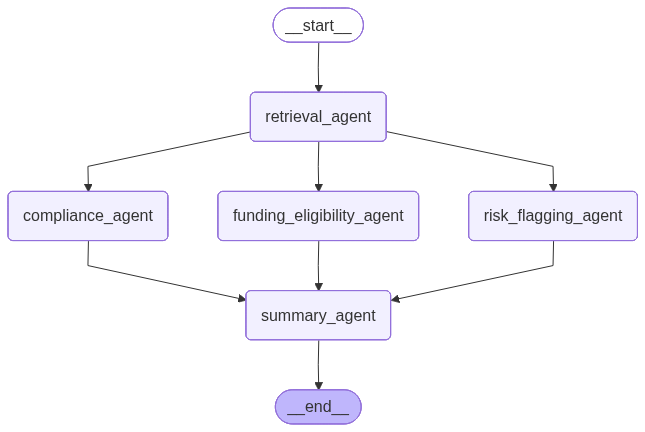

In [ ]:
# ============================================================
# Cell 9 — LangGraph Multi-Agent Pipeline
# 5 agents: Retrieval → [Compliance + Risk Flagging + Funding] → Summary
# The 3 specialist agents run in PARALLEL after Retrieval.
# ============================================================

!pip install langgraph -q

from typing import TypedDict, Optional, List, Dict, Any
from langgraph.graph import StateGraph, START, END
import json

# ── Shared State ─────────────────────────────────────────────
class ScreeningState(TypedDict):
    query:                str
    crossing_id:          Optional[str]
    route:                Dict[str, Any]
    structured_facts:     Dict[str, Any]
    semantic_chunks:      List[Dict[str, Any]]
    compliance_findings:  str
    risk_flags:           str
    funding_assessment:   str
    memo:                 str


# ── LLM helper ───────────────────────────────────────────────
def call_llm(prompt: str, max_tokens: int = 700) -> str:
    response = client_openai.responses.create(
        model="gpt-4o-mini",
        input=prompt,
        temperature=0.2,
        max_output_tokens=max_tokens
    )
    return response.output_text


# ══════════════════════════════════════════════════════════════
# AGENT 1 — RETRIEVAL AGENT
# Gathers ALL information needed by the specialist agents:
#   - Routes the query
#   - Retrieves structured facts from Form 71 / Form 57 (pandas)
#   - Retrieves semantic chunks from ChromaDB
# ══════════════════════════════════════════════════════════════

def retrieval_agent(state: ScreeningState) -> dict:
    print("\n[1/5] RETRIEVAL AGENT — Gathering structured + semantic context...")

    query       = state["query"]
    crossing_id = extract_crossing_id(query)
    route       = route_query(query)

    # ── Structured lookup (pandas — deterministic) ────────────
    mode  = route.get("structured_mode")
    facts = {}

    if mode == "crossing_id_lookup":
        facts = structured_lookup_by_crossing_id(crossing_id)
        print(f"   Structured: crossing_id_lookup → {crossing_id}")

    elif mode == "scenario_filter":
        facts = {
            "scenario_filter_results":
                structured_filter_by_scenario(query, top_n=5)
        }
        print("   Structured: scenario_filter → top 5 matching crossings")

    elif mode == "warning_device_aggregate":
        facts = {
            "warning_device_fatality_rate_2020_2025":
                compute_warning_device_fatality_rate_2020_2025(top_n=10)
        }
        print("   Structured: warning_device_aggregate → fatality rates by device")

    else:
        print("   Structured: no structured lookup needed for this query")

    # ── Semantic retrieval (ChromaDB) ─────────────────────────
    collections = route.get("collections", ["federal_corpus"])
    existing    = set(c.name for c in client.list_collections())
    usable      = [c for c in collections if c in existing]

    if not usable:
        usable = list(existing)[:1]

    chunks = semantic_retrieve(query, usable, k=4)
    print(f"   Semantic: {len(chunks)} chunks from {usable}")

    return {
        "crossing_id":         crossing_id,
        "route":               route,
        "structured_facts":    facts,
        "semantic_chunks":     chunks,
        "compliance_findings": "",
        "risk_flags":          "",
        "funding_assessment":  ""
    }


# ══════════════════════════════════════════════════════════════
# AGENT 2 — COMPLIANCE AGENT
# Reads retrieved context and identifies applicable regulatory
# obligations. Focuses on: 49 CFR Part 234, MUTCD, Federal
# Register rules, state action plans.
# FIX: if no compliance-relevant chunks are found, returns a
# clean "not applicable" message instead of repeating
# "Not supported by retrieved context" five times.
# ══════════════════════════════════════════════════════════════

def compliance_agent(state: ScreeningState) -> dict:
    print("\n[2/5] COMPLIANCE AGENT — Checking regulatory obligations...")

    query  = state["query"]
    chunks = state["semantic_chunks"]

    # Filter for compliance-relevant chunks only
    compliance_chunks = [
        c for c in chunks
        if c.get("doc_type") in ["federal_rule", "MUTCD", "state_action_plan"]
        or c.get("collection") == "federal_corpus"
    ]

    # ── FIX: skip LLM call if no relevant chunks found ────────
    if not compliance_chunks:
        print("   No compliance-relevant chunks found. Skipping LLM call.")
        return {
            "compliance_findings": (
                "No compliance obligations directly applicable to this query "
                "were found in the retrieved context."
            )
        }

    context_text = "\n\n---\n\n".join(
        f"[Source: {c.get('source_file')} | Section: {c.get('section_id', 'N/A')}]\n{c['text'][:800]}"
        for c in compliance_chunks[:3]
    )

    prompt = f"""You are a railroad compliance specialist.

USER QUESTION: {query}

RETRIEVED REGULATORY CONTEXT:
{context_text}

Your task: Identify ONLY the compliance obligations directly supported by the context above.
- Cite specific regulation sections (e.g., 49 CFR §234.207).
- If the context does not support a compliance point, say "Not supported by retrieved context."
- Be concise. Use bullet points. Max 6 bullets.
- Do NOT invent regulations.

Write only the COMPLIANCE FINDINGS section."""

    findings = call_llm(prompt, max_tokens=400)
    print("   Done.")
    return {"compliance_findings": findings}


# ══════════════════════════════════════════════════════════════
# AGENT 3 — RISK FLAGGING AGENT
# Reads structured crossing facts + incident narratives and
# flags safety risks. Focuses on: warning devices, incident
# history, traffic exposure, train speed.
# ══════════════════════════════════════════════════════════════

def risk_flagging_agent(state: ScreeningState) -> dict:
    print("\n[3/5] RISK FLAGGING AGENT — Identifying safety risk factors...")

    query  = state["query"]
    facts  = state["structured_facts"]
    chunks = state["semantic_chunks"]

    risk_chunks = [
        c for c in chunks
        if c.get("doc_type") in [
            "handbook", "audit", "incident_narrative", "methodology_reference"
        ]
        or "risk" in c.get("agent_role", "")
    ]

    structured_text = (
        json.dumps(facts, indent=2, default=str)[:1200]
        if facts else "No structured facts retrieved."
    )

    context_text = "\n\n---\n\n".join(
        f"[Source: {c.get('source_file')} | Type: {c.get('doc_type')}]\n{c['text'][:600]}"
        for c in risk_chunks[:3]
    ) if risk_chunks else "No specific risk-guidance chunks retrieved."

    prompt = f"""You are a railroad safety risk analyst.

USER QUESTION: {query}

STRUCTURED CROSSING FACTS (from FRA Form 71 + Form 57):
{structured_text}

RETRIEVED SAFETY GUIDANCE CONTEXT:
{context_text}

Your task: Identify the key SAFETY RISK FLAGS for this crossing or scenario.
Rules:
- Base every risk flag on the structured facts OR the retrieved guidance context.
- Do NOT treat "not in a quiet zone" as a risk factor unless context supports it.
- Flag missing data as an uncertainty, not a confirmed risk.
- Be specific: cite crossing ID, incident counts, fatality numbers, warning device type.
- Use bullet points. Max 5 flags.

Write only the RISK FLAGS section."""

    flags = call_llm(prompt, max_tokens=400)
    print("   Done.")
    return {"risk_flags": flags}


# ══════════════════════════════════════════════════════════════
# AGENT 4 — FUNDING ELIGIBILITY AGENT
# Reviews RCE NOFO criteria + crossing profile to assess
# funding fit. Always uses cautious language.
# ══════════════════════════════════════════════════════════════

def funding_eligibility_agent(state: ScreeningState) -> dict:
    print("\n[4/5] FUNDING ELIGIBILITY AGENT — Assessing grant eligibility...")

    query  = state["query"]
    facts  = state["structured_facts"]
    chunks = state["semantic_chunks"]

    funding_chunks = [
        c for c in chunks
        if c.get("collection") == "funding_corpus"
        or c.get("doc_type") in ["NOFO", "award_example"]
    ]

    structured_text = (
        json.dumps(facts, indent=2, default=str)[:1000]
        if facts else "No structured crossing facts."
    )

    context_text = "\n\n---\n\n".join(
        f"[Source: {c.get('source_file')} | Section: {c.get('section_id', 'N/A')}]\n{c['text'][:800]}"
        for c in funding_chunks[:3]
    ) if funding_chunks else "No specific RCE funding chunks retrieved."

    prompt = f"""You are a federal grant eligibility reviewer specializing in the \
RCE (Railroad Crossing Elimination) Program.

USER QUESTION: {query}

CROSSING PROFILE (structured facts):
{structured_text}

RETRIEVED RCE FUNDING GUIDANCE:
{context_text}

Your task: Assess the FUNDING ELIGIBILITY of this crossing or scenario.
Rules:
- Use CAUTIOUS language: "appears to be a candidate for further review",
  "may align with funding priorities."
- NEVER say "qualifies" unless the retrieved NOFO text explicitly confirms
  ALL eligibility conditions.
- If cost-share requirements are mentioned in context, include them.
- If funding context is insufficient, say so clearly.
- Use bullet points. Max 4 points.

Write only the FUNDING ELIGIBILITY ASSESSMENT section."""

    assessment = call_llm(prompt, max_tokens=400)
    print("   Done.")
    return {"funding_assessment": assessment}


# ══════════════════════════════════════════════════════════════
# AGENT 5 — SUMMARY AGENT
# Combines outputs from ALL specialist agents into the final
# screening brief. The only agent that sees all three outputs.
# ══════════════════════════════════════════════════════════════

def summary_agent(state: ScreeningState) -> dict:
    print("\n[5/5] SUMMARY AGENT — Assembling final screening brief...")

    query               = state["query"]
    facts               = state["structured_facts"]
    compliance_findings = state["compliance_findings"]
    risk_flags          = state["risk_flags"]
    funding_assessment  = state["funding_assessment"]
    chunks              = state["semantic_chunks"]

    structured_text = (
        json.dumps(facts, indent=2, default=str)[:800]
        if facts else "No structured facts."
    )

    sources_used = list({
        c.get("source_file") for c in chunks if c.get("source_file")
    })

    prompt = f"""You are the lead transportation safety analyst.
You have received findings from three specialist agents.
Your task is to assemble a concise, professional SCREENING BRIEF.

USER QUESTION:
{query}

KEY STRUCTURED FACTS:
{structured_text}

COMPLIANCE AGENT FINDINGS:
{compliance_findings}

RISK FLAGGING AGENT FINDINGS:
{risk_flags}

FUNDING ELIGIBILITY AGENT ASSESSMENT:
{funding_assessment}

SOURCES CONSULTED: {', '.join(sources_used) if sources_used else 'See agent findings above.'}

Write the final SCREENING BRIEF using exactly this structure:

### Railroad Grade Crossing Safety Screening Brief

**1. Key Structured Facts**
[Summarize the most important crossing-level data]

**2. Safety Risk Flags**
[From the Risk Flagging Agent — concise bullets]

**3. Compliance Considerations**
[From the Compliance Agent — concise bullets. If not applicable, say so briefly.]

**4. Funding Fit**
[From the Funding Eligibility Agent — cautious language]

**5. Recommended Next Steps**
[What should the analyst do next?]

**6. Sources Used**
[List sources]

Keep the brief concise, professional, and evidence-based.
Do NOT add new claims not supported by the agent findings above."""

    memo = call_llm(prompt, max_tokens=900)
    print("   Done. Screening brief ready.\n")
    return {"memo": memo}


# ── Build the graph ───────────────────────────────────────────

builder = StateGraph(ScreeningState)

builder.add_node("retrieval_agent",           retrieval_agent)
builder.add_node("compliance_agent",          compliance_agent)
builder.add_node("risk_flagging_agent",       risk_flagging_agent)
builder.add_node("funding_eligibility_agent", funding_eligibility_agent)
builder.add_node("summary_agent",             summary_agent)

builder.add_edge(START, "retrieval_agent")

# Fan-out: Retrieval → [Compliance + Risk + Funding] in PARALLEL
builder.add_edge("retrieval_agent", "compliance_agent")
builder.add_edge("retrieval_agent", "risk_flagging_agent")
builder.add_edge("retrieval_agent", "funding_eligibility_agent")

# Fan-in: all three specialist agents → Summary
builder.add_edge("compliance_agent",          "summary_agent")
builder.add_edge("risk_flagging_agent",       "summary_agent")
builder.add_edge("funding_eligibility_agent", "summary_agent")

builder.add_edge("summary_agent", END)

screening_graph = builder.compile()

print("LangGraph 5-agent pipeline compiled successfully.")
print()
print("Architecture:")
print("  START")
print("    └─► [1] Retrieval Agent  (structured + semantic)")
print("              ├─► [2] Compliance Agent          ─┐")
print("              ├─► [3] Risk Flagging Agent       ─┼─► [5] Summary Agent ─► END")
print("              └─► [4] Funding Eligibility Agent ─┘")

# ── Visualize ────────────────────────────────────────────────
try:
    from IPython.display import Image, display
    display(Image(screening_graph.get_graph().draw_mermaid_png()))
except Exception:
    print("\nGraph (Mermaid text):")
    print(screening_graph.get_graph().draw_mermaid())


# ── Run function ─────────────────────────────────────────────
def run_langgraph_pipeline(query: str) -> dict:
    """Run the full 5-agent LangGraph screening pipeline."""

    print("=" * 70)
    print("QUERY:", query)
    print("=" * 70)

    initial_state: ScreeningState = {
        "query":                query,
        "crossing_id":          None,
        "route":                {},
        "structured_facts":     {},
        "semantic_chunks":      [],
        "compliance_findings":  "",
        "risk_flags":           "",
        "funding_assessment":   "",
        "memo":                 ""
    }

    final_state = screening_graph.invoke(initial_state)

    print("\n" + "=" * 70)
    print("FINAL SCREENING BRIEF")
    print("=" * 70)
    print(final_state["memo"])

    return final_state

In [ ]:
# ============================================================
# Cell 10 — Test the 5-Agent Pipeline
# ============================================================

# ── Query 1: Compliance-focused ──────────────────────────────
result_1 = run_langgraph_pipeline(
    "Under 49 CFR Part 234, what are a railroad's obligations "
    "after a warning system activation failure is reported?"
)

# ── Query 2: Risk + Funding ──────────────────────────────────
result_2 = run_langgraph_pipeline(
    "Does a public crossing with crossbucks only and recent fatalities "
    "qualify for RCE grant funding?"
)

# ── Query 3: Specific crossing ───────────────────────────────
result_3 = run_langgraph_pipeline(
    "Crossing 870880G had multiple recent incidents. "
    "What are the key risk factors and what treatment does FRA guidance recommend?"
)


# ── Show what each agent contributed ─────────────────────────
print("\n" + "=" * 70)
print("AGENT CONTRIBUTION BREAKDOWN (Query 3)")
print("=" * 70)

print("\n[Retrieval Agent]")
print("  Crossing ID found:", result_3["crossing_id"])
print("  Route:", result_3["route"])
print("  Structured facts keys:", list(result_3["structured_facts"].keys()))
print("  Chunks retrieved:", len(result_3["semantic_chunks"]))

print("\n[Compliance Agent output preview]")
print(result_3["compliance_findings"][:300])

print("\n[Risk Flagging Agent output preview]")
print(result_3["risk_flags"][:300])

print("\n[Funding Eligibility Agent output preview]")
print(result_3["funding_assessment"][:300])

print("\n[Summary Agent — full brief]")
print(result_3["memo"])


# ── Streaming demo: watch agents fire in real time ───────────
print("\n\n" + "=" * 70)
print("STREAMING DEMO — Watch each agent fire in real time")
print("=" * 70)

initial = {
    "query":                "Crossing 870880G had multiple recent incidents. "
                            "What are the key risk factors?",
    "crossing_id":          None,
    "route":                {},
    "structured_facts":     {},
    "semantic_chunks":      [],
    "compliance_findings":  "",
    "risk_flags":           "",
    "funding_assessment":   "",
    "memo":                 ""
}

for step in screening_graph.stream(initial):
    agent_name = list(step.keys())[0]
    print(f"\n→ AGENT FIRED: {agent_name.upper().replace('_', ' ')}")

QUERY: Under 49 CFR Part 234, what are a railroad's obligations after a warning system activation failure is reported?

[1/5] RETRIEVAL AGENT — Gathering structured + semantic context...
   Structured: no structured lookup needed for this query
   Semantic: 4 chunks from ['federal_corpus']

[2/5] COMPLIANCE AGENT — Checking regulatory obligations...

[4/5] FUNDING ELIGIBILITY AGENT — Assessing grant eligibility...

[3/5] RISK FLAGGING AGENT — Identifying safety risk factors...
   Done.
   Done.
   Done.

[5/5] SUMMARY AGENT — Assembling final screening brief...
   Done. Screening brief ready.


FINAL SCREENING BRIEF
### Railroad Grade Crossing Safety Screening Brief

**1. Key Structured Facts**  
- No structured data available regarding incident counts, fatality numbers, or specific warning device types at the crossing.

**2. Safety Risk Flags**  
- Warning System Activation Failure: Prompt action is essential to mitigate safety risks; delays could increase accident likelihood.  
- Lac

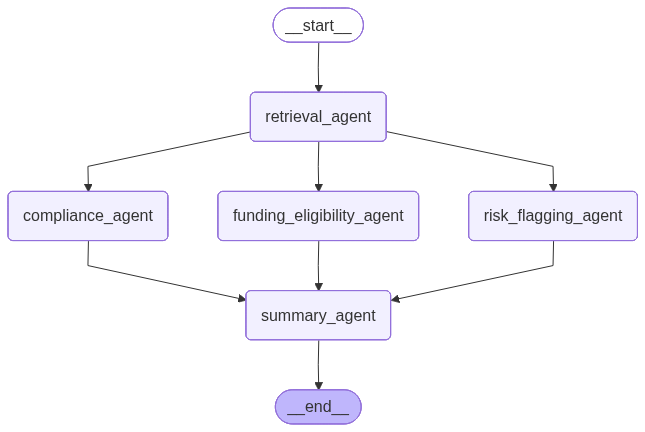

Diagram saved to: /content/pipeline_diagram.png
Download it from the Colab Files panel (left sidebar).
Interactive HTML diagram saved to: /content/pipeline_diagram_interactive.html
Download it from the Colab Files panel (left sidebar).


/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [ ]:
# ============================================================
# Cell 11 — Generate Pipeline Architecture Diagram
# Run AFTER Cell 9 (screening_graph must be compiled).
# ============================================================

# ── Option A: LangGraph built-in Mermaid PNG (best for Colab) ──
try:
    from IPython.display import Image, display, HTML
    import base64

    png_bytes = screening_graph.get_graph().draw_mermaid_png()

    # Display inline in Colab
    display(Image(png_bytes))

    # Also save to file so you can download it
    with open("/content/pipeline_diagram.png", "wb") as f:
        f.write(png_bytes)

    print("Diagram saved to: /content/pipeline_diagram.png")
    print("Download it from the Colab Files panel (left sidebar).")

except Exception as e:
    print(f"Mermaid PNG failed: {e}")
    print("Falling back to Mermaid text below.\n")

    # ── Option B: Mermaid text fallback ─────────────────────
    mermaid_text = screening_graph.get_graph().draw_mermaid()
    print(mermaid_text)
    print("\nPaste the text above into https://mermaid.live to render it.")


# ── Option C: Full custom HTML diagram (interactive, downloadable) ──
html_diagram = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>LangGraph Pipeline</title>
<style>
  body { font-family: sans-serif; background: #f8f8f6; display: flex;
         justify-content: center; align-items: flex-start; padding: 32px; }
  svg  { max-width: 860px; width: 100%; }

  .node { cursor: pointer; }
  .node:hover rect { opacity: 0.85; }

  /* Agent colors */
  .ag-teal   rect { fill: #E1F5EE; stroke: #0F6E56; }
  .ag-blue   rect { fill: #E6F1FB; stroke: #185FA5; }
  .ag-coral  rect { fill: #FAECE7; stroke: #993C1D; }
  .ag-amber  rect { fill: #FAEEDA; stroke: #854F0B; }
  .ag-purple rect { fill: #EEEDFE; stroke: #534AB7; }
  .ag-gray   rect { fill: #F1EFE8; stroke: #5F5E5A; }

  .ag-teal   .title { fill: #085041; } .ag-teal   .sub { fill: #0F6E56; }
  .ag-blue   .title { fill: #0C447C; } .ag-blue   .sub { fill: #185FA5; }
  .ag-coral  .title { fill: #712B13; } .ag-coral  .sub { fill: #993C1D; }
  .ag-amber  .title { fill: #633806; } .ag-amber  .sub { fill: #854F0B; }
  .ag-purple .title { fill: #3C3489; } .ag-purple .sub { fill: #534AB7; }
  .ag-gray   .title { fill: #444441; } .ag-gray   .sub { fill: #5F5E5A; }

  .connector { fill: none; stroke: #b4b2a9; stroke-width: 0.5; }
  .arr-line  { fill: none; stroke: #888780; stroke-width: 1.5;
               marker-end: url(#arrow); }
  .dashed    { fill: none; stroke: #b4b2a9; stroke-width: 0.5;
               stroke-dasharray: 4 3; }
  .lbl       { font-size: 11px; fill: #888780; }

  /* Tooltip */
  #tip {
    position: fixed; bottom: 28px; left: 50%; transform: translateX(-50%);
    background: #2c2c2a; color: #f1efe8; border-radius: 10px;
    padding: 14px 20px; max-width: 480px; width: 90%; font-size: 13px;
    line-height: 1.6; box-shadow: 0 4px 24px rgba(0,0,0,.18);
    opacity: 0; transition: opacity .2s; pointer-events: none; text-align: left;
  }
  #tip.show { opacity: 1; }
  #tip strong { display: block; margin-bottom: 6px; font-size: 14px; color: #fff; }
</style>
</head>
<body>

<svg viewBox="0 0 680 450" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5"
            markerWidth="6" markerHeight="6" orient="auto-start-reverse">
      <path d="M2 1L8 5L2 9" fill="none" stroke="#888780"
            stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
    </marker>
  </defs>

  <!-- Start -->
  <g class="ag-gray">
    <rect x="290" y="22" width="100" height="32" rx="16" stroke-width="0.5"/>
    <text class="title" x="340" y="38" text-anchor="middle"
          dominant-baseline="central" font-size="13" font-weight="500">Start</text>
  </g>

  <!-- Start → Retrieval -->
  <line class="arr-line" x1="340" y1="54" x2="340" y2="94"/>

  <!-- [1] Retrieval agent -->
  <g class="node ag-teal"
     data-title="Retrieval agent"
     data-desc="Routes the query, runs a deterministic pandas lookup on Form 71 and Form 57 (crossing_id_lookup / scenario_filter / warning_device_aggregate), then queries ChromaDB with sentence-transformer embeddings to pull the top-k semantic chunks. All downstream agents share this context via the ScreeningState.">
    <rect x="190" y="96" width="300" height="60" rx="8" stroke-width="0.5"/>
    <text class="title" x="340" y="116" text-anchor="middle"
          dominant-baseline="central" font-size="14" font-weight="500">Retrieval agent</text>
    <text class="sub" x="340" y="136" text-anchor="middle"
          dominant-baseline="central" font-size="12">Structured &amp; semantic lookup</text>
  </g>

  <!-- Fan-out -->
  <line class="connector" x1="340" y1="156" x2="340" y2="176"/>
  <line class="connector" x1="145" y1="176" x2="535" y2="176"/>
  <line class="arr-line"  x1="145" y1="176" x2="145" y2="194"/>
  <line class="arr-line"  x1="340" y1="176" x2="340" y2="194"/>
  <line class="arr-line"  x1="535" y1="176" x2="535" y2="194"/>

  <!-- Parallel container -->
  <rect class="dashed" x="44" y="185" width="592" height="80" rx="8"/>
  <text class="lbl" x="52" y="199">parallel execution</text>

  <!-- [2] Compliance agent -->
  <g class="node ag-blue"
     data-title="Compliance agent"
     data-desc="Filters the semantic chunks for federal_rule, MUTCD, and state_action_plan doc types. If relevant chunks exist, prompts the LLM to cite specific CFR sections (e.g., 49 CFR §234.207). If no compliance-relevant chunks are found, returns a clean 'not applicable' message without calling the LLM.">
    <rect x="55" y="196" width="180" height="60" rx="8" stroke-width="0.5"/>
    <text class="title" x="145" y="216" text-anchor="middle"
          dominant-baseline="central" font-size="13" font-weight="500">Compliance agent</text>
    <text class="sub" x="145" y="236" text-anchor="middle"
          dominant-baseline="central" font-size="12">Regulatory obligations</text>
  </g>

  <!-- [3] Risk flagging agent -->
  <g class="node ag-coral"
     data-title="Risk flagging agent"
     data-desc="Uses structured crossing facts (incident count, fatalities, AADT, warning device, train speed) from Form 71 + Form 57, combined with handbook and audit chunks from ChromaDB. Flags only risks grounded in actual data — never invents risks from missing information or quiet-zone status alone.">
    <rect x="250" y="196" width="180" height="60" rx="8" stroke-width="0.5"/>
    <text class="title" x="340" y="216" text-anchor="middle"
          dominant-baseline="central" font-size="13" font-weight="500">Risk flagging agent</text>
    <text class="sub" x="340" y="236" text-anchor="middle"
          dominant-baseline="central" font-size="12">Safety risk flags</text>
  </g>

  <!-- [4] Funding agent -->
  <g class="node ag-amber"
     data-title="Funding agent"
     data-desc="Retrieves RCE NOFO and award-example chunks from the funding_corpus collection. Always uses cautious language — avoids saying 'qualifies' unless all eligibility conditions are explicitly confirmed in the retrieved NOFO text. Includes cost-share requirements when found.">
    <rect x="445" y="196" width="180" height="60" rx="8" stroke-width="0.5"/>
    <text class="title" x="535" y="216" text-anchor="middle"
          dominant-baseline="central" font-size="13" font-weight="500">Funding agent</text>
    <text class="sub" x="535" y="236" text-anchor="middle"
          dominant-baseline="central" font-size="12">Grant eligibility</text>
  </g>

  <!-- Fan-in -->
  <line class="connector" x1="145" y1="256" x2="145" y2="276"/>
  <line class="connector" x1="340" y1="256" x2="340" y2="276"/>
  <line class="connector" x1="535" y1="256" x2="535" y2="276"/>
  <line class="connector" x1="145" y1="276" x2="535" y2="276"/>
  <line class="arr-line"  x1="340" y1="276" x2="340" y2="294"/>

  <!-- [5] Summary agent -->
  <g class="node ag-purple"
     data-title="Summary agent"
     data-desc="The only agent that sees all three specialist outputs together. Merges compliance findings, risk flags, and funding assessment into a structured 6-section screening brief: Key Facts → Risk Flags → Compliance → Funding Fit → Next Steps → Sources. Never adds claims not supported by the specialist agents.">
    <rect x="190" y="296" width="300" height="60" rx="8" stroke-width="0.5"/>
    <text class="title" x="340" y="316" text-anchor="middle"
          dominant-baseline="central" font-size="14" font-weight="500">Summary agent</text>
    <text class="sub" x="340" y="336" text-anchor="middle"
          dominant-baseline="central" font-size="12">Final screening brief</text>
  </g>

  <!-- Summary → End -->
  <line class="arr-line" x1="340" y1="356" x2="340" y2="390"/>

  <!-- End -->
  <g class="ag-gray">
    <rect x="290" y="392" width="100" height="32" rx="16" stroke-width="0.5"/>
    <text class="title" x="340" y="408" text-anchor="middle"
          dominant-baseline="central" font-size="13" font-weight="500">End</text>
  </g>
</svg>

<div id="tip"></div>

<script>
  const tip = document.getElementById('tip');
  let timer;

  document.querySelectorAll('.node').forEach(node => {
    node.addEventListener('click', () => {
      const title = node.dataset.title;
      const desc  = node.dataset.desc;
      tip.innerHTML = `<strong>${title}</strong>${desc}`;
      tip.classList.add('show');
      clearTimeout(timer);
      timer = setTimeout(() => tip.classList.remove('show'), 7000);
    });
  });

  document.addEventListener('click', e => {
    if (!e.target.closest('.node')) tip.classList.remove('show');
  });
</script>
</body>
</html>
"""

# Save HTML file for download
with open("/content/pipeline_diagram_interactive.html", "w", encoding="utf-8") as f:
    f.write(html_diagram)

print("Interactive HTML diagram saved to: /content/pipeline_diagram_interactive.html")
print("Download it from the Colab Files panel (left sidebar).")

# Also display it inline in Colab
b64 = base64.b64encode(html_diagram.encode()).decode()
display(HTML(f'<iframe src="data:text/html;base64,{b64}" width="100%" height="520" frameborder="0"></iframe>'))

LangGraph v2 (with feedback loop) compiled successfully.

Architecture:
  START
    └─► [1] Retrieval Agent
              ├─► [2] Compliance Agent       ─┐
              ├─► [3] Risk Flagging Agent    ─┼─► [5] Summary Agent
              └─► [4] Funding Agent          ─┘         │
                                                   [6] Critic Agent
                                                    ├── PASS ──► END
                                                    └── REVISE ─► [7] Revised Summary ─► END


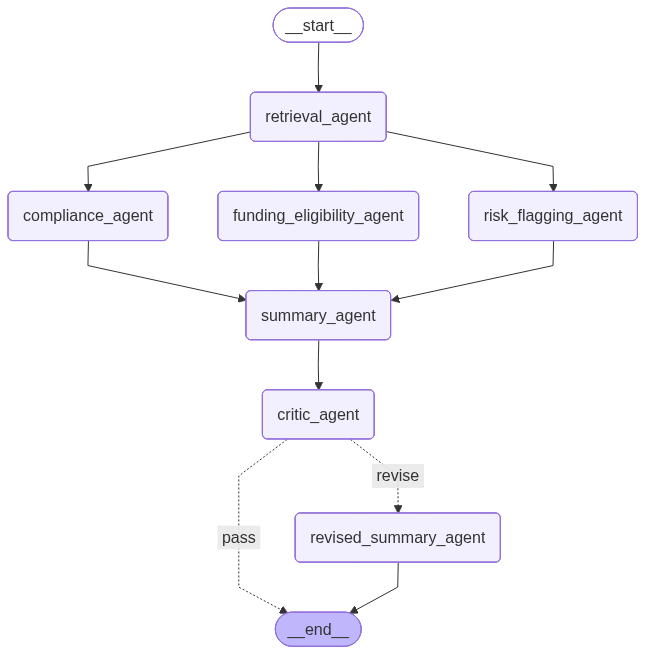

QUERY: Under 49 CFR Part 234, what are a railroad's obligations after a warning system activation failure is reported?

[1/5] RETRIEVAL AGENT — Gathering structured + semantic context...
   Structured: no structured lookup needed for this query
   Semantic: 4 chunks from ['federal_corpus']

[2/5] COMPLIANCE AGENT — Checking regulatory obligations...

[4/5] FUNDING ELIGIBILITY AGENT — Assessing grant eligibility...

[3/5] RISK FLAGGING AGENT — Identifying safety risk factors...
   Done.
   Done.
   Done.

[5/5] SUMMARY AGENT — Assembling final screening brief...
   Done. Screening brief ready.


[CRITIC AGENT] Reviewing screening brief...
   Verdict: REVISE — sending back to Summary Agent

[REVISED SUMMARY AGENT] Rewriting memo based on critique...
   Done. Revised memo ready.

CRITIC VERDICT: REVISE — memo was improved

CRITIQUE:
1. **UNSUPPORTED CLAIMS** — None found.

2. **MISSING INFORMATION** — The memo lacks specific details on the obligations of railroads after a warning system a

In [ ]:
# ============================================================
# Cell 15 — Agentic Feedback Loop
# Adds a Critic Agent that reviews the Summary Agent's memo
# and challenges unsupported claims. If issues are found,
# the Summary Agent revises the memo based on the critique.
#
# Architecture:
#   [existing 5 agents] → Critic Agent → Summary Agent (revised)
#
# Run AFTER Cell 9 (screening_graph must be compiled).
# ============================================================

from typing import TypedDict, Optional, List, Dict, Any
from langgraph.graph import StateGraph, START, END
import json

# ── Extend ScreeningState to include critique fields ─────────
class ScreeningStateV2(TypedDict):
    # Original fields (from Cell 9)
    query:                str
    crossing_id:          Optional[str]
    route:                Dict[str, Any]
    structured_facts:     Dict[str, Any]
    semantic_chunks:      List[Dict[str, Any]]
    compliance_findings:  str
    risk_flags:           str
    funding_assessment:   str
    memo:                 str
    # New fields for feedback loop
    critique:             str   # Critic Agent's findings
    memo_revised:         str   # Summary Agent's revised memo
    critique_passed:      bool  # True if no major issues found


# ══════════════════════════════════════════════════════════════
# CRITIC AGENT
# Reviews the Summary Agent's memo and challenges:
#   1. Unsupported claims (no source backing)
#   2. Missing important information
#   3. Whether the query was actually answered
# ══════════════════════════════════════════════════════════════

def critic_agent(state: ScreeningStateV2) -> dict:
    print("\n[CRITIC AGENT] Reviewing screening brief...")

    query     = state["query"]
    memo      = state["memo"]
    facts     = state["structured_facts"]
    chunks    = state["semantic_chunks"]

    sources_available = list({
        c.get("source_file") for c in chunks if c.get("source_file")
    })

    structured_summary = json.dumps(facts, default=str)[:600] if facts else "None"

    prompt = f"""You are a senior transportation safety reviewer.
Your job is to critically evaluate a screening memo and identify any weaknesses.

ORIGINAL QUERY:
{query}

SCREENING MEMO TO REVIEW:
{memo}

AVAILABLE EVIDENCE:
- Structured facts: {structured_summary}
- Retrieved sources: {', '.join(sources_available) if sources_available else 'None'}

Evaluate the memo on these three criteria:

1. UNSUPPORTED CLAIMS — List any statements in the memo that are NOT backed by
   the structured facts or retrieved sources above. Write "None found" if all
   claims are supported.

2. MISSING INFORMATION — What important information relevant to the query is
   missing from the memo? Write "None" if the memo is complete.

3. QUERY ANSWERED — Does the memo directly answer the original query?
   Write "Yes" or "No — [reason]".

4. OVERALL VERDICT — Write either:
   "PASS" — memo is acceptable as-is, or
   "REVISE" — memo has significant issues that need fixing

Be specific and concise. Do NOT rewrite the memo — only identify issues."""

    critique = call_llm(prompt, max_tokens=500)

    # Determine if revision is needed
    critique_passed = "PASS" in critique.upper() and "REVISE" not in critique.upper()

    status = "PASS — no revision needed" if critique_passed else "REVISE — sending back to Summary Agent"
    print(f"   Verdict: {status}")

    return {
        "critique":        critique,
        "critique_passed": critique_passed,
    }


# ══════════════════════════════════════════════════════════════
# REVISED SUMMARY AGENT
# Only runs if Critic Agent returned REVISE.
# Rewrites the memo addressing the critique points.
# ══════════════════════════════════════════════════════════════

def revised_summary_agent(state: ScreeningStateV2) -> dict:
    print("\n[REVISED SUMMARY AGENT] Rewriting memo based on critique...")

    query    = state["query"]
    memo     = state["memo"]
    critique = state["critique"]
    facts    = state["structured_facts"]
    chunks   = state["semantic_chunks"]

    structured_text = json.dumps(facts, indent=2, default=str)[:800] if facts else "No structured facts."
    sources_used    = list({c.get("source_file") for c in chunks if c.get("source_file")})

    prompt = f"""You are the lead transportation safety analyst.
You previously wrote a screening brief, but a senior reviewer identified issues.
Revise the memo to address the critique.

ORIGINAL QUERY:
{query}

YOUR ORIGINAL MEMO:
{memo}

REVIEWER CRITIQUE:
{critique}

KEY STRUCTURED FACTS:
{structured_text}

SOURCES AVAILABLE:
{', '.join(sources_used) if sources_used else 'See original memo.'}

Instructions:
- Address every point raised in the critique.
- Remove or qualify any unsupported claims.
- Fill in missing information if it exists in the structured facts or sources.
- Keep the same 6-section structure:
  1. Key Structured Facts
  2. Safety Risk Flags
  3. Compliance Considerations
  4. Funding Fit
  5. Recommended Next Steps
  6. Sources Used
- Do NOT add new claims not backed by the available evidence.

Write the REVISED SCREENING BRIEF:"""

    memo_revised = call_llm(prompt, max_tokens=900)
    print("   Done. Revised memo ready.")
    return {"memo_revised": memo_revised}


# ══════════════════════════════════════════════════════════════
# ROUTING LOGIC
# After Critic Agent: if PASS → END, if REVISE → Revised Summary
# ══════════════════════════════════════════════════════════════

def route_after_critique(state: ScreeningStateV2) -> str:
    if state.get("critique_passed", True):
        return "pass"
    return "revise"


# ══════════════════════════════════════════════════════════════
# BUILD EXTENDED GRAPH (v2)
# Wraps the existing 5-agent pipeline and adds the feedback loop
# ══════════════════════════════════════════════════════════════

builder_v2 = StateGraph(ScreeningStateV2)

# ── Re-register the original 5 agents ────────────────────────
builder_v2.add_node("retrieval_agent",            retrieval_agent)
builder_v2.add_node("compliance_agent",           compliance_agent)
builder_v2.add_node("risk_flagging_agent",        risk_flagging_agent)
builder_v2.add_node("funding_eligibility_agent",  funding_eligibility_agent)
builder_v2.add_node("summary_agent",              summary_agent)

# ── New agents ────────────────────────────────────────────────
builder_v2.add_node("critic_agent",               critic_agent)
builder_v2.add_node("revised_summary_agent",      revised_summary_agent)

# ── Original edges ────────────────────────────────────────────
builder_v2.add_edge(START, "retrieval_agent")
builder_v2.add_edge("retrieval_agent", "compliance_agent")
builder_v2.add_edge("retrieval_agent", "risk_flagging_agent")
builder_v2.add_edge("retrieval_agent", "funding_eligibility_agent")
builder_v2.add_edge("compliance_agent",           "summary_agent")
builder_v2.add_edge("risk_flagging_agent",        "summary_agent")
builder_v2.add_edge("funding_eligibility_agent",  "summary_agent")

# ── New edges: Summary → Critic → (Pass or Revise) ───────────
builder_v2.add_edge("summary_agent", "critic_agent")

builder_v2.add_conditional_edges(
    "critic_agent",
    route_after_critique,
    {
        "pass":   END,
        "revise": "revised_summary_agent",
    }
)

builder_v2.add_edge("revised_summary_agent", END)

# ── Compile ───────────────────────────────────────────────────
screening_graph_v2 = builder_v2.compile()

print("LangGraph v2 (with feedback loop) compiled successfully.")
print()
print("Architecture:")
print("  START")
print("    └─► [1] Retrieval Agent")
print("              ├─► [2] Compliance Agent       ─┐")
print("              ├─► [3] Risk Flagging Agent    ─┼─► [5] Summary Agent")
print("              └─► [4] Funding Agent          ─┘         │")
print("                                                   [6] Critic Agent")
print("                                                    ├── PASS ──► END")
print("                                                    └── REVISE ─► [7] Revised Summary ─► END")

# ── Visualize ─────────────────────────────────────────────────
try:
    from IPython.display import Image, display
    display(Image(screening_graph_v2.get_graph().draw_mermaid_png()))
except Exception:
    print("\nGraph (Mermaid text):")
    print(screening_graph_v2.get_graph().draw_mermaid())


# ══════════════════════════════════════════════════════════════
# RUN FUNCTION (v2)
# ══════════════════════════════════════════════════════════════

def run_pipeline_v2(query: str) -> dict:
    """Run the 7-agent pipeline with critic feedback loop."""

    print("=" * 70)
    print("QUERY:", query)
    print("=" * 70)

    initial: ScreeningStateV2 = {
        "query":               query,
        "crossing_id":         None,
        "route":               {},
        "structured_facts":    {},
        "semantic_chunks":     [],
        "compliance_findings": "",
        "risk_flags":          "",
        "funding_assessment":  "",
        "memo":                "",
        "critique":            "",
        "memo_revised":        "",
        "critique_passed":     False,
    }

    final = screening_graph_v2.invoke(initial)

    print("\n" + "=" * 70)

    if final.get("critique_passed"):
        print("CRITIC VERDICT: PASS — original memo accepted")
        print("\nFINAL MEMO:")
        print(final["memo"])
    else:
        print("CRITIC VERDICT: REVISE — memo was improved")
        print("\nCRITIQUE:")
        print(final["critique"])
        print("\nREVISED MEMO:")
        print(final["memo_revised"])

    return final


# ══════════════════════════════════════════════════════════════
# TEST — Run all 3 queries with feedback loop
# ══════════════════════════════════════════════════════════════

result_1 = run_pipeline_v2(
    "Under 49 CFR Part 234, what are a railroad's obligations "
    "after a warning system activation failure is reported?"
)

result_2 = run_pipeline_v2(
    "Does a public crossing with crossbucks only and recent fatalities "
    "qualify for RCE grant funding?"
)

result_3 = run_pipeline_v2(
    "Crossing 870880G had multiple recent incidents. "
    "What are the key risk factors and what treatment does FRA guidance recommend?"
)


# ── Summary: show critique for each query ─────────────────────
print("\n\n" + "=" * 70)
print("FEEDBACK LOOP SUMMARY")
print("=" * 70)

for i, (label, result) in enumerate([
    ("Q1 — Compliance",    result_1),
    ("Q2 — Risk+Funding",  result_2),
    ("Q3 — Crossing 870880G", result_3),
], start=1):
    verdict = "PASS" if result.get("critique_passed") else "REVISED"
    print(f"\n{label}:  [{verdict}]")
    if not result.get("critique_passed"):
        # Show first 300 chars of critique
        print("  Critique preview:", result["critique"][:300])

In [ ]:
html_content = """<!DOCTYPE html>
<html>
<head><meta charset="UTF-8"></head>
<body style="background:#fff; padding:20px">
<svg width="100%" viewBox="0 0 680 740">
<defs>
<marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
<path d="M2 1L8 5L2 9" fill="none" stroke="#666" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
</marker>
</defs>

<rect x="280" y="20" width="120" height="36" rx="18" fill="#f1efe8" stroke="#888" stroke-width="0.5"/>
<text x="340" y="38" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="14" font-weight="500">Start</text>
<line x1="340" y1="56" x2="340" y2="96" stroke="#888" stroke-width="1.5" marker-end="url(#arrow)"/>

<rect x="220" y="98" width="240" height="52" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="0.5"/>
<text x="340" y="118" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="14" font-weight="500" fill="#085041">Retrieval agent</text>
<text x="340" y="136" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#0F6E56">Structured lookup + ChromaDB</text>
<circle cx="460" cy="108" r="11" fill="#0F6E56"/>
<text x="460" y="108" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#fff">1</text>

<line x1="340" y1="150" x2="340" y2="172" stroke="#ccc" stroke-width="0.5"/>
<line x1="100" y1="172" x2="580" y2="172" stroke="#ccc" stroke-width="0.5"/>
<line x1="100" y1="172" x2="100" y2="192" stroke="#888" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="340" y1="172" x2="340" y2="192" stroke="#888" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="580" y1="172" x2="580" y2="192" stroke="#888" stroke-width="1.5" marker-end="url(#arrow)"/>
<text x="340" y="186" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#aaa" font-style="italic">parallel execution</text>

<rect x="20" y="194" width="160" height="52" rx="8" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="100" y="214" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="14" font-weight="500" fill="#0C447C">Compliance</text>
<text x="100" y="232" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#185FA5">49 CFR / MUTCD</text>
<circle cx="180" cy="204" r="11" fill="#185FA5"/>
<text x="180" y="204" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#fff">2</text>

<rect x="260" y="194" width="160" height="52" rx="8" fill="#FAECE7" stroke="#993C1D" stroke-width="0.5"/>
<text x="340" y="214" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="14" font-weight="500" fill="#712B13">Risk flagging</text>
<text x="340" y="232" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#993C1D">Form 71 + Form 57</text>
<circle cx="420" cy="204" r="11" fill="#993C1D"/>
<text x="420" y="204" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#fff">3</text>

<rect x="500" y="194" width="160" height="52" rx="8" fill="#FAEEDA" stroke="#854F0B" stroke-width="0.5"/>
<text x="580" y="214" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="14" font-weight="500" fill="#633806">Funding</text>
<text x="580" y="232" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#854F0B">RCE NOFO eligibility</text>
<circle cx="540" cy="204" r="11" fill="#854F0B"/>
<text x="540" y="204" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#fff">4</text>

<line x1="100" y1="246" x2="100" y2="318" stroke="#ccc" stroke-width="0.5"/>
<line x1="340" y1="246" x2="340" y2="318" stroke="#ccc" stroke-width="0.5"/>
<line x1="580" y1="246" x2="580" y2="318" stroke="#ccc" stroke-width="0.5"/>
<line x1="100" y1="318" x2="580" y2="318" stroke="#ccc" stroke-width="0.5"/>
<line x1="340" y1="318" x2="340" y2="338" stroke="#888" stroke-width="1.5" marker-end="url(#arrow)"/>

<rect x="220" y="340" width="240" height="52" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="0.5"/>
<text x="340" y="360" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="14" font-weight="500" fill="#3C3489">Summary agent</text>
<text x="340" y="378" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#534AB7">6-section screening brief</text>
<circle cx="460" cy="350" r="11" fill="#534AB7"/>
<text x="460" y="350" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#fff">5</text>

<line x1="340" y1="392" x2="340" y2="432" stroke="#888" stroke-width="1.5" marker-end="url(#arrow)"/>

<rect x="220" y="434" width="240" height="52" rx="8" fill="#FAECE7" stroke="#993C1D" stroke-width="0.5"/>
<text x="340" y="454" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="14" font-weight="500" fill="#712B13">Critic agent</text>
<text x="340" y="472" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#993C1D">Checks claims + completeness</text>
<circle cx="460" cy="444" r="11" fill="#993C1D"/>
<text x="460" y="444" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#fff">6</text>

<path d="M280 486 L200 530" stroke="#888" stroke-width="1.5" fill="none" marker-end="url(#arrow)"/>
<text x="222" y="514" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#aaa" font-style="italic">pass</text>
<path d="M400 486 L480 530" stroke="#888" stroke-width="1.5" fill="none" marker-end="url(#arrow)"/>
<text x="458" y="514" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#aaa" font-style="italic">revise</text>

<rect x="400" y="532" width="240" height="52" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="0.5"/>
<text x="520" y="552" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="14" font-weight="500" fill="#3C3489">Revised summary</text>
<text x="520" y="570" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#534AB7">Addresses critique points</text>
<circle cx="640" cy="542" r="11" fill="#534AB7"/>
<text x="640" y="542" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="12" fill="#fff">7</text>

<line x1="200" y1="532" x2="200" y2="688" stroke="#ccc" stroke-width="0.5"/>
<line x1="200" y1="688" x2="300" y2="688" stroke="#888" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="520" y1="584" x2="520" y2="688" stroke="#ccc" stroke-width="0.5"/>
<line x1="520" y1="688" x2="400" y2="688" stroke="#888" stroke-width="1.5" marker-end="url(#arrow)"/>

<rect x="300" y="670" width="120" height="36" rx="18" fill="#f1efe8" stroke="#888" stroke-width="0.5"/>
<text x="360" y="688" text-anchor="middle" dominant-baseline="central" font-family="sans-serif" font-size="14" font-weight="500">End</text>
</svg>
</body>
</html>"""

with open("/content/langgraph_diagram.html", "w") as f:
    f.write(html_content)

print("Saved: /content/langgraph_diagram.html")

Saved: /content/langgraph_diagram.html


In [ ]:
from IPython.display import HTML

with open("/content/langgraph_diagram.html", "r") as f:
    content = f.read()

HTML(content)

In [ ]:
# ============================================================
# Cell 12 — Visualization Agent + Professional Report Queries
# Adds a 6th agent that converts pipeline output into charts
# and a downloadable HTML report.
# Run AFTER Cell 9 (screening_graph must be compiled).
# ============================================================

!pip install plotly -q

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import json
import base64
from pathlib import Path
from IPython.display import display, HTML

OUTPUT_DIR = Path("/content/data/processed/update3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ══════════════════════════════════════════════════════════════
# CHART BUILDERS
# Each function takes structured_lookup (pandas DataFrame) and
# returns a Plotly figure as an HTML string.
# ══════════════════════════════════════════════════════════════

PLOTLY_LAYOUT = dict(
    font_family="'Inter', 'Segoe UI', sans-serif",
    font_color="#2c2c2a",
    paper_bgcolor="#ffffff",
    plot_bgcolor="#f8f8f6",
    margin=dict(l=60, r=40, t=60, b=60),
    title_font_size=15,
    title_font_color="#2c2c2a",
)


def chart_fatality_by_warning_device(df, top_n=12):
    """
    Bar chart: total fatalities and injuries by warning device type.
    Only shows device types with at least one incident.
    """
    grp = (
        df[df["incident_count_total"] > 0]
        .groupby("warning_device_label", as_index=False)
        .agg(
            fatalities=("fatalities_total", "sum"),
            injuries=("injuries_total", "sum"),
            crossings=("crossing_id", "count"),
            incidents=("incident_count_total", "sum"),
        )
    )

    grp["fatality_rate"] = grp["fatalities"] / grp["incidents"].clip(lower=1)
    grp = grp.nlargest(top_n, "fatalities")

    fig = go.Figure()
    fig.add_bar(
        name="Fatalities",
        x=grp["warning_device_label"],
        y=grp["fatalities"],
        marker_color="#D85A30",
        opacity=0.85,
    )
    fig.add_bar(
        name="Injuries",
        x=grp["warning_device_label"],
        y=grp["injuries"],
        marker_color="#378ADD",
        opacity=0.75,
    )
    fig.update_layout(
        **PLOTLY_LAYOUT,
        title="Fatalities & injuries by warning device type",
        barmode="group",
        xaxis_title="Warning device configuration",
        yaxis_title="Count (2020–2025)",
        xaxis_tickangle=-35,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        height=420,
    )
    return fig.to_html(full_html=False, include_plotlyjs=False)


def chart_top_crossings_table(df, n=15):
    """
    Table: top N crossings by fatalities (last 5 years).
    """
    cols = [
        "crossing_id", "state", "city", "street",
        "warning_device_label",
        "aadt", "train_movements_daily",
        "fatalities_5yr", "injuries_5yr", "incident_count_5yr",
        "incident_rate_5yr",
    ]
    existing = [c for c in cols if c in df.columns]

    top = (
        df[existing]
        .query("fatalities_5yr > 0")
        .nlargest(n, "fatalities_5yr")
        .copy()
    )

    top["incident_rate_5yr"] = top["incident_rate_5yr"].apply(
        lambda x: f"{x:.2e}" if pd.notna(x) else "N/A"
    )
    top["aadt"] = top["aadt"].apply(
        lambda x: f"{int(x):,}" if pd.notna(x) else "N/A"
    )
    top["train_movements_daily"] = top["train_movements_daily"].apply(
        lambda x: f"{int(x)}" if pd.notna(x) else "N/A"
    )

    labels = {
        "crossing_id":          "Crossing ID",
        "state":                "State",
        "city":                 "City",
        "street":               "Street",
        "warning_device_label": "Warning device",
        "aadt":                 "AADT",
        "train_movements_daily":"Daily trains",
        "fatalities_5yr":       "Fatalities (5yr)",
        "injuries_5yr":         "Injuries (5yr)",
        "incident_count_5yr":   "Incidents (5yr)",
        "incident_rate_5yr":    "Incident rate",
    }

    fig = go.Figure(
        data=[
            go.Table(
                columnwidth=[80, 50, 80, 100, 160, 70, 70, 80, 70, 80, 90],
                header=dict(
                    values=[labels.get(c, c) for c in existing],
                    fill_color="#2c2c2a",
                    font=dict(color="#f1efe8", size=12),
                    align="left",
                    height=36,
                ),
                cells=dict(
                    values=[top[c].tolist() for c in existing],
                    fill_color=[
                        ["#fff6f3" if i % 2 == 0 else "#ffffff"
                         for i in range(len(top))]
                    ],
                    font=dict(color="#2c2c2a", size=11),
                    align="left",
                    height=28,
                ),
            )
        ]
    )
    fig.update_layout(
        **PLOTLY_LAYOUT,
        title=f"Top {n} crossings by fatalities — last 5 years",
        height=100 + len(top) * 30,
        margin=dict(l=20, r=20, t=50, b=20),
    )
    return fig.to_html(full_html=False, include_plotlyjs=False)


def chart_incidents_by_year(form57_df):
    """
    Line chart: total incidents, fatalities, injuries by year.
    """
    if form57_df is None or form57_df.empty:
        return "<p>No Form 57 data available.</p>"

    yearly = (
        form57_df
        .groupby("incident_year", as_index=False)
        .agg(
            incidents=("crossing_id", "count"),
            fatalities=("fatalities", "sum"),
            injuries=("injuries", "sum"),
        )
        .query("incident_year >= 2015")
        .sort_values("incident_year")
    )

    fig = go.Figure()
    fig.add_scatter(
        name="Incidents",
        x=yearly["incident_year"], y=yearly["incidents"],
        mode="lines+markers", line=dict(color="#378ADD", width=2),
        marker=dict(size=6),
    )
    fig.add_scatter(
        name="Fatalities",
        x=yearly["incident_year"], y=yearly["fatalities"],
        mode="lines+markers", line=dict(color="#D85A30", width=2),
        marker=dict(size=6),
    )
    fig.add_scatter(
        name="Injuries",
        x=yearly["incident_year"], y=yearly["injuries"],
        mode="lines+markers", line=dict(color="#BA7517", width=2),
        marker=dict(size=6),
    )
    fig.update_layout(
        **PLOTLY_LAYOUT,
        title="Incidents, fatalities & injuries by year",
        xaxis_title="Year",
        yaxis_title="Count",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        height=380,
        xaxis=dict(dtick=1),
    )
    return fig.to_html(full_html=False, include_plotlyjs=False)


def chart_state_heatmap(df, top_n=20):
    """
    Horizontal bar: states ranked by 5-year fatalities.
    """
    state_grp = (
        df.groupby("state", as_index=False)
        .agg(
            fatalities_5yr=("fatalities_5yr", "sum"),
            injuries_5yr=("injuries_5yr", "sum"),
            incidents_5yr=("incident_count_5yr", "sum"),
            crossings=("crossing_id", "count"),
        )
        .query("fatalities_5yr > 0")
        .nlargest(top_n, "fatalities_5yr")
        .sort_values("fatalities_5yr", ascending=True)
    )

    fig = go.Figure()
    fig.add_bar(
        name="Fatalities (5yr)",
        y=state_grp["state"],
        x=state_grp["fatalities_5yr"],
        orientation="h",
        marker_color="#D85A30",
        opacity=0.85,
    )
    fig.add_bar(
        name="Injuries (5yr)",
        y=state_grp["state"],
        x=state_grp["injuries_5yr"],
        orientation="h",
        marker_color="#378ADD",
        opacity=0.75,
    )
    fig.update_layout(
        **PLOTLY_LAYOUT,
        title=f"Top {top_n} states by grade crossing fatalities — last 5 years",
        barmode="stack",
        xaxis_title="Count",
        yaxis_title="",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        height=520,
        margin=dict(l=130, r=40, t=60, b=60),
    )
    return fig.to_html(full_html=False, include_plotlyjs=False)


def chart_active_vs_passive(df):
    """
    Pie / donut: crossings with active vs passive vs unknown warning devices.
    """
    counts = df["has_active_warning"].map(
        {True: "Active warning", False: "Passive only", pd.NA: "Unknown"}
    ).fillna("Unknown").value_counts()

    fig = go.Figure(
        go.Pie(
            labels=counts.index.tolist(),
            values=counts.values.tolist(),
            hole=0.45,
            marker_colors=["#1D9E75", "#D85A30", "#888780"],
            textinfo="label+percent",
            textfont=dict(size=12),
        )
    )
    fig.update_layout(
        **PLOTLY_LAYOUT,
        title="Warning device coverage — all crossings in dataset",
        height=360,
        showlegend=False,
    )
    return fig.to_html(full_html=False, include_plotlyjs=False)


# ══════════════════════════════════════════════════════════════
# HTML REPORT BUILDER
# ══════════════════════════════════════════════════════════════

def build_html_report(memo_text, structured_facts, charts_html, query):
    """
    Combines the LLM screening memo + Plotly charts into a
    single self-contained professional HTML report.
    """
    facts_rows = ""
    if structured_facts:
        for k, v in structured_facts.items():
            if isinstance(v, list):
                continue
            facts_rows += f"""
            <tr>
              <td class="fact-key">{k.replace("_", " ").capitalize()}</td>
              <td class="fact-val">{v if v is not None else "N/A"}</td>
            </tr>"""

    memo_html = memo_text.replace("\n", "<br>").replace(
        "**", "<strong>"
    )

    report = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Railroad Grade Crossing Screening Report</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<style>
  *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{
    font-family: 'Segoe UI', -apple-system, sans-serif;
    background: #f4f3ef;
    color: #2c2c2a;
    padding: 40px 24px 80px;
  }}
  .container {{ max-width: 960px; margin: 0 auto; }}
  .header {{
    background: #2c2c2a;
    color: #f1efe8;
    border-radius: 12px;
    padding: 28px 32px;
    margin-bottom: 28px;
  }}
  .header h1 {{ font-size: 20px; font-weight: 500; margin-bottom: 6px; }}
  .header p  {{ font-size: 13px; color: #b4b2a9; line-height: 1.6; }}
  .card {{
    background: #fff;
    border-radius: 12px;
    border: 1px solid #d3d1c7;
    padding: 24px 28px;
    margin-bottom: 24px;
  }}
  .card h2 {{
    font-size: 14px;
    font-weight: 500;
    color: #444441;
    margin-bottom: 16px;
    text-transform: uppercase;
    letter-spacing: .05em;
  }}
  .memo {{ font-size: 14px; line-height: 1.75; color: #3d3d3a; }}
  .memo strong {{ font-weight: 600; }}
  table.facts {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
  .fact-key {{
    padding: 7px 12px; color: #5f5e5a; font-weight: 500;
    width: 42%; border-bottom: 1px solid #f1efe8;
  }}
  .fact-val {{
    padding: 7px 12px; color: #2c2c2a;
    border-bottom: 1px solid #f1efe8;
  }}
  tr:nth-child(even) td {{ background: #f8f8f6; }}
  .chart-wrap {{ margin-top: 8px; }}
  .footer {{
    text-align: center;
    font-size: 11px;
    color: #b4b2a9;
    margin-top: 40px;
  }}
</style>
</head>
<body>
<div class="container">

  <div class="header">
    <h1>Railroad Grade Crossing Safety Screening Report</h1>
    <p><strong>Query:</strong> {query}</p>
  </div>

  {'<div class="card"><h2>Crossing structured facts</h2><table class="facts">' + facts_rows + '</table></div>' if facts_rows.strip() else ''}

  <div class="card">
    <h2>Screening memo — LLM output</h2>
    <div class="memo">{memo_html}</div>
  </div>

  {''.join(f'<div class="card"><div class="chart-wrap">{c}</div></div>' for c in charts_html)}

  <div class="footer">
    Generated by LangGraph 5-agent pipeline &nbsp;·&nbsp;
    Sources: FRA Form 71, Form 57, 49 CFR Part 234, RCE NOFO
  </div>
</div>
</body>
</html>"""

    return report


# ══════════════════════════════════════════════════════════════
# RECOMMENDED QUERIES
# These are designed to activate ALL 5 agents AND produce
# data-rich output suitable for visualization.
# ══════════════════════════════════════════════════════════════

report_queries = [
    {
        "label": "Q1 — Top passive crossings with fatalities (Risk + Funding + Compliance)",
        "query": (
            "Identify the top 10 public crossings with passive warning devices only "
            "and at least one fatality in the last 5 years. "
            "For each crossing, assess safety risk, applicable 49 CFR compliance "
            "requirements, and RCE grant candidacy."
        ),
        "charts": ["fatality_by_device", "top_crossings_table", "active_vs_passive"],
    },
    {
        "label": "Q2 — Warning device fatality rate analysis (All agents)",
        "query": (
            "Which warning device configurations are associated with the highest "
            "fatality rate per incident at public crossings between 2020 and 2025? "
            "What does FRA guidance and 49 CFR require for passive-only crossings, "
            "and do crossings with these configurations qualify for RCE funding?"
        ),
        "charts": ["fatality_by_device", "incidents_by_year", "state_heatmap"],
    },
    {
        "label": "Q3 — State-level risk & funding landscape (All agents + state_corpus)",
        "query": (
            "Which states have the highest number of grade crossing fatalities "
            "in the last 5 years? Compare their incident profiles, identify "
            "applicable state action plan priorities, and assess which states "
            "may have the strongest case for RCE program funding."
        ),
        "charts": ["state_heatmap", "incidents_by_year", "active_vs_passive"],
    },
    {
        "label": "Q4 — Specific high-risk crossing full report (All agents)",
        "query": (
            "Crossing 870880G in Gary, Indiana has recorded 23 total incidents "
            "and 9 fatalities. Provide a complete screening analysis covering "
            "risk factors based on FRA guidance, compliance obligations under "
            "49 CFR Part 234, and RCE funding fit assessment."
        ),
        "charts": ["top_crossings_table", "fatality_by_device", "incidents_by_year"],
    },
]


# ══════════════════════════════════════════════════════════════
# RUN PIPELINE + GENERATE REPORTS
# ══════════════════════════════════════════════════════════════

def run_and_report(spec):
    """
    Runs the LangGraph pipeline for one query spec,
    builds charts, and saves a professional HTML report.
    """
    query = spec["query"]
    label = spec["label"]
    chart_keys = spec["charts"]

    print(f"\n{'='*70}")
    print(f"RUNNING: {label}")
    print(f"{'='*70}")

    # Run the 5-agent pipeline
    result = run_langgraph_pipeline(query)

    # Build selected charts
    chart_map = {
        "fatality_by_device":  lambda: chart_fatality_by_warning_device(structured_lookup),
        "top_crossings_table": lambda: chart_top_crossings_table(structured_lookup),
        "incidents_by_year":   lambda: chart_incidents_by_year(form57_clean),
        "state_heatmap":       lambda: chart_state_heatmap(structured_lookup),
        "active_vs_passive":   lambda: chart_active_vs_passive(structured_lookup),
    }

    charts_html = []
    for key in chart_keys:
        if key in chart_map:
            try:
                charts_html.append(chart_map[key]())
                print(f"  Chart built: {key}")
            except Exception as e:
                print(f"  Chart failed ({key}): {e}")

    # Build HTML report
    report_html = build_html_report(
        memo_text       = result["memo"],
        structured_facts= result["structured_facts"],
        charts_html     = charts_html,
        query           = query,
    )

    # Save report
    safe_label = label.split("—")[0].strip().replace(" ", "_").lower()
    report_path = OUTPUT_DIR / f"report_{safe_label}.html"
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report_html)

    print(f"\n  Report saved: {report_path}")

    # Display inline in Colab
    b64 = base64.b64encode(report_html.encode()).decode()
    display(HTML(
        f'<iframe src="data:text/html;base64,{b64}" '
        f'width="100%" height="700" frameborder="0" '
        f'style="border:1px solid #d3d1c7; border-radius:8px;"></iframe>'
    ))

    return result, report_path


# ── Run all 4 report queries ─────────────────────────────────

all_results = []

for spec in report_queries:
    result, path = run_and_report(spec)
    all_results.append({"spec": spec, "result": result, "path": str(path)})


# ── Print summary of saved reports ───────────────────────────

print("\n\n" + "="*70)
print("ALL REPORTS SAVED")
print("="*70)
for item in all_results:
    print(f"  {item['spec']['label']}")
    print(f"    → {item['path']}")

print("\nDownload reports from the Colab Files panel (left sidebar).")
print("Each report contains:")
print("  - LLM screening memo (Summary Agent output)")
print("  - Structured crossing facts table")
print("  - 3 professional Plotly charts")


RUNNING: Q1 — Top passive crossings with fatalities (Risk + Funding + Compliance)
QUERY: Identify the top 10 public crossings with passive warning devices only and at least one fatality in the last 5 years. For each crossing, assess safety risk, applicable 49 CFR compliance requirements, and RCE grant candidacy.

[1/5] RETRIEVAL AGENT — Gathering structured + semantic context...
   Structured: scenario_filter → top 5 matching crossings
   Semantic: 8 chunks from ['federal_corpus', 'funding_corpus']

[2/5] COMPLIANCE AGENT — Checking regulatory obligations...

[4/5] FUNDING ELIGIBILITY AGENT — Assessing grant eligibility...

[3/5] RISK FLAGGING AGENT — Identifying safety risk factors...
   Done.
   Done.
   Done.

[5/5] SUMMARY AGENT — Assembling final screening brief...
   Done. Screening brief ready.


FINAL SCREENING BRIEF
### Railroad Grade Crossing Safety Screening Brief

**1. Key Structured Facts**
- **Crossing ID 029645U**: Located in Knightsen, CA; passive warning devices (Stop

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning:

Consider using IPython.display.IFrame instead




RUNNING: Q2 — Warning device fatality rate analysis (All agents)
QUERY: Which warning device configurations are associated with the highest fatality rate per incident at public crossings between 2020 and 2025? What does FRA guidance and 49 CFR require for passive-only crossings, and do crossings with these configurations qualify for RCE funding?

[1/5] RETRIEVAL AGENT — Gathering structured + semantic context...
   Structured: scenario_filter → top 5 matching crossings
   Semantic: 8 chunks from ['federal_corpus', 'funding_corpus']

[2/5] COMPLIANCE AGENT — Checking regulatory obligations...

[4/5] FUNDING ELIGIBILITY AGENT — Assessing grant eligibility...

[3/5] RISK FLAGGING AGENT — Identifying safety risk factors...
   Done.
   Done.
   Done.

[5/5] SUMMARY AGENT — Assembling final screening brief...
   Done. Screening brief ready.


FINAL SCREENING BRIEF
### Railroad Grade Crossing Safety Screening Brief

**1. Key Structured Facts**
- **Crossing ID 029645U** (Knightsen, CA): Passi

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning:

Consider using IPython.display.IFrame instead




RUNNING: Q3 — State-level risk & funding landscape (All agents + state_corpus)
QUERY: Which states have the highest number of grade crossing fatalities in the last 5 years? Compare their incident profiles, identify applicable state action plan priorities, and assess which states may have the strongest case for RCE program funding.

[1/5] RETRIEVAL AGENT — Gathering structured + semantic context...
   Structured: scenario_filter → top 5 matching crossings
   Semantic: 12 chunks from ['funding_corpus', 'federal_corpus', 'state_corpus']

[2/5] COMPLIANCE AGENT — Checking regulatory obligations...

[4/5] FUNDING ELIGIBILITY AGENT — Assessing grant eligibility...

[3/5] RISK FLAGGING AGENT — Identifying safety risk factors...
   Done.
   Done.
   Done.

[5/5] SUMMARY AGENT — Assembling final screening brief...
   Done. Screening brief ready.


FINAL SCREENING BRIEF
### Railroad Grade Crossing Safety Screening Brief

**1. Key Structured Facts**
- **Crossing ID 870880G (Gary, IN)**: 5 incide

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning:

Consider using IPython.display.IFrame instead




RUNNING: Q4 — Specific high-risk crossing full report (All agents)
QUERY: Crossing 870880G in Gary, Indiana has recorded 23 total incidents and 9 fatalities. Provide a complete screening analysis covering risk factors based on FRA guidance, compliance obligations under 49 CFR Part 234, and RCE funding fit assessment.

[1/5] RETRIEVAL AGENT — Gathering structured + semantic context...
   Structured: crossing_id_lookup → 870880G
   Semantic: 8 chunks from ['federal_corpus', 'funding_corpus']

[2/5] COMPLIANCE AGENT — Checking regulatory obligations...

[4/5] FUNDING ELIGIBILITY AGENT — Assessing grant eligibility...

[3/5] RISK FLAGGING AGENT — Identifying safety risk factors...
   Done.
   Done.
   Done.

[5/5] SUMMARY AGENT — Assembling final screening brief...
   Done. Screening brief ready.


FINAL SCREENING BRIEF
### Railroad Grade Crossing Safety Screening Brief

**1. Key Structured Facts**
- Crossing ID: 870880G
- Location: 7th Ave, Gary, Indiana, Lake County
- Warning Devices: B

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning:

Consider using IPython.display.IFrame instead





ALL REPORTS SAVED
  Q1 — Top passive crossings with fatalities (Risk + Funding + Compliance)
    → /content/data/processed/update3_outputs/report_q1.html
  Q2 — Warning device fatality rate analysis (All agents)
    → /content/data/processed/update3_outputs/report_q2.html
  Q3 — State-level risk & funding landscape (All agents + state_corpus)
    → /content/data/processed/update3_outputs/report_q3.html
  Q4 — Specific high-risk crossing full report (All agents)
    → /content/data/processed/update3_outputs/report_q4.html

Download reports from the Colab Files panel (left sidebar).
Each report contains:
  - LLM screening memo (Summary Agent output)
  - Structured crossing facts table
  - 3 professional Plotly charts


In [ ]:
# ── Merge all reports into one HTML file + download ───────────

import base64
from pathlib import Path
from google.colab import files

OUTPUT_DIR = Path("/content/data/processed/update3_outputs")
MERGED_PATH = "/content/all_screening_reports.html"

# ── Collect all report results ────────────────────────────────
# all_results must exist from Cell 12.
# If not, re-run Cell 12 first.

sections_html = ""

for i, item in enumerate(all_results, start=1):
    spec   = item["spec"]
    result = item["result"]
    label  = spec["label"]
    query  = spec["query"]
    memo   = result["memo"]
    facts  = result["structured_facts"]

    # Structured facts table rows
    facts_rows = ""
    if facts:
        for k, v in facts.items():
            if isinstance(v, list):
                continue
            facts_rows += f"""
            <tr>
              <td class="fk">{k.replace("_"," ").capitalize()}</td>
              <td class="fv">{v if v is not None else "N/A"}</td>
            </tr>"""

    facts_block = f"""
    <div class="card">
      <h3>Structured facts</h3>
      <table class="facts"><tbody>{facts_rows}</tbody></table>
    </div>""" if facts_rows.strip() else ""

    memo_html = (
        memo
        .replace("&", "&amp;")
        .replace("<", "&lt;")
        .replace(">", "&gt;")
        .replace("\n", "<br>")
        .replace("**", "<b>", 1)
    )
    # Fix bold pairs properly
    import re
    memo_html = re.sub(r"\*\*(.+?)\*\*", r"<strong>\1</strong>",
                       memo.replace("\n", "<br>"))

    # Build charts for this query
    chart_keys  = spec["charts"]
    charts_html = []

    chart_map = {
        "fatality_by_device":  lambda: chart_fatality_by_warning_device(structured_lookup),
        "top_crossings_table": lambda: chart_top_crossings_table(structured_lookup),
        "incidents_by_year":   lambda: chart_incidents_by_year(form57_clean),
        "state_heatmap":       lambda: chart_state_heatmap(structured_lookup),
        "active_vs_passive":   lambda: chart_active_vs_passive(structured_lookup),
    }

    for key in chart_keys:
        if key in chart_map:
            try:
                charts_html.append(
                    f'<div class="chart-wrap">{chart_map[key]()}</div>'
                )
            except Exception as e:
                print(f"  Chart skipped ({key}): {e}")

    sections_html += f"""
    <section class="report-section" id="report-{i}">
      <div class="report-header">
        <span class="report-num">Report {i}</span>
        <h2>{label}</h2>
        <p class="query-text">{query}</p>
      </div>

      {facts_block}

      <div class="card">
        <h3>Screening memo</h3>
        <div class="memo">{memo_html}</div>
      </div>

      {''.join(f'<div class="card">{c}</div>' for c in charts_html)}
    </section>
    <div class="divider"></div>
    """

# ── Build navigation sidebar items ────────────────────────────
nav_items = "".join(
    f'<a href="#report-{i+1}" class="nav-item">'
    f'<span class="nav-num">{i+1}</span>'
    f'{item["spec"]["label"].split("—")[0].strip()}'
    f'</a>'
    for i, item in enumerate(all_results)
)

# ── Full merged HTML ───────────────────────────────────────────
merged_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Railroad Grade Crossing — All Screening Reports</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<style>
  *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}

  body {{
    font-family: "Segoe UI", -apple-system, sans-serif;
    background: #f4f3ef;
    color: #2c2c2a;
  }}

  /* ── Sidebar ── */
  .sidebar {{
    position: fixed;
    top: 0; left: 0;
    width: 220px;
    height: 100vh;
    background: #2c2c2a;
    padding: 28px 0;
    overflow-y: auto;
    z-index: 100;
  }}
  .sidebar-title {{
    font-size: 11px;
    font-weight: 600;
    color: #888780;
    letter-spacing: .1em;
    text-transform: uppercase;
    padding: 0 20px 20px;
    border-bottom: 1px solid #444441;
  }}
  .nav-item {{
    display: flex;
    align-items: flex-start;
    gap: 10px;
    padding: 12px 20px;
    color: #b4b2a9;
    text-decoration: none;
    font-size: 12px;
    line-height: 1.5;
    border-left: 2px solid transparent;
    transition: all .15s;
  }}
  .nav-item:hover {{
    color: #f1efe8;
    background: #3d3d3a;
    border-left-color: #5DCAA5;
  }}
  .nav-num {{
    flex-shrink: 0;
    width: 20px;
    height: 20px;
    border-radius: 50%;
    background: #444441;
    color: #f1efe8;
    font-size: 10px;
    font-weight: 600;
    display: flex;
    align-items: center;
    justify-content: center;
    margin-top: 1px;
  }}

  /* ── Main content ── */
  .main {{
    margin-left: 220px;
    padding: 40px 36px 80px;
    max-width: 1000px;
  }}

  .page-title {{
    font-size: 22px;
    font-weight: 500;
    color: #2c2c2a;
    margin-bottom: 6px;
  }}
  .page-sub {{
    font-size: 13px;
    color: #888780;
    margin-bottom: 40px;
  }}

  /* ── Report section ── */
  .report-section {{ margin-bottom: 16px; }}

  .report-header {{
    background: #2c2c2a;
    border-radius: 12px 12px 0 0;
    padding: 24px 28px 20px;
    color: #f1efe8;
  }}
  .report-num {{
    font-size: 11px;
    font-weight: 600;
    color: #5DCAA5;
    letter-spacing: .1em;
    text-transform: uppercase;
    display: block;
    margin-bottom: 6px;
  }}
  .report-header h2 {{
    font-size: 16px;
    font-weight: 500;
    margin-bottom: 10px;
    line-height: 1.4;
  }}
  .query-text {{
    font-size: 12px;
    color: #888780;
    line-height: 1.6;
    font-style: italic;
  }}

  /* ── Cards ── */
  .card {{
    background: #fff;
    border: 1px solid #d3d1c7;
    border-top: none;
    padding: 24px 28px;
  }}
  .card:last-child {{
    border-radius: 0 0 12px 12px;
  }}
  .card h3 {{
    font-size: 11px;
    font-weight: 600;
    color: #888780;
    letter-spacing: .08em;
    text-transform: uppercase;
    margin-bottom: 16px;
  }}

  /* Facts table */
  .facts {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
  .fk {{
    padding: 7px 14px 7px 0;
    color: #5f5e5a;
    font-weight: 500;
    width: 40%;
    border-bottom: 1px solid #f1efe8;
    vertical-align: top;
  }}
  .fv {{
    padding: 7px 0;
    color: #2c2c2a;
    border-bottom: 1px solid #f1efe8;
  }}
  tr:nth-child(even) td {{ background: #fafaf8; }}

  /* Memo */
  .memo {{
    font-size: 14px;
    line-height: 1.8;
    color: #3d3d3a;
  }}
  .memo strong {{ font-weight: 600; color: #2c2c2a; }}

  /* Chart wrap */
  .chart-wrap {{ margin-top: 4px; }}

  /* Divider */
  .divider {{ height: 40px; }}

  /* Footer */
  .footer {{
    text-align: center;
    font-size: 11px;
    color: #b4b2a9;
    margin-top: 40px;
    padding-top: 24px;
    border-top: 1px solid #d3d1c7;
  }}
</style>
</head>
<body>

<!-- Sidebar navigation -->
<nav class="sidebar">
  <div class="sidebar-title">Screening Reports</div>
  {nav_items}
</nav>

<!-- Main content -->
<div class="main">
  <h1 class="page-title">Railroad Grade Crossing Safety Screening</h1>
  <p class="page-sub">
    5-agent LangGraph pipeline &nbsp;·&nbsp;
    FRA Form 71 + Form 57 &nbsp;·&nbsp;
    49 CFR Part 234 &nbsp;·&nbsp; RCE NOFO
  </p>

  {sections_html}

  <div class="footer">
    Generated by LangGraph 5-agent pipeline &nbsp;·&nbsp;
    BSAN 765 — AI for Business &nbsp;·&nbsp; Spring 2026
  </div>
</div>

<!-- Smooth scroll -->
<script>
  document.querySelectorAll('.nav-item').forEach(link => {{
    link.addEventListener('click', e => {{
      e.preventDefault();
      const target = document.querySelector(link.getAttribute('href'));
      if (target) target.scrollIntoView({{ behavior: 'smooth', block: 'start' }});
      document.querySelectorAll('.nav-item').forEach(l => l.style.borderLeftColor = '');
      link.style.borderLeftColor = '#5DCAA5';
    }});
  }});
</script>

</body>
</html>"""

# ── Save and download ─────────────────────────────────────────
with open(MERGED_PATH, "w", encoding="utf-8") as f:
    f.write(merged_html)

print(f"Saved: {MERGED_PATH}")
print(f"Size:  {Path(MERGED_PATH).stat().st_size / 1024:.1f} KB")
print("Downloading...")

files.download(MERGED_PATH)

  Chart skipped (top_crossings_table): plotly.graph_objs._figure.Figure.update_layout() got multiple values for keyword argument 'margin'
  Chart skipped (incidents_by_year): name 'form57_clean' is not defined
  Chart skipped (state_heatmap): plotly.graph_objs._figure.Figure.update_layout() got multiple values for keyword argument 'margin'
  Chart skipped (state_heatmap): plotly.graph_objs._figure.Figure.update_layout() got multiple values for keyword argument 'margin'
  Chart skipped (incidents_by_year): name 'form57_clean' is not defined
  Chart skipped (top_crossings_table): plotly.graph_objs._figure.Figure.update_layout() got multiple values for keyword argument 'margin'
  Chart skipped (incidents_by_year): name 'form57_clean' is not defined
Saved: /content/all_screening_reports.html
Size:  61.7 KB
Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── Reload missing variables from saved CSV files ─────────────

import pandas as pd
import numpy as np
from pathlib import Path

PROCESSED_DIR = Path("/content/data/processed")

# Reload form57_clean
form57_clean = pd.read_csv(
    PROCESSED_DIR / "form57_clean_corrected.csv",
    low_memory=False
)
form57_clean["incident_year"] = pd.to_numeric(
    form57_clean["incident_year"], errors="coerce"
)
form57_clean["fatalities"] = pd.to_numeric(
    form57_clean["fatalities"], errors="coerce"
).fillna(0)
form57_clean["injuries"] = pd.to_numeric(
    form57_clean["injuries"], errors="coerce"
).fillna(0)
print("form57_clean loaded:", form57_clean.shape)

# Reload structured_lookup (in case it's also gone)
if "structured_lookup" not in dir():
    form71_clean   = pd.read_csv(PROCESSED_DIR / "form71_clean_corrected.csv")
    form57_summary = pd.read_csv(
        PROCESSED_DIR / "form57_incident_summary_by_crossing_corrected.csv"
    )
    structured_lookup = form71_clean.merge(
        form57_summary, on="crossing_id", how="left"
    )
    for c in ["incident_count_total","fatalities_total","injuries_total",
              "incident_count_5yr","fatalities_5yr","injuries_5yr",
              "incident_count_10yr","fatalities_10yr","injuries_10yr"]:
        if c in structured_lookup.columns:
            structured_lookup[c] = structured_lookup[c].fillna(0)
    structured_lookup["incident_rate_5yr"] = np.where(
        (structured_lookup["aadt"].notna()) & (structured_lookup["aadt"] > 0),
        structured_lookup["incident_count_5yr"] / (structured_lookup["aadt"] * 365 * 5),
        np.nan
    )
    print("structured_lookup reloaded:", structured_lookup.shape)
else:
    print("structured_lookup already in memory.")

form57_clean loaded: (244964, 35)
structured_lookup already in memory.


In [ ]:
# ============================================================
# Cell 13 — Top 10 Visual Report (FULLY FIXED)
# Fix 1: removed margin from PLOTLY_LAYOUT (duplicate key error)
# Fix 2: showstates → showsubunits, statecolor → subunitcolor
# ============================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import re
from pathlib import Path
from google.colab import files

OUTPUT_DIR = Path("/content/data/processed/update3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLOTLY_LAYOUT = dict(
    font_family="'Segoe UI', -apple-system, sans-serif",
    font_color="#2c2c2a",
    paper_bgcolor="#ffffff",
    plot_bgcolor="#f8f8f6",
    title_font_size=14,
    title_font_color="#2c2c2a",
)


# ══════════════════════════════════════════════════════════════
# STEP 1 — Run the 5-agent pipeline
# ══════════════════════════════════════════════════════════════

MASTER_QUERY = (
    "Analyze the top 10 U.S. states, cities, and individual grade crossings "
    "with the highest number of incidents and fatalities between 2020 and 2025. "
    "For each level — state, city, and crossing — identify the dominant warning "
    "device types present, assess the key safety risk factors based on FRA "
    "guidance, identify any applicable 49 CFR compliance requirements, and "
    "determine which crossings or corridors appear to be strong candidates for "
    "RCE grant funding. Provide actionable recommendations."
)

print("Running 5-agent pipeline...")
print(f"Query: {MASTER_QUERY[:120]}...\n")

pipeline_result  = run_langgraph_pipeline(MASTER_QUERY)

compliance_text  = pipeline_result["compliance_findings"]
risk_text        = pipeline_result["risk_flags"]
funding_text     = pipeline_result["funding_assessment"]
memo_text        = pipeline_result["memo"]


# ══════════════════════════════════════════════════════════════
# STEP 2 — Chart builders
# ══════════════════════════════════════════════════════════════

def chart_top_states(df, n=10):
    grp = (
        df.groupby("state", as_index=False)
        .agg(
            fatalities=("fatalities_5yr",     "sum"),
            injuries  =("injuries_5yr",       "sum"),
            incidents =("incident_count_5yr", "sum"),
        )
        .query("incidents > 0")
        .nlargest(n, "incidents")
        .sort_values("incidents", ascending=True)
    )
    fig = go.Figure()
    fig.add_bar(
        name="Incidents",  y=grp["state"], x=grp["incidents"],
        orientation="h", marker_color="#378ADD", opacity=0.85,
    )
    fig.add_bar(
        name="Fatalities", y=grp["state"], x=grp["fatalities"],
        orientation="h", marker_color="#D85A30", opacity=0.85,
    )
    fig.add_bar(
        name="Injuries",   y=grp["state"], x=grp["injuries"],
        orientation="h", marker_color="#BA7517", opacity=0.75,
    )
    fig.update_layout(
        **PLOTLY_LAYOUT,
        title=f"Top {n} states — incidents, fatalities & injuries (2020–2025)",
        barmode="group", xaxis_title="Count", yaxis_title="",
        height=420, margin=dict(l=110, r=40, t=60, b=50),
        legend=dict(orientation="h", y=1.08, x=1, xanchor="right"),
    )
    return fig


def chart_top_cities(df, n=10):
    grp = (
        df.groupby(["city", "state"], as_index=False)
        .agg(
            fatalities=("fatalities_5yr",     "sum"),
            injuries  =("injuries_5yr",       "sum"),
            incidents =("incident_count_5yr", "sum"),
        )
        .query("incidents > 0")
        .nlargest(n, "incidents")
        .sort_values("incidents", ascending=True)
    )
    grp["label"] = grp["city"].fillna("Unknown") + ", " + grp["state"].fillna("")
    fig = go.Figure()
    fig.add_bar(
        name="Incidents",  y=grp["label"], x=grp["incidents"],
        orientation="h", marker_color="#378ADD", opacity=0.85,
    )
    fig.add_bar(
        name="Fatalities", y=grp["label"], x=grp["fatalities"],
        orientation="h", marker_color="#D85A30", opacity=0.85,
    )
    fig.update_layout(
        **PLOTLY_LAYOUT,
        title=f"Top {n} cities — incidents & fatalities (2020–2025)",
        barmode="group", xaxis_title="Count", yaxis_title="",
        height=420, margin=dict(l=160, r=40, t=60, b=50),
        legend=dict(orientation="h", y=1.08, x=1, xanchor="right"),
    )
    return fig


def chart_top_crossings(df, n=10):
    cols = [
        "crossing_id", "state", "city", "street",
        "warning_device_label", "aadt",
        "incident_count_5yr", "fatalities_5yr", "injuries_5yr",
    ]
    existing = [c for c in cols if c in df.columns]
    top = (
        df[existing]
        .query("incident_count_5yr > 0")
        .nlargest(n, "incident_count_5yr")
        .copy()
    )
    top["aadt"] = top["aadt"].apply(
        lambda x: f"{int(x):,}" if pd.notna(x) else "N/A"
    )
    top["warning_device_label"] = top["warning_device_label"].fillna("Unknown")
    header_labels = {
        "crossing_id":          "Crossing ID",
        "state":                "State",
        "city":                 "City",
        "street":               "Street",
        "warning_device_label": "Warning device",
        "aadt":                 "AADT",
        "incident_count_5yr":   "Incidents (5yr)",
        "fatalities_5yr":       "Fatalities (5yr)",
        "injuries_5yr":         "Injuries (5yr)",
    }
    n_rows = len(top)
    fig = go.Figure(go.Table(
        columnwidth=[85, 50, 90, 110, 170, 65, 80, 80, 75],
        header=dict(
            values=[header_labels.get(c, c) for c in existing],
            fill_color="#2c2c2a",
            font=dict(color="#f1efe8", size=12),
            align="left", height=36,
        ),
        cells=dict(
            values=[top[c].tolist() for c in existing],
            fill_color=[["#fff5f3" if i % 2 == 0 else "#ffffff"
                         for i in range(n_rows)]],
            font=dict(color="#2c2c2a", size=12),
            align="left", height=30,
        ),
    ))
    fig.update_layout(
        **PLOTLY_LAYOUT,
        title=f"Top {n} individual crossings — incidents (2020–2025)",
        height=80 + n_rows * 32,
        margin=dict(l=10, r=10, t=50, b=10),
    )
    return fig


def chart_warning_device_breakdown(df, n=10):
    top_ids = (
        df.query("incident_count_5yr > 0")
        .nlargest(n, "incident_count_5yr")["crossing_id"]
        .tolist()
    )
    top = (
        df[df["crossing_id"].isin(top_ids)]
        .copy()
        .sort_values("incident_count_5yr", ascending=True)
    )
    top["label"] = (
        top["crossing_id"].astype(str) + " (" +
        top["city"].fillna("?") + ", " +
        top["state"].fillna("?") + ")"
    )
    active_map   = {True: "#1D9E75", False: "#D85A30"}
    marker_colors = [
        active_map.get(v, "#888780")
        for v in top["has_active_warning"].tolist()
    ]
    fig = go.Figure()
    fig.add_bar(
        y=top["label"], x=top["incident_count_5yr"],
        orientation="h", marker_color=marker_colors,
        text=top["warning_device_label"].fillna("Unknown"),
        textposition="inside", textfont=dict(size=10, color="#fff"),
        hovertemplate=(
            "<b>%{y}</b><br>Incidents: %{x}<br>Device: %{text}<extra></extra>"
        ),
        showlegend=False,
    )
    for label, color in [("Active warning", "#1D9E75"), ("Passive only", "#D85A30")]:
        fig.add_bar(
            y=[None], x=[None], orientation="h",
            marker_color=color, name=label,
        )
    fig.update_layout(
        **PLOTLY_LAYOUT,
        title="Top 10 crossings — colored by warning device type",
        xaxis_title="Incidents (2020–2025)", yaxis_title="",
        height=420, margin=dict(l=280, r=40, t=60, b=50),
        legend=dict(orientation="h", y=1.08, x=1, xanchor="right"),
    )
    return fig


def chart_bubble_map(df, n=50):
    map_df = df[
        df["latitude"].notna() &
        df["longitude"].notna() &
        (df["incident_count_5yr"] > 0)
    ].nlargest(n, "incident_count_5yr").copy()

    map_df["hover"] = (
        map_df["crossing_id"].astype(str) + "<br>" +
        map_df["city"].fillna("") + ", " +
        map_df["state"].fillna("") + "<br>" +
        "Incidents (5yr): " + map_df["incident_count_5yr"].astype(str) + "<br>" +
        "Fatalities: "      + map_df["fatalities_5yr"].astype(str)
    )
    fig = go.Figure(go.Scattergeo(
        lat=map_df["latitude"],
        lon=map_df["longitude"],
        text=map_df["hover"],
        hoverinfo="text",
        mode="markers",
        marker=dict(
            size=map_df["incident_count_5yr"]
                 .clip(upper=20)
                 .apply(lambda x: 6 + x * 1.4),
            color=map_df["fatalities_5yr"],
            colorscale=[
                [0.0, "#E6F1FB"], [0.3, "#378ADD"],
                [0.7, "#D85A30"], [1.0, "#712B13"],
            ],
            colorbar=dict(title="Fatalities", thickness=12, len=0.5),
            line=dict(width=0.5, color="#ffffff"),
            opacity=0.85,
        ),
    ))
    fig.update_layout(
        **PLOTLY_LAYOUT,
        title="Top 50 high-incident crossings — geographic distribution",
        geo=dict(
            scope="usa",
            projection_type="albers usa",
            showland=True,       landcolor="#f1efe8",
            showlakes=True,      lakecolor="#E6F1FB",
            showsubunits=True,   subunitcolor="#d3d1c7",   # FIX
            showcoastlines=True, coastlinecolor="#b4b2a9",
        ),
        height=480,
        margin=dict(l=20, r=20, t=55, b=20),
    )
    return fig


def chart_yoy_trend(form57_df):
    if form57_df is None or form57_df.empty:
        return None
    yearly = (
        form57_df
        .assign(year=pd.to_numeric(form57_df["incident_year"], errors="coerce"))
        .query("year >= 2018")
        .groupby("year", as_index=False)
        .agg(
            incidents =("crossing_id", "count"),
            fatalities=("fatalities",  "sum"),
            injuries  =("injuries",    "sum"),
        )
        .sort_values("year")
    )
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    fig.add_trace(go.Bar(
        name="Incidents", x=yearly["year"], y=yearly["incidents"],
        marker_color="#B5D4F4", opacity=0.85,
    ), secondary_y=False)
    fig.add_trace(go.Scatter(
        name="Fatalities", x=yearly["year"], y=yearly["fatalities"],
        mode="lines+markers",
        line=dict(color="#D85A30", width=2.5), marker=dict(size=7),
    ), secondary_y=True)
    fig.add_trace(go.Scatter(
        name="Injuries", x=yearly["year"], y=yearly["injuries"],
        mode="lines+markers",
        line=dict(color="#BA7517", width=2, dash="dot"), marker=dict(size=6),
    ), secondary_y=True)
    fig.update_layout(
        **PLOTLY_LAYOUT,
        title="Year-over-year — incidents (bars) vs fatalities & injuries (lines)",
        height=380, margin=dict(l=60, r=60, t=55, b=50),
        legend=dict(orientation="h", y=1.08, x=1, xanchor="right"),
        xaxis=dict(dtick=1, title="Year"),
    )
    fig.update_yaxes(title_text="Incident count",      secondary_y=False)
    fig.update_yaxes(title_text="Fatalities / Injuries", secondary_y=True)
    return fig


# ── Build all charts ──────────────────────────────────────────
print("\nBuilding charts...")

figs = {
    "top_states":    chart_top_states(structured_lookup),
    "top_cities":    chart_top_cities(structured_lookup),
    "top_crossings": chart_top_crossings(structured_lookup),
    "device_color":  chart_warning_device_breakdown(structured_lookup),
    "bubble_map":    chart_bubble_map(structured_lookup),
    "yoy_trend":     chart_yoy_trend(form57_clean),
}

charts_html = {
    k: fig.to_html(full_html=False, include_plotlyjs=False)
    for k, fig in figs.items()
    if fig is not None
}

print(f"  {len(charts_html)} charts built successfully.")


# ══════════════════════════════════════════════════════════════
# STEP 3 — Format agent recommendation blocks
# ══════════════════════════════════════════════════════════════

def md_to_html(text):
    text = re.sub(r"\*\*(.+?)\*\*", r"<strong>\1</strong>", text)
    text = re.sub(r"^[-•]\s+(.+)$", r"<li>\1</li>", text, flags=re.MULTILINE)
    text = re.sub(r"(<li>.*?</li>\n?)+", r"<ul>\g<0></ul>", text, flags=re.DOTALL)
    text = text.replace("\n\n", "</p><p>").replace("\n", "<br>")
    return f"<p>{text}</p>"


agent_defs = [
    {
        "num": "2", "name": "Compliance agent",
        "color": "#185FA5", "bg": "#E6F1FB",
        "icon": "§",  "text": compliance_text, "wide": False,
    },
    {
        "num": "3", "name": "Risk flagging agent",
        "color": "#993C1D", "bg": "#FAECE7",
        "icon": "⚠", "text": risk_text,        "wide": False,
    },
    {
        "num": "4", "name": "Funding agent",
        "color": "#854F0B", "bg": "#FAEEDA",
        "icon": "$",  "text": funding_text,     "wide": False,
    },
    {
        "num": "5", "name": "Summary agent",
        "color": "#534AB7", "bg": "#EEEDFE",
        "icon": "✦", "text": memo_text,         "wide": True,
    },
]

agent_cards_html = ""
for ag in agent_defs:
    wide_class = "agent-card wide" if ag["wide"] else "agent-card"
    agent_cards_html += f"""
    <div class="{wide_class}" style="border-left:3px solid {ag['color']}">
      <div class="agent-header" style="background:{ag['bg']}">
        <span class="agent-icon" style="color:{ag['color']}">{ag['icon']}</span>
        <span class="agent-name"  style="color:{ag['color']}">
          Agent {ag['num']} — {ag['name']}
        </span>
      </div>
      <div class="agent-body">{md_to_html(ag['text'])}</div>
    </div>"""


# ══════════════════════════════════════════════════════════════
# STEP 4 — Assemble HTML report
# ══════════════════════════════════════════════════════════════

def chart_card(key, subtitle="", wide=False):
    content  = charts_html.get(key, '<p class="na">Chart not available.</p>')
    wide_cls = " wide" if wide else ""
    sub_html = f'<p class="chart-sub">{subtitle}</p>' if subtitle else ""
    return f'<div class="chart-card{wide_cls}">{sub_html}{content}</div>'


full_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Grade Crossing Safety — Top 10 Visual Report</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<style>
  *, *::before, *::after {{ box-sizing:border-box; margin:0; padding:0; }}
  body {{
    font-family:"Segoe UI",-apple-system,sans-serif;
    background:#f4f3ef; color:#2c2c2a; padding-bottom:80px;
  }}
  .hero {{
    background:#2c2c2a; color:#f1efe8;
    padding:40px 48px 36px; margin-bottom:36px;
  }}
  .hero-label {{
    font-size:11px; font-weight:600; color:#5DCAA5;
    letter-spacing:.12em; text-transform:uppercase; margin-bottom:10px;
  }}
  .hero h1 {{ font-size:24px; font-weight:500; line-height:1.35; margin-bottom:12px; }}
  .hero p  {{ font-size:13px; color:#888780; line-height:1.7; max-width:760px; }}
  .meta-row {{ display:flex; gap:24px; margin-top:20px; flex-wrap:wrap; }}
  .chip {{
    font-size:11px; color:#b4b2a9;
    display:flex; align-items:center; gap:6px;
  }}
  .chip::before {{
    content:""; width:6px; height:6px;
    border-radius:50%; background:#5DCAA5; flex-shrink:0;
  }}
  .page {{ max-width:1100px; margin:0 auto; padding:0 36px; }}
  .section-title {{
    font-size:11px; font-weight:600; color:#888780;
    letter-spacing:.1em; text-transform:uppercase;
    margin:40px 0 16px; padding-bottom:8px;
    border-bottom:1px solid #d3d1c7;
  }}
  .chart-grid {{
    display:grid; grid-template-columns:1fr 1fr;
    gap:16px; margin-bottom:16px;
  }}
  .chart-card {{
    background:#fff; border:1px solid #d3d1c7;
    border-radius:12px; padding:20px 16px 12px; overflow:hidden;
  }}
  .chart-card.wide {{ grid-column:span 2; }}
  .chart-sub {{ font-size:11px; color:#888780; margin-bottom:10px; font-style:italic; }}
  .na {{ font-size:13px; color:#b4b2a9; }}
  .agents-grid {{
    display:grid; grid-template-columns:1fr 1fr;
    gap:16px; margin-bottom:16px;
  }}
  .agent-card {{
    background:#fff; border:1px solid #d3d1c7;
    border-radius:12px; overflow:hidden;
  }}
  .agent-card.wide {{ grid-column:span 2; }}
  .agent-header {{
    display:flex; align-items:center; gap:10px;
    padding:12px 16px; border-bottom:1px solid #d3d1c7;
  }}
  .agent-icon {{
    font-size:15px; font-weight:700; width:26px; height:26px;
    display:flex; align-items:center; justify-content:center;
  }}
  .agent-name {{ font-size:12px; font-weight:600; }}
  .agent-body {{
    padding:16px; font-size:13px; line-height:1.8; color:#3d3d3a;
  }}
  .agent-body ul  {{ padding-left:18px; margin:6px 0; }}
  .agent-body li  {{ margin-bottom:5px; }}
  .agent-body strong {{ font-weight:600; color:#2c2c2a; }}
  .footer {{
    text-align:center; font-size:11px; color:#b4b2a9;
    margin-top:60px; padding-top:20px; border-top:1px solid #d3d1c7;
  }}
</style>
</head>
<body>

<div class="hero">
  <div class="hero-label">Safety screening report</div>
  <h1>Top 10 Grade Crossing Hotspots<br>— States, Cities &amp; Crossings</h1>
  <p>{MASTER_QUERY}</p>
  <div class="meta-row">
    <span class="chip">FRA Form 71 + Form 57</span>
    <span class="chip">49 CFR Part 234</span>
    <span class="chip">RCE NOFO</span>
    <span class="chip">LangGraph 5-agent pipeline</span>
    <span class="chip">2020 – 2025</span>
  </div>
</div>

<div class="page">

  <p class="section-title">Geographic distribution</p>
  <div class="chart-grid">
    {chart_card("bubble_map",
                "Bubble size = incident count · Color intensity = fatalities",
                wide=True)}
  </div>

  <p class="section-title">State &amp; city breakdown</p>
  <div class="chart-grid">
    {chart_card("top_states")}
    {chart_card("top_cities")}
  </div>

  <p class="section-title">Individual crossings</p>
  <div class="chart-grid">
    {chart_card("top_crossings", wide=True)}
    {chart_card("device_color",
                "Green = active warning device · Red = passive only",
                wide=True)}
  </div>

  <p class="section-title">Year-over-year trend</p>
  <div class="chart-grid">
    {chart_card("yoy_trend", wide=True)}
  </div>

  <p class="section-title">Agent recommendations</p>
  <div class="agents-grid">
    {agent_cards_html}
  </div>

  <div class="footer">
    Generated by LangGraph 5-agent pipeline &nbsp;·&nbsp;
    BSAN 765 — AI for Business &nbsp;·&nbsp; Spring 2026
  </div>

</div>
</body>
</html>"""


# ══════════════════════════════════════════════════════════════
# STEP 5 — Save & download
# ══════════════════════════════════════════════════════════════

REPORT_PATH = "/content/top10_visual_report.html"

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(full_html)

size_kb = Path(REPORT_PATH).stat().st_size / 1024
print(f"\nReport saved : {REPORT_PATH}")
print(f"Size         : {size_kb:.0f} KB")
print("Downloading...")

files.download(REPORT_PATH)

Running 5-agent pipeline...
Query: Analyze the top 10 U.S. states, cities, and individual grade crossings with the highest number of incidents and fataliti...

QUERY: Analyze the top 10 U.S. states, cities, and individual grade crossings with the highest number of incidents and fatalities between 2020 and 2025. For each level — state, city, and crossing — identify the dominant warning device types present, assess the key safety risk factors based on FRA guidance, identify any applicable 49 CFR compliance requirements, and determine which crossings or corridors appear to be strong candidates for RCE grant funding. Provide actionable recommendations.

[1/5] RETRIEVAL AGENT — Gathering structured + semantic context...
   Structured: scenario_filter → top 5 matching crossings
   Semantic: 8 chunks from ['federal_corpus', 'funding_corpus']

[2/5] COMPLIANCE AGENT — Checking regulatory obligations...

[4/5] FUNDING ELIGIBILITY AGENT — Assessing grant eligibility...

[3/5] RISK FLAGGING AGENT

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>